In [ ]:
!pip install -q huggingface_hub

In [ ]:
import pandas as pd

cases = pd.read_parquet(
    "hf://datasets/phamquiluan/RCAEval/cases.parquet"
)

print("Shape:", cases.shape)

print("\nColumns:")
print(cases.columns.tolist())

display(cases.head())

Shape: (735, 22)

Columns:
['case', 'dataset', 'suite', 'system', 'system_name', 'root_cause_service', 'fault', 'fault_description', 'repetition', 'inject_time', 'n_metrics', 'n_timesteps', 'time_start', 'time_end', 'duration_minutes', 'normal_timesteps', 'faulty_timesteps', 'has_logs', 'n_logs', 'has_traces', 'n_traces', 'has_root_cause_file']


,case,dataset,suite,system,system_name,root_cause_service,fault,fault_description,repetition,inject_time,...,time_start,time_end,duration_minutes,normal_timesteps,faulty_timesteps,has_logs,n_logs,has_traces,n_traces,has_root_cause_file
0,re1ob_adservice_cpu_1,RE1-OB,RE1,ob,Online Boutique,adservice,cpu,CPU stress,1,1685202688,...,1685200588,1685204788,70.0,2100,2101,False,0,False,0,False
1,re1ob_adservice_cpu_2,RE1-OB,RE1,ob,Online Boutique,adservice,cpu,CPU stress,2,1685206967,...,1685204867,1685209067,70.0,2100,2101,False,0,False,0,False
2,re1ob_adservice_cpu_3,RE1-OB,RE1,ob,Online Boutique,adservice,cpu,CPU stress,3,1685211245,...,1685209145,1685213345,70.0,2100,2101,False,0,False,0,False
3,re1ob_adservice_cpu_4,RE1-OB,RE1,ob,Online Boutique,adservice,cpu,CPU stress,4,1685229704,...,1685227604,1685231804,70.0,2100,2101,False,0,False,0,False
4,re1ob_adservice_cpu_5,RE1-OB,RE1,ob,Online Boutique,adservice,cpu,CPU stress,5,1685220134,...,1685218034,1685222234,70.0,2100,2101,False,0,False,0,False


In [ ]:
print("Number of cases:", len(cases))

print("\nDatasets:")
display(cases["dataset"].value_counts())

print("\nFault types:")
display(cases["fault"].value_counts())

print("\nRoot-cause services:")
display(cases["root_cause_service"].value_counts())

Number of cases: 735

Datasets:


,count
dataset,
RE1-OB,125
RE1-SS,125
RE1-TT,125
RE2-OB,90
RE2-SS,90
RE2-TT,90
RE3-OB,30
RE3-SS,30
RE3-TT,30



Fault types:


,count
fault,
cpu,120
delay,120
disk,120
loss,120
mem,120
socket,45
f3,26
f1,26
f4,19



Root-cause services:


,count
root_cause_service,
ts-auth-service,58
ts-route-service,58
carts,55
orders,52
currencyservice,46
payment,43
user,43
catalogue,43
productcatalogservice,43


In [ ]:
print("\nTelemetry availability:")

print("Cases with logs:", cases["has_logs"].sum())
print("Cases with traces:", cases["has_traces"].sum())

print("\nMetric count:")
display(cases["n_metrics"].describe())

print("\nLog count:")
display(cases["n_logs"].describe())

print("\nTrace count:")
display(cases["n_traces"].describe())


Telemetry availability:
Cases with logs: 359
Cases with traces: 240

Metric count:


,n_metrics
count,735.000000
mean,137.428571
std,109.557060
min,49.000000
25%,59.000000
50%,75.000000
75%,215.500000
max,376.000000



Log count:


,n_logs
count,735.000000
mean,67554.790476
std,88274.715074
min,0.000000
25%,0.000000
50%,0.000000
75%,87422.500000
max,314211.000000



Trace count:


,n_traces
count,7.350000e+02
mean,1.506314e+05
std,2.791444e+05
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,1.676430e+05
max,1.535674e+06


In [ ]:
re2 = cases[cases["suite"].str.startswith("RE2")].copy()

print("RE2 cases:", len(re2))

print("\nCases by system:")
display(re2["system_name"].value_counts())

print("\nFaults:")
display(re2["fault"].value_counts())

print("\nRoot-cause services:")
display(re2["root_cause_service"].value_counts())

print("\nTelemetry:")
print("Logs:", re2["has_logs"].value_counts())
print("Traces:", re2["has_traces"].value_counts())

RE2 cases: 270

Cases by system:


,count
system_name,
Online Boutique,90
Sock Shop,90
Train Ticket,90



Faults:


,count
fault,
cpu,45
delay,45
disk,45
loss,45
mem,45
socket,45



Root-cause services:


,count
root_cause_service,
checkoutservice,18
currencyservice,18
emailservice,18
productcatalogservice,18
recommendationservice,18
carts,18
catalogue,18
orders,18
payment,18



Telemetry:
Logs: has_logs
True     269
False      1
Name: count, dtype: int64
Traces: has_traces
True     180
False     90
Name: count, dtype: int64


In [ ]:
display(
    re2[
        [
            "case",
            "dataset",
            "system_name",
            "root_cause_service",
            "fault",
            "fault_description",
            "repetition",
            "duration_minutes",
            "n_metrics",
            "n_logs",
            "n_traces"
        ]
    ].head(20)
)

,case,dataset,system_name,root_cause_service,fault,fault_description,repetition,duration_minutes,n_metrics,n_logs,n_traces
375,re2ob_checkoutservice_cpu_1,RE2-OB,Online Boutique,checkoutservice,cpu,CPU stress,1,24.0,72,171322,391997
376,re2ob_checkoutservice_cpu_2,RE2-OB,Online Boutique,checkoutservice,cpu,CPU stress,2,15.5,74,110067,199960
377,re2ob_checkoutservice_cpu_3,RE2-OB,Online Boutique,checkoutservice,cpu,CPU stress,3,24.0,74,178461,408211
378,re2ob_checkoutservice_delay_1,RE2-OB,Online Boutique,checkoutservice,delay,network delay,1,24.0,75,177868,405229
379,re2ob_checkoutservice_delay_2,RE2-OB,Online Boutique,checkoutservice,delay,network delay,2,24.0,75,175563,402454
380,re2ob_checkoutservice_delay_3,RE2-OB,Online Boutique,checkoutservice,delay,network delay,3,24.0,75,177282,404907
381,re2ob_checkoutservice_disk_1,RE2-OB,Online Boutique,checkoutservice,disk,disk I/O stress,1,24.0,74,171176,391053
382,re2ob_checkoutservice_disk_2,RE2-OB,Online Boutique,checkoutservice,disk,disk I/O stress,2,24.0,69,179481,407608
383,re2ob_checkoutservice_disk_3,RE2-OB,Online Boutique,checkoutservice,disk,disk I/O stress,3,24.0,70,179376,410342
384,re2ob_checkoutservice_loss_1,RE2-OB,Online Boutique,checkoutservice,loss,network packet loss,1,24.0,74,168467,385793


In [ ]:
faults = ["cpu", "delay", "disk", "loss", "mem", "socket"]

subset = (
    re2[
        (re2["has_logs"]) &
        (re2["fault"].isin(faults))
    ]
    .sort_values(["system_name", "fault", "repetition"])
    .groupby(["system_name", "fault"], as_index=False)
    .first()
)

print("Selected cases:", len(subset))

display(
    subset[
        [
            "case",
            "system_name",
            "fault",
            "root_cause_service",
            "repetition",
            "has_logs",
            "has_traces",
            "n_metrics",
            "n_logs",
            "n_traces"
        ]
    ]
)


Selected cases: 18


,case,system_name,fault,root_cause_service,repetition,has_logs,has_traces,n_metrics,n_logs,n_traces
0,re2ob_checkoutservice_cpu_1,Online Boutique,cpu,checkoutservice,1,True,True,72,171322,391997
1,re2ob_checkoutservice_delay_1,Online Boutique,delay,checkoutservice,1,True,True,75,177868,405229
2,re2ob_checkoutservice_disk_1,Online Boutique,disk,checkoutservice,1,True,True,74,171176,391053
3,re2ob_checkoutservice_loss_1,Online Boutique,loss,checkoutservice,1,True,True,74,168467,385793
4,re2ob_checkoutservice_mem_1,Online Boutique,mem,checkoutservice,1,True,True,70,178020,405917
5,re2ob_checkoutservice_socket_1,Online Boutique,socket,checkoutservice,1,True,True,77,177376,404289
6,re2ss_carts_cpu_1,Sock Shop,cpu,carts,1,True,False,75,86592,0
7,re2ss_carts_delay_1,Sock Shop,delay,carts,1,True,False,79,83040,0
8,re2ss_carts_disk_1,Sock Shop,disk,carts,1,True,False,76,88166,0
9,re2ss_carts_loss_1,Sock Shop,loss,carts,1,True,False,79,84486,0


In [ ]:
case_id = "re2ob_checkoutservice_cpu_1"

selected_case = cases[cases["case"] == case_id]

display(selected_case.T)

,375
case,re2ob_checkoutservice_cpu_1
dataset,RE2-OB
suite,RE2
system,ob
system_name,Online Boutique
root_cause_service,checkoutservice
fault,cpu
fault_description,CPU stress
repetition,1
inject_time,1705354566


In [ ]:
from huggingface_hub import snapshot_download
import os

case_id = "re2ob_checkoutservice_cpu_1"

case_dir = snapshot_download(
    repo_id="phamquiluan/RCAEval",
    repo_type="dataset",
    allow_patterns=f"{case_id}/*",
    local_dir="/content/rcaeval_case"
)

print("Downloaded to:", case_dir)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Downloaded to: /content/rcaeval_case


In [ ]:
import os

for root, dirs, files in os.walk("/content/rcaeval_case"):
    for file in files:
        path = os.path.join(root, file)
        size_mb = os.path.getsize(path) / (1024**2)
        print(f"{file:25s} {size_mb:8.2f} MB")

logs.parquet                  0.18 MB
traces.parquet                5.18 MB
inject_time.txt               0.00 MB
metrics.parquet               0.12 MB
logs.parquet                  0.33 MB
traces.parquet                9.76 MB
inject_time.txt               0.00 MB
metrics.parquet               0.15 MB
logs.parquet                  0.33 MB
traces.parquet                9.75 MB
inject_time.txt               0.00 MB
metrics.parquet               0.15 MB
logs.parquet                  0.33 MB
traces.parquet                9.80 MB
inject_time.txt               0.00 MB
metrics.parquet               0.15 MB
CACHEDIR.TAG                  0.00 MB
.gitignore                    0.00 MB
afeacb11bcc94dadfd1c8f483ee4377b2b8b614e.json     0.50 MB
traces.parquet.metadata       0.00 MB
logs.parquet.lock             0.00 MB
traces.parquet.lock           0.00 MB
inject_time.txt.lock          0.00 MB
inject_time.txt.metadata      0.00 MB
metrics.parquet.metadata      0.00 MB
logs.parquet.metadata         

In [ ]:
import os

base = "/content/rcaeval_case"

for root, dirs, files in os.walk(base):
    for file in files:
        if file in ["metrics.parquet", "logs.parquet", "traces.parquet", "inject_time.txt"]:
            print(os.path.join(root, file))

/content/rcaeval_case/re2ob_checkoutservice_cpu_2/logs.parquet
/content/rcaeval_case/re2ob_checkoutservice_cpu_2/traces.parquet
/content/rcaeval_case/re2ob_checkoutservice_cpu_2/inject_time.txt
/content/rcaeval_case/re2ob_checkoutservice_cpu_2/metrics.parquet
/content/rcaeval_case/re2ob_checkoutservice_delay_1/logs.parquet
/content/rcaeval_case/re2ob_checkoutservice_delay_1/traces.parquet
/content/rcaeval_case/re2ob_checkoutservice_delay_1/inject_time.txt
/content/rcaeval_case/re2ob_checkoutservice_delay_1/metrics.parquet
/content/rcaeval_case/re2ob_checkoutservice_delay_3/logs.parquet
/content/rcaeval_case/re2ob_checkoutservice_delay_3/traces.parquet
/content/rcaeval_case/re2ob_checkoutservice_delay_3/inject_time.txt
/content/rcaeval_case/re2ob_checkoutservice_delay_3/metrics.parquet
/content/rcaeval_case/re2ob_currencyservice_cpu_3/logs.parquet
/content/rcaeval_case/re2ob_currencyservice_cpu_3/traces.parquet
/content/rcaeval_case/re2ob_currencyservice_cpu_3/inject_time.txt
/content/r

In [ ]:
from pathlib import Path
import pandas as pd

base = Path("/content/rcaeval_case")

# The case_id is already set globally to "re2ob_checkoutservice_cpu_1"
# in cell FSMkX9l-SId9 and dFv5p4PMWKXm.
# Ensure `cases` DataFrame is available from TLFcDcJ6OSqs

# Load the case data using the helper function
# 'case_id' variable is set in FSMkX9l-SId9
case_data = load_case(case_id, cases, base_dir=base)
case_data = normalize_timestamps(case_data)
case_data = add_relative_time(case_data)

# Assign to global variables for backward compatibility
metrics = case_data["metrics"]
logs = case_data["logs"]
traces = case_data["traces"]

print("Metrics shape:", metrics.shape)
print("Logs shape:", logs.shape)
print("Traces shape:", traces.shape)

print("\nTraces relative_time min:", traces["relative_time"].min())
print("Traces relative_time max:", traces["relative_time"].max())

Metrics shape: (1441, 75)
Logs shape: (171322, 4)
Traces shape: (391997, 13)

Traces relative_time min: -719.9349999427795
Traces relative_time max: 719.9700000286102


In [ ]:
print("\nMETRICS COLUMNS")
print(metrics.columns.tolist())

print("\nLOGS COLUMNS")
print(logs.columns.tolist())

print("\nTRACES COLUMNS")
print(traces.columns.tolist())


METRICS COLUMNS
['time', 'adservice_cpu', 'cartservice_cpu', 'checkoutservice_cpu', 'currencyservice_cpu', 'emailservice_cpu', 'frontend_cpu', 'paymentservice_cpu', 'productcatalogservice_cpu', 'recommendationservice_cpu', 'redis_cpu', 'shippingservice_cpu', 'adservice_mem', 'cartservice_mem', 'checkoutservice_mem', 'currencyservice_mem', 'emailservice_mem', 'frontend_mem', 'paymentservice_mem', 'productcatalogservice_mem', 'recommendationservice_mem', 'redis_mem', 'shippingservice_mem', 'adservice_diskio', 'emailservice_diskio', 'recommendationservice_diskio', 'redis_diskio', 'adservice_socket', 'cartservice_socket', 'checkoutservice_socket', 'currencyservice_socket', 'emailservice_socket', 'frontend_socket', 'paymentservice_socket', 'productcatalogservice_socket', 'recommendationservice_socket', 'redis_socket', 'shippingservice_socket', 'adservice_workload', 'cartservice_workload', 'checkoutservice_workload', 'currencyservice_workload', 'emailservice_workload', 'frontend_workload', 

In [ ]:
print("\n=== METRICS SAMPLE ===")
display(metrics.head())

print("\n=== LOGS SAMPLE ===")
display(logs.head())

print("\n=== TRACES SAMPLE ===")
display(traces.head())


=== METRICS SAMPLE ===


,time,adservice_cpu,cartservice_cpu,checkoutservice_cpu,currencyservice_cpu,emailservice_cpu,frontend_cpu,paymentservice_cpu,productcatalogservice_cpu,recommendationservice_cpu,...,checkoutservice_latency-90,currencyservice_latency-90,emailservice_latency-90,frontend_latency-90,paymentservice_latency-90,productcatalogservice_latency-90,recommendationservice_latency-90,shippingservice_latency-90,timestamp,relative_time
0,1705353846,0.685023,2.216467,0.215886,19.035876,0.279166,6.724489,0.52931,2.636831,2.474853,...,0.850000,0.110638,0.0046,0.819737,0.008955,0.004418,0.009670,0.004576,1705353846,-720
1,1705353847,0.685023,2.216467,0.380058,19.035876,0.279166,6.724489,0.52931,2.636858,2.474853,...,0.899999,0.099482,0.0046,0.823697,0.008955,0.004423,0.009672,0.004576,1705353847,-719
2,1705353848,0.582707,2.216467,0.380058,19.035876,0.279166,6.724489,0.52931,2.584059,2.474853,...,0.899999,0.099482,0.0046,0.823697,0.008636,0.004423,0.009672,0.004576,1705353848,-718
3,1705353849,0.625903,2.216467,0.380058,19.106596,0.279166,6.724489,0.52931,3.250317,2.474853,...,0.899999,0.099482,0.0046,0.814381,0.008636,0.004416,0.009672,0.004576,1705353849,-717
4,1705353850,0.613414,2.216467,0.380058,19.106596,0.279166,5.572668,0.52931,3.250317,2.474853,...,0.899999,0.099482,0.0046,0.814381,0.008636,0.004416,0.009672,0.004576,1705353850,-716



=== LOGS SAMPLE ===


,timestamp,container_name,message,relative_time
0,1705353846,currencyservice,conversion request successful,-720
1,1705353846,currencyservice,conversion request successful,-720
2,1705353846,frontend,request started,-720
3,1705353846,frontend,serving product page,-720
4,1705353846,currencyservice,conversion request successful,-720



=== TRACES SAMPLE ===


,time,traceID,spanID,serviceName,methodName,operationName,parentSpanID,startTimeMillis,startTime,duration,statusCode,timestamp,relative_time
0,21:24,46d5d1e1fc25a09db4a81d4d105cee3d,de79080386c4c5c3,currencyservice,Convert,grpc.hipstershop.CurrencyService/Convert,433c41ba31b519dd,1705353846065,1705353846065999,186,0,1705353846.065,-719.935
1,21:24,46d5d1e1fc25a09db4a81d4d105cee3d,433c41ba31b519dd,frontendservice,Convert,hipstershop.CurrencyService/Convert,6de46372468bc931,1705353846065,1705353846065431,4133,0,1705353846.065,-719.935
2,21:24,46d5d1e1fc25a09db4a81d4d105cee3d,28de2c1a557175ec,frontendservice,Convert,hipstershop.CurrencyService/Convert,6de46372468bc931,1705353846069,1705353846069657,3587,0,1705353846.069,-719.931
3,21:24,46d5d1e1fc25a09db4a81d4d105cee3d,a6ccc9fc0e441e5c,currencyservice,Convert,grpc.hipstershop.CurrencyService/Convert,28de2c1a557175ec,1705353846071,1705353846071000,134,0,1705353846.071,-719.929
4,21:24,26e74eeaa91cde16a44883aa36a33007,926d999ebf94ce86,frontendservice,<NA>,frontend,<NA>,1705353846073,1705353846073074,222894,<NA>,1705353846.073,-719.927


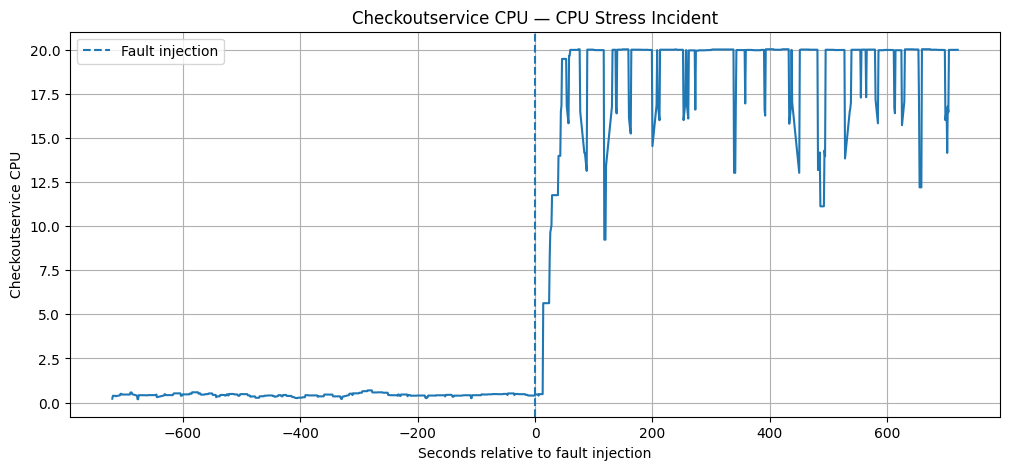

In [ ]:
import matplotlib.pyplot as plt

# Convert timestamps to readable relative seconds
metrics["relative_time"] = metrics["time"] - 1705354566

plt.figure(figsize=(12, 5))

plt.plot(
    metrics["relative_time"],
    metrics["checkoutservice_cpu"]
)

plt.axvline(
    0,
    linestyle="--",
    label="Fault injection"
)

plt.xlabel("Seconds relative to fault injection")
plt.ylabel("Checkoutservice CPU")
plt.title("Checkoutservice CPU — CPU Stress Incident")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
[c for c in metrics.columns if "checkoutservice" in c and "latency" in c.lower()]

['checkoutservice_latency-50', 'checkoutservice_latency-90']

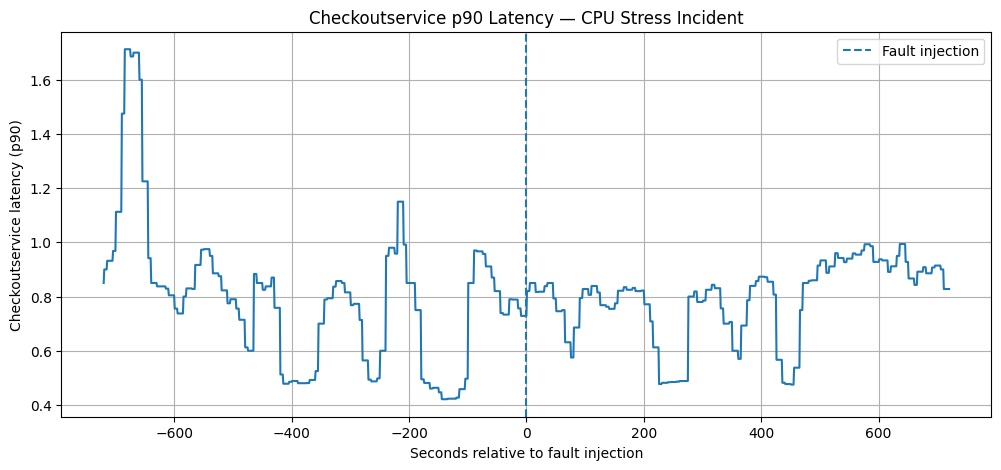

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    metrics["relative_time"],
    metrics["checkoutservice_latency-90"]
)

plt.axvline(
    0,
    linestyle="--",
    label="Fault injection"
)

plt.xlabel("Seconds relative to fault injection")
plt.ylabel("Checkoutservice latency (p90)")
plt.title("Checkoutservice p90 Latency — CPU Stress Incident")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
logs["relative_time"] = logs["timestamp"] - 1705354566

window = logs[
    (logs["relative_time"] >= -60) &
    (logs["relative_time"] <= 60)
]

print("Logs in ±60 seconds around fault:", len(window))

display(window.head(20))

Logs in ±60 seconds around fault: 14499


,timestamp,container_name,message,relative_time
78740,1705354506,shippingservice,[GetQuote] received request,-60
78741,1705354506,shippingservice,[GetQuote] completed request,-60
78742,1705354506,shippingservice,[GetQuote] received request,-60
78743,1705354506,shippingservice,[GetQuote] completed request,-60
78744,1705354506,currencyservice,conversion request successful,-60
78745,1705354506,currencyservice,conversion request successful,-60
78746,1705354506,currencyservice,conversion request successful,-60
78747,1705354506,currencyservice,conversion request successful,-60
78748,1705354506,currencyservice,conversion request successful,-60
78749,1705354506,frontend,request complete,-60


In [ ]:
checkout_logs = window[
    window["container_name"] == "checkoutservice"
]

print("Checkoutservice logs in ±60 seconds:", len(checkout_logs))

display(checkout_logs.head(30))

Checkoutservice logs in ±60 seconds: 206


,timestamp,container_name,message,relative_time
78784,1705354506,checkoutservice,payment went through (transaction_id: 1339ccb6...,-60
78791,1705354506,checkoutservice,"order confirmation email sent to ""someone@exam...",-60
78901,1705354507,checkoutservice,"[PlaceOrder] user_id=""f449362b-6128-42ef-8301-...",-59
78945,1705354507,checkoutservice,payment went through (transaction_id: 3d9b4664...,-59
78953,1705354507,checkoutservice,"order confirmation email sent to ""someone@exam...",-59
79232,1705354509,checkoutservice,"[PlaceOrder] user_id=""24262a89-f048-45bf-9e9c-...",-57
79274,1705354509,checkoutservice,payment went through (transaction_id: 42575e48...,-57
79281,1705354509,checkoutservice,"order confirmation email sent to ""someone@exam...",-57
79389,1705354510,checkoutservice,"[PlaceOrder] user_id=""2de5b4a0-2f99-4a1e-b411-...",-56
79400,1705354510,checkoutservice,payment went through (transaction_id: 9699fcfe...,-56


In [ ]:
checkout_logs["message"].value_counts().head(20)

,count
message,
"order confirmation email sent to ""someone@example.com",69
"[PlaceOrder] user_id=""940d3cd5-31db-4b3f-a9bb-eeb9fe4f62b4"" user_currency=""USD",4
"[PlaceOrder] user_id=""af9d88f1-fe2e-470e-97ab-9ad9ecfc479e"" user_currency=""CAD",3
"[PlaceOrder] user_id=""24262a89-f048-45bf-9e9c-53811d932e8f"" user_currency=""USD",2
"[PlaceOrder] user_id=""4dc1cd88-1b62-48da-aaf9-af046154fd4d"" user_currency=""USD",2
"[PlaceOrder] user_id=""35145403-09e7-47df-96c4-517c62bf5064"" user_currency=""JPY",2
"[PlaceOrder] user_id=""a450233d-e6c2-4a75-8067-00b43d31f85a"" user_currency=""JPY",2
"[PlaceOrder] user_id=""e0db3b7d-da04-46f6-a712-dcfb5d8e5f12"" user_currency=""USD",2
"[PlaceOrder] user_id=""16c12fa5-be69-47d7-9d6a-aabc102b9144"" user_currency=""CAD",2


In [ ]:
checkout_logs = checkout_logs.copy()

checkout_logs["time_bin"] = (
    checkout_logs["timestamp"] // 10
) * 10

log_counts = (
    checkout_logs
    .groupby("time_bin")
    .size()
)

log_counts.head()

,0
time_bin,
1705354500,8
1705354510,18
1705354520,4
1705354530,11
1705354540,15


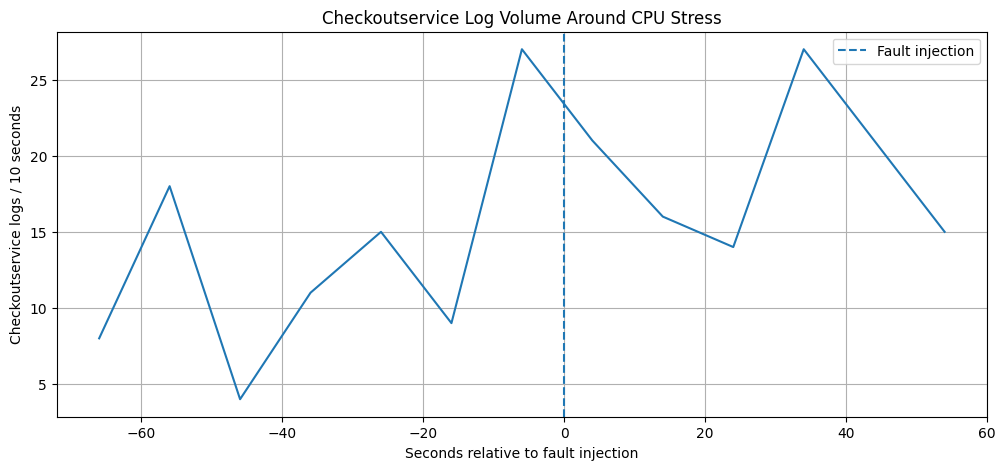

In [ ]:
plot_time = log_counts.index - 1705354566

plt.figure(figsize=(12, 5))

plt.plot(plot_time, log_counts.values)

plt.axvline(
    0,
    linestyle="--",
    label="Fault injection"
)

plt.xlabel("Seconds relative to fault injection")
plt.ylabel("Checkoutservice logs / 10 seconds")
plt.title("Checkoutservice Log Volume Around CPU Stress")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
traces["serviceName"].value_counts()

,count
serviceName,
frontendservice,199519
productcatalogservice,99572
currencyservice,55032
recommendationservice,26434
checkoutservice,9238
emailservice,1245
paymentservice,957


In [ ]:
traces["statusCode"].value_counts(dropna=False)

,count
statusCode,
0,373623
<NA>,18374


In [ ]:
print(traces["time"].dtype)
print(traces["time"].min())
print(traces["time"].max())
print(traces["time"].head())

string
21:24
21:48
0    21:24
1    21:24
2    21:24
3    21:24
4    21:24
Name: time, dtype: string


In [ ]:
print(traces["startTimeMillis"].dtype)
print(traces["startTimeMillis"].head())
print(traces["startTimeMillis"].min())
print(traces["startTimeMillis"].max())

Int64
0    1705353846065
1    1705353846065
2    1705353846069
3    1705353846071
4    1705353846073
Name: startTimeMillis, dtype: Int64
1705353846065
1705355285970


In [ ]:
print("Traces already contain 'relative_time' from 'add_relative_time' function.")
print("Min relative_time:", traces["relative_time"].min())
print("Max relative_time:", traces["relative_time"].max())

Traces already contain 'relative_time' from 'add_relative_time' function.
Min relative_time: -719.9349999427795
Max relative_time: 719.9700000286102


In [ ]:
trace_window = traces[
    (traces["relative_time"] >= -60) &
    (traces["relative_time"] <= 60)
]

print("Trace spans in ±60 seconds:", len(trace_window))

display(
    trace_window[
        [
            "relative_time",
            "serviceName",
            "operationName",
            "duration",
            "statusCode"
        ]
    ].head(30)
)

Trace spans in ±60 seconds: 32503


,relative_time,serviceName,operationName,duration,statusCode
180724,-59.968,frontendservice,hipstershop.ProductCatalogService/GetProduct,2749,0
180725,-59.968,frontendservice,frontend,363418,<NA>
180726,-59.967,productcatalogservice,hipstershop.ProductCatalogService/GetProduct,12,0
180727,-59.966,frontendservice,hipstershop.CurrencyService/GetSupportedCurren...,234904,0
180728,-59.936,frontendservice,hipstershop.ProductCatalogService/GetProduct,5023,0
180729,-59.936,frontendservice,hipstershop.CartService/GetCart,7152,0
180730,-59.936,frontendservice,hipstershop.CartService/GetCart,7205,0
180731,-59.936,frontendservice,hipstershop.ProductCatalogService/GetProduct,5089,0
180732,-59.934,productcatalogservice,hipstershop.ProductCatalogService/GetProduct,12,0
180733,-59.933,productcatalogservice,hipstershop.ProductCatalogService/GetProduct,11,0


In [ ]:
print("Traces already contain 'relative_time' from 'add_relative_time' function.")
print("Min relative_time:", traces["relative_time"].min())
print("Max relative_time:", traces["relative_time"].max())

Traces already contain 'relative_time' from 'add_relative_time' function.
Min relative_time: -719.9349999427795
Max relative_time: 719.9700000286102


In [ ]:
trace_window = traces[
    (traces["relative_time"] >= -60) &
    (traces["relative_time"] <= 60)
]

print("Trace spans in ±60 seconds:", len(trace_window))

display(
    trace_window[
        [
            "relative_time",
            "serviceName",
            "operationName",
            "duration",
            "statusCode"
        ]
    ].head(30)
)

Trace spans in ±60 seconds: 32503


,relative_time,serviceName,operationName,duration,statusCode
180724,-59.968,frontendservice,hipstershop.ProductCatalogService/GetProduct,2749,0
180725,-59.968,frontendservice,frontend,363418,<NA>
180726,-59.967,productcatalogservice,hipstershop.ProductCatalogService/GetProduct,12,0
180727,-59.966,frontendservice,hipstershop.CurrencyService/GetSupportedCurren...,234904,0
180728,-59.936,frontendservice,hipstershop.ProductCatalogService/GetProduct,5023,0
180729,-59.936,frontendservice,hipstershop.CartService/GetCart,7152,0
180730,-59.936,frontendservice,hipstershop.CartService/GetCart,7205,0
180731,-59.936,frontendservice,hipstershop.ProductCatalogService/GetProduct,5089,0
180732,-59.934,productcatalogservice,hipstershop.ProductCatalogService/GetProduct,12,0
180733,-59.933,productcatalogservice,hipstershop.ProductCatalogService/GetProduct,11,0


In [ ]:
trace_window["serviceName"].value_counts()

,count
serviceName,
frontendservice,16422
productcatalogservice,8202
currencyservice,4559
recommendationservice,2186
checkoutservice,926
emailservice,116
paymentservice,92


In [ ]:
checkout_traces = trace_window[
    trace_window["serviceName"] == "checkoutservice"
]

print("Checkoutservice spans:", len(checkout_traces))

checkout_traces["operationName"].value_counts()

Checkoutservice spans: 926


,count
operationName,
hipstershop.CurrencyService/Convert,235
hipstershop.ProductCatalogService/GetProduct,167
hipstershop.CartService/GetCart,68
hipstershop.CheckoutService/PlaceOrder,68
hipstershop.ShippingService/GetQuote,68
hipstershop.PaymentService/Charge,68
hipstershop.ShippingService/ShipOrder,68
hipstershop.CartService/EmptyCart,68
hipstershop.EmailService/SendOrderConfirmation,68


In [ ]:
print(checkout_traces["duration"].describe())

count            926.0
mean      50518.258099
std      105539.592298
min                5.0
25%            3203.75
50%             4528.5
75%           72102.75
max           919035.0
Name: duration, dtype: Float64


In [ ]:
display(
    checkout_traces[
        ["serviceName", "operationName", "duration"]
    ].head(20)
)

,serviceName,operationName,duration
180939,checkoutservice,hipstershop.CartService/GetCart,4185
180940,checkoutservice,hipstershop.CheckoutService/PlaceOrder,312457
180941,checkoutservice,hipstershop.ProductCatalogService/GetProduct,2337
180943,checkoutservice,hipstershop.CurrencyService/Convert,85889
180955,checkoutservice,hipstershop.ProductCatalogService/GetProduct,2745
180960,checkoutservice,hipstershop.CurrencyService/Convert,96988
180969,checkoutservice,hipstershop.ProductCatalogService/GetProduct,2814
180975,checkoutservice,hipstershop.CurrencyService/Convert,3577
180983,checkoutservice,hipstershop.ShippingService/GetQuote,2765
180985,checkoutservice,hipstershop.CurrencyService/Convert,93844


In [ ]:
print(traces.columns.tolist())

['time', 'traceID', 'spanID', 'serviceName', 'methodName', 'operationName', 'parentSpanID', 'startTimeMillis', 'startTime', 'duration', 'statusCode', 'timestamp', 'relative_time']


In [ ]:
before = checkout_traces[
    (checkout_traces["relative_time"] >= -60) &
    (checkout_traces["relative_time"] < 0)
]["duration"]

after = checkout_traces[
    (checkout_traces["relative_time"] >= 0) &
    (checkout_traces["relative_time"] <= 60)
]["duration"]

print("Before fault:")
print(before.describe())

print("\nAfter fault:")
print(after.describe())

Before fault:
count            420.0
mean       48255.52381
std      102214.985737
min                7.0
25%             3119.5
50%             4162.0
75%           83638.25
max           919035.0
Name: duration, dtype: Float64

After fault:
count            506.0
mean      52396.416996
std      108286.412932
min                5.0
25%             3307.5
50%             5025.0
75%            70781.0
max           839895.0
Name: duration, dtype: Float64


In [ ]:
if not checkout_traces.empty:
    sample_trace_id = checkout_traces["traceID"].iloc[0]
    print(sample_trace_id)
else:
    print("No checkoutservice traces available to sample a trace ID.")
    sample_trace_id = None # Ensure sample_trace_id is defined even if empty


f58daa1d368748974723ba9c66116d36


In [ ]:
if sample_trace_id:
    one_trace = traces[
        traces["traceID"] == sample_trace_id
    ].sort_values("startTimeMillis")

    display(
        one_trace[
            [
                "serviceName",
                "operationName",
                "parentSpanID",
                "duration",
                "statusCode"
            ]
        ]
    )
else:
    print("No sample_trace_id available for detailed analysis.")

,serviceName,operationName,parentSpanID,duration,statusCode
180936,frontendservice,frontend,<NA>,400022,<NA>
180937,frontendservice,hipstershop.CheckoutService/PlaceOrder,97db4e8c05c25382,315761,0
180939,checkoutservice,hipstershop.CartService/GetCart,3cfa47a9a633df69,4185,0
180940,checkoutservice,hipstershop.CheckoutService/PlaceOrder,3a5ef2d0baf1a866,312457,0
180941,checkoutservice,hipstershop.ProductCatalogService/GetProduct,3cfa47a9a633df69,2337,0
180942,productcatalogservice,hipstershop.ProductCatalogService/GetProduct,38a52cf6029955f3,15,0
180955,checkoutservice,hipstershop.ProductCatalogService/GetProduct,3cfa47a9a633df69,2745,0
180959,productcatalogservice,hipstershop.ProductCatalogService/GetProduct,7af013d8b208f4c5,15,0
180969,checkoutservice,hipstershop.ProductCatalogService/GetProduct,3cfa47a9a633df69,2814,0
180974,productcatalogservice,hipstershop.ProductCatalogService/GetProduct,0f740d960a9024f5,13,0


In [ ]:
import pandas as pd

# Assuming one_trace and sample_trace_id are available from previous cells
if sample_trace_id:
    print(f"Analyzing trace ID: {sample_trace_id}\n")

    # Calculate relative start time within the trace
    min_start_time = one_trace["startTimeMillis"].min()
    # Ensure we are working on a copy to avoid SettingWithCopyWarning
    trace_to_analyze = one_trace.copy()
    trace_to_analyze["relative_start_ms"] = trace_to_analyze["startTimeMillis"] - min_start_time

    # Create a dictionary for quick lookup of spans by spanID
    span_details_map = {row["spanID"]: row for _, row in trace_to_analyze.iterrows()}

    # Identify all spanIDs present in this trace
    all_span_ids_in_trace = set(trace_to_analyze["spanID"].tolist())

    # Find spans that are considered roots of this particular segment of the trace.
    # A span is a root if its parentSpanID is NaN/None, or if its parentSpanID
    # is not present among any other spanID within this 'one_trace' DataFrame.
    potential_root_spans = trace_to_analyze[
        trace_to_analyze["parentSpanID"].isna() |
        (~trace_to_analyze["parentSpanID"].isin(all_span_ids_in_trace))
    ].sort_values("startTimeMillis")

    if not potential_root_spans.empty:
        # Take the earliest potential root as the starting point for printing
        root_span_id_to_start_from = potential_root_spans.iloc[0]["spanID"]

        # Function to print a span and its children recursively
        def print_span(current_span_id, indent=0):
            span = span_details_map[current_span_id]

            status_text = span["statusCode"]
            if pd.isna(status_text):
                status_text = "OK" # Common convention for unspecified status

            print(
                "  " * indent +
                f"[{span['serviceName']}] "
                f"{span['operationName']} "
                f"({span['duration']}us, +" # Duration is in microseconds
                f"{span['relative_start_ms']}ms from trace start)"
                f" Status: {status_text}"
            )

            # Find children of the current span that are also in this trace
            children = trace_to_analyze[trace_to_analyze["parentSpanID"] == current_span_id]
            for _, child_span in children.sort_values("startTimeMillis").iterrows():
                print_span(child_span["spanID"], indent + 1)

        print_span(root_span_id_to_start_from)
    else:
        print("Warning: No clear root span found for this trace segment. It might be part of a larger trace or broken.")
        if not trace_to_analyze.empty:
            print("Displaying all spans flat for examination:")
            for _, span in trace_to_analyze.iterrows():
                status_text = span["statusCode"]
                if pd.isna(status_text):
                    status_text = "OK"
                print(
                    f"[{span['serviceName']}] "
                    f"{span['operationName']} "
                    f"({span['duration']}us, +"
                    f"{span['relative_start_ms']}ms from trace start)"
                    f" Status: {status_text}"
                )
        else:
            print("Trace is empty.")
else:
    print("No sample_trace_id was available for detailed analysis.")


Analyzing trace ID: f58daa1d368748974723ba9c66116d36

[frontendservice] frontend (400022us, +0ms from trace start) Status: OK
  [frontendservice] hipstershop.CheckoutService/PlaceOrder (315761us, +0ms from trace start) Status: 0
    [checkoutservice] hipstershop.CheckoutService/PlaceOrder (312457us, +2ms from trace start) Status: 0
      [checkoutservice] hipstershop.CartService/GetCart (4185us, +2ms from trace start) Status: 0
      [checkoutservice] hipstershop.ProductCatalogService/GetProduct (2337us, +6ms from trace start) Status: 0
        [productcatalogservice] hipstershop.ProductCatalogService/GetProduct (15us, +7ms from trace start) Status: 0
      [checkoutservice] hipstershop.ProductCatalogService/GetProduct (2745us, +94ms from trace start) Status: 0
        [productcatalogservice] hipstershop.ProductCatalogService/GetProduct (15us, +96ms from trace start) Status: 0
      [checkoutservice] hipstershop.ProductCatalogService/GetProduct (2814us, +194ms from trace start) Status:

In [ ]:
import pandas as pd

# Assuming one_trace and sample_trace_id are available from previous cells
if sample_trace_id:
    print(f"Analyzing trace ID: {sample_trace_id}\n")

    # Calculate relative start time within the trace
    min_start_time = one_trace["startTimeMillis"].min()
    # Ensure we are working on a copy to avoid SettingWithCopyWarning
    trace_to_analyze = one_trace.copy()
    trace_to_analyze["relative_start_ms"] = trace_to_analyze["startTimeMillis"] - min_start_time

    # Create a dictionary for quick lookup of spans by spanID
    span_details_map = {row["spanID"]: row for _, row in trace_to_analyze.iterrows()}

    # Identify all spanIDs present in this trace
    all_span_ids_in_trace = set(trace_to_analyze["spanID"].tolist())

    # Find spans that are considered roots of this particular segment of the trace.
    # A span is a root if its parentSpanID is NaN/None, or if its parentSpanID
    # is not present among any other spanID within this 'one_trace' DataFrame.
    potential_root_spans = trace_to_analyze[
        trace_to_analyze["parentSpanID"].isna() |
        (~trace_to_analyze["parentSpanID"].isin(all_span_ids_in_trace))
    ].sort_values("startTimeMillis")

    if not potential_root_spans.empty:
        # Take the earliest potential root as the starting point for printing
        root_span_id_to_start_from = potential_root_spans.iloc[0]["spanID"]

        # Function to print a span and its children recursively
        def print_span(current_span_id, indent=0):
            span = span_details_map[current_span_id]

            status_text = span["statusCode"]
            if pd.isna(status_text):
                status_text = "OK" # Common convention for unspecified status

            print(
                "  " * indent +
                f"[{span['serviceName']}] "
                f"{span['operationName']} "
                f"({span['duration']}us, +" # Duration is in microseconds
                f"{span['relative_start_ms']}ms from trace start)"
                f" Status: {status_text}"
            )

            # Find children of the current span that are also in this trace
            children = trace_to_analyze[trace_to_analyze["parentSpanID"] == current_span_id]
            for _, child_span in children.sort_values("startTimeMillis").iterrows():
                print_span(child_span["spanID"], indent + 1)

        print_span(root_span_id_to_start_from)
    else:
        print("Warning: No clear root span found for this trace segment. It might be part of a larger trace or broken.")
        if not trace_to_analyze.empty:
            print("Displaying all spans flat for examination:")
            for _, span in trace_to_analyze.iterrows():
                status_text = span["statusCode"]
                if pd.isna(status_text):
                    status_text = "OK"
                print(
                    f"[{span['serviceName']}] "
                    f"{span['operationName']} "
                    f"({span['duration']}us, +"
                    f"{span['relative_start_ms']}ms from trace start)"
                    f" Status: {status_text}"
                )
        else:
            print("Trace is empty.")
else:
    print("No sample_trace_id was available for detailed analysis.")


Analyzing trace ID: f58daa1d368748974723ba9c66116d36

[frontendservice] frontend (400022us, +0ms from trace start) Status: OK
  [frontendservice] hipstershop.CheckoutService/PlaceOrder (315761us, +0ms from trace start) Status: 0
    [checkoutservice] hipstershop.CheckoutService/PlaceOrder (312457us, +2ms from trace start) Status: 0
      [checkoutservice] hipstershop.CartService/GetCart (4185us, +2ms from trace start) Status: 0
      [checkoutservice] hipstershop.ProductCatalogService/GetProduct (2337us, +6ms from trace start) Status: 0
        [productcatalogservice] hipstershop.ProductCatalogService/GetProduct (15us, +7ms from trace start) Status: 0
      [checkoutservice] hipstershop.ProductCatalogService/GetProduct (2745us, +94ms from trace start) Status: 0
        [productcatalogservice] hipstershop.ProductCatalogService/GetProduct (15us, +96ms from trace start) Status: 0
      [checkoutservice] hipstershop.ProductCatalogService/GetProduct (2814us, +194ms from trace start) Status:

In [ ]:
import pandas as pd

# Assuming one_trace and sample_trace_id are available from previous cells
if sample_trace_id:
    print(f"Analyzing trace ID: {sample_trace_id}\n")

    # Calculate relative start time within the trace
    min_start_time = one_trace["startTimeMillis"].min()
    # Ensure we are working on a copy to avoid SettingWithCopyWarning
    trace_to_analyze = one_trace.copy()
    trace_to_analyze["relative_start_ms"] = trace_to_analyze["startTimeMillis"] - min_start_time

    # Create a dictionary for quick lookup of spans by spanID
    span_details_map = {row["spanID"]: row for _, row in trace_to_analyze.iterrows()}

    # Identify all spanIDs present in this trace
    all_span_ids_in_trace = set(trace_to_analyze["spanID"].tolist())

    # Find spans that are considered roots of this particular segment of the trace.
    # A span is a root if its parentSpanID is NaN/None, or if its parentSpanID
    # is not present among any other spanID within this 'one_trace' DataFrame.
    potential_root_spans = trace_to_analyze[
        trace_to_analyze["parentSpanID"].isna() |
        (~trace_to_analyze["parentSpanID"].isin(all_span_ids_in_trace))
    ].sort_values("startTimeMillis")

    if not potential_root_spans.empty:
        # Take the earliest potential root as the starting point for printing
        root_span_id_to_start_from = potential_root_spans.iloc[0]["spanID"]

        # Function to print a span and its children recursively
        def print_span(current_span_id, indent=0):
            span = span_details_map[current_span_id]

            status_text = span["statusCode"]
            if pd.isna(status_text):
                status_text = "OK" # Common convention for unspecified status

            print(
                "  " * indent +
                f"[{span['serviceName']}] "
                f"{span['operationName']} "
                f"({span['duration']}us, +" # Duration is in microseconds
                f"{span['relative_start_ms']}ms from trace start)"
                f" Status: {status_text}"
            )

            # Find children of the current span that are also in this trace
            children = trace_to_analyze[trace_to_analyze["parentSpanID"] == current_span_id]
            for _, child_span in children.sort_values("startTimeMillis").iterrows():
                print_span(child_span["spanID"], indent + 1)

        print_span(root_span_id_to_start_from)
    else:
        print("Warning: No clear root span found for this trace segment. It might be part of a larger trace or broken.")
        if not trace_to_analyze.empty:
            print("Displaying all spans flat for examination:")
            for _, span in trace_to_analyze.iterrows():
                status_text = span["statusCode"]
                if pd.isna(status_text):
                    status_text = "OK"
                print(
                    f"[{span['serviceName']}] "
                    f"{span['operationName']} "
                    f"({span['duration']}us, +"
                    f"{span['relative_start_ms']}ms from trace start)"
                    f" Status: {status_text}"
                )
        else:
            print("Trace is empty.")
else:
    print("No sample_trace_id was available for detailed analysis.")


Analyzing trace ID: f58daa1d368748974723ba9c66116d36

[frontendservice] frontend (400022us, +0ms from trace start) Status: OK
  [frontendservice] hipstershop.CheckoutService/PlaceOrder (315761us, +0ms from trace start) Status: 0
    [checkoutservice] hipstershop.CheckoutService/PlaceOrder (312457us, +2ms from trace start) Status: 0
      [checkoutservice] hipstershop.CartService/GetCart (4185us, +2ms from trace start) Status: 0
      [checkoutservice] hipstershop.ProductCatalogService/GetProduct (2337us, +6ms from trace start) Status: 0
        [productcatalogservice] hipstershop.ProductCatalogService/GetProduct (15us, +7ms from trace start) Status: 0
      [checkoutservice] hipstershop.ProductCatalogService/GetProduct (2745us, +94ms from trace start) Status: 0
        [productcatalogservice] hipstershop.ProductCatalogService/GetProduct (15us, +96ms from trace start) Status: 0
      [checkoutservice] hipstershop.ProductCatalogService/GetProduct (2814us, +194ms from trace start) Status:

In [ ]:
import pandas as pd

# Assuming one_trace and sample_trace_id are available from previous cells
if sample_trace_id:
    print(f"Analyzing trace ID: {sample_trace_id}\n")

    # Calculate relative start time within the trace
    min_start_time = one_trace["startTimeMillis"].min()
    # Ensure we are working on a copy to avoid SettingWithCopyWarning
    trace_to_analyze = one_trace.copy()
    trace_to_analyze["relative_start_ms"] = trace_to_analyze["startTimeMillis"] - min_start_time

    # Create a dictionary for quick lookup of spans by spanID
    span_details_map = {row["spanID"]: row for _, row in trace_to_analyze.iterrows()}

    # Identify all spanIDs present in this trace
    all_span_ids_in_trace = set(trace_to_analyze["spanID"].tolist())

    # Find spans that are considered roots of this particular segment of the trace.
    # A span is a root if its parentSpanID is NaN/None, or if its parentSpanID
    # is not present among any other spanID within this 'one_trace' DataFrame.
    potential_root_spans = trace_to_analyze[
        trace_to_analyze["parentSpanID"].isna() |
        (~trace_to_analyze["parentSpanID"].isin(all_span_ids_in_trace))
    ].sort_values("startTimeMillis")

    if not potential_root_spans.empty:
        # Take the earliest potential root as the starting point for printing
        root_span_id_to_start_from = potential_root_spans.iloc[0]["spanID"]

        # Function to print a span and its children recursively
        def print_span(current_span_id, indent=0):
            span = span_details_map[current_span_id]

            status_text = span["statusCode"]
            if pd.isna(status_text):
                status_text = "OK" # Common convention for unspecified status

            print(
                "  " * indent +
                f"[{span['serviceName']}] "
                f"{span['operationName']} "
                f"({span['duration']}us, +" # Duration is in microseconds
                f"{span['relative_start_ms']}ms from trace start)"
                f" Status: {status_text}"
            )

            # Find children of the current span that are also in this trace
            children = trace_to_analyze[trace_to_analyze["parentSpanID"] == current_span_id]
            for _, child_span in children.sort_values("startTimeMillis").iterrows():
                print_span(child_span["spanID"], indent + 1)

        print_span(root_span_id_to_start_from)
    else:
        print("Warning: No clear root span found for this trace segment. It might be part of a larger trace or broken.")
        if not trace_to_analyze.empty:
            print("Displaying all spans flat for examination:")
            for _, span in trace_to_analyze.iterrows():
                status_text = span["statusCode"]
                if pd.isna(status_text):
                    status_text = "OK"
                print(
                    f"[{span['serviceName']}] "
                    f"{span['operationName']} "
                    f"({span['duration']}us, +"
                    f"{span['relative_start_ms']}ms from trace start)"
                    f" Status: {status_text}"
                )
        else:
            print("Trace is empty.")
else:
    print("No sample_trace_id was available for detailed analysis.")


Analyzing trace ID: f58daa1d368748974723ba9c66116d36

[frontendservice] frontend (400022us, +0ms from trace start) Status: OK
  [frontendservice] hipstershop.CheckoutService/PlaceOrder (315761us, +0ms from trace start) Status: 0
    [checkoutservice] hipstershop.CheckoutService/PlaceOrder (312457us, +2ms from trace start) Status: 0
      [checkoutservice] hipstershop.CartService/GetCart (4185us, +2ms from trace start) Status: 0
      [checkoutservice] hipstershop.ProductCatalogService/GetProduct (2337us, +6ms from trace start) Status: 0
        [productcatalogservice] hipstershop.ProductCatalogService/GetProduct (15us, +7ms from trace start) Status: 0
      [checkoutservice] hipstershop.ProductCatalogService/GetProduct (2745us, +94ms from trace start) Status: 0
        [productcatalogservice] hipstershop.ProductCatalogService/GetProduct (15us, +96ms from trace start) Status: 0
      [checkoutservice] hipstershop.ProductCatalogService/GetProduct (2814us, +194ms from trace start) Status:

In [ ]:
def normalize_trace_time(traces, inject_time):
    ...

In [ ]:
def normalize_trace_time(traces, inject_time):
    traces = traces.copy()

    # Convert milliseconds to Unix seconds
    traces["timestamp"] = traces["startTimeMillis"] / 1000

    # Time relative to fault injection
    traces["relative_time"] = traces["timestamp"] - inject_time

    return traces

In [ ]:
traces = normalize_trace_time(
    traces,
    inject_time=1705354566
)

In [ ]:
traces[[
    "startTimeMillis",
    "timestamp",
    "relative_time"
]].head()

,startTimeMillis,timestamp,relative_time
0,1705353846065,1705353846.065,-719.935
1,1705353846065,1705353846.065,-719.935
2,1705353846069,1705353846.069,-719.931
3,1705353846071,1705353846.071,-719.929
4,1705353846073,1705353846.073,-719.927


In [ ]:
print("Metrics:")
print(metrics["time"].min(), metrics["time"].max())

print("\nLogs:")
print(logs["timestamp"].min(), logs["timestamp"].max())

print("\nTraces:")
print(traces["timestamp"].min(), traces["timestamp"].max())

print("\nInjection:")
print(1705354566)

Metrics:
1705353846 1705355286

Logs:
1705353846 1705355286

Traces:
1705353846.065 1705355285.97

Injection:
1705354566


In [ ]:
print(
    traces["relative_time"].min(),
    traces["relative_time"].max()
)

-719.9349999427795 719.9700000286102


In [ ]:
print("Metrics shape:", metrics.shape)
print("Logs shape:", logs.shape)
print("Traces shape:", traces.shape)

print("\nMissing values:")
print("Metrics:", metrics.isna().sum().sum())
print("Logs:", logs.isna().sum().sum())
print("Traces:", traces.isna().sum().sum())

Metrics shape: (1441, 75)
Logs shape: (171322, 4)
Traces shape: (391997, 13)

Missing values:
Metrics: 4
Logs: 0
Traces: 60716


## EDA Observations

- RCAEval RE2 provides metrics, logs, and traces for the selected case.
- The CPU metric showed a clear change around the fault injection time.
- Checkoutservice latency did not show an equally simple synchronized change.
- Checkoutservice log volume did not show an obvious step change around the injection point.
- Traces provide distributed request information through traceID and parentSpanID.
- Different telemetry sources use different timestamp representations, so timestamp normalization is required.
- A common relative timeline is useful for incident-centered analysis.
- The known fault-injection timestamp is available for EDA/evaluation, but a real detection system cannot assume it is known.

In [ ]:
import pandas as pd


def get_case_metadata(cases: pd.DataFrame, case_id: str) -> pd.Series:
    """
    Look up metadata for a single incident case.

    Parameters
    ----------
    cases : pd.DataFrame
        The RCAEval cases DataFrame (must contain a "case" column).
    case_id : str
        The case identifier to look up (e.g. "re2ob_checkoutservice_cpu_1").

    Returns
    -------
    pd.Series
        The row of metadata for the matching case, indexed by column name.

    Raises
    ------
    ValueError
        If no row matches `case_id`, or if more than one row matches
        (which would indicate corrupted/duplicated data).
    """
    matches = cases[cases["case"] == case_id]

    if len(matches) == 0:
        raise ValueError(f"Case '{case_id}' not found in cases dataset.")

    if len(matches) > 1:
        raise ValueError(
            f"Case '{case_id}' is not unique: found {len(matches)} matching rows. "
            "Expected exactly one row per case."
        )

    return matches.iloc[0]


# Example usage
metadata = get_case_metadata(cases, "re2ob_checkoutservice_cpu_1")
print(metadata)

case                   re2ob_checkoutservice_cpu_1
dataset                                     RE2-OB
suite                                          RE2
system                                          ob
system_name                        Online Boutique
root_cause_service                 checkoutservice
fault                                          cpu
fault_description                       CPU stress
repetition                                       1
inject_time                             1705354566
n_metrics                                       72
n_timesteps                                   1441
time_start                              1705353846
time_end                                1705355286
duration_minutes                              24.0
normal_timesteps                               720
faulty_timesteps                               721
has_logs                                      True
n_logs                                      171322
has_traces                     

In [ ]:
import os
import pandas as pd


def load_case(case_id: str, cases: pd.DataFrame, base_dir: str = "/content/rcaeval_case") -> dict:
    """
    Load an already-downloaded RCAEval case (metadata + metrics/logs/traces).

    Searches recursively under `base_dir` for a directory named `case_id`
    and loads its metrics.parquet, logs.parquet, and traces.parquet files.

    Parameters
    ----------
    case_id : str
        The case identifier (e.g. "re2ob_checkoutservice_cpu_1").
    cases : pd.DataFrame
        The RCAEval cases DataFrame, used to fetch metadata.
    base_dir : str, optional
        Root directory to search for the downloaded case folder.

    Returns
    -------
    dict
        {
            "metadata": pd.Series,
            "metrics": pd.DataFrame,
            "logs": pd.DataFrame,
            "traces": pd.DataFrame,
        }

    Raises
    ------
    ValueError
        If the case metadata cannot be found (via get_case_metadata).
    FileNotFoundError
        If the case directory, or any required parquet file, is missing.
    """
    # Step 1: metadata (reuses existing function; will raise ValueError if invalid)
    metadata = get_case_metadata(cases, case_id)

    # Step 2: locate the case directory recursively under base_dir
    case_dir = None
    for root, dirs, _ in os.walk(base_dir):
        if case_id in dirs:
            case_dir = os.path.join(root, case_id)
            break

    if case_dir is None:
        raise FileNotFoundError(
            f"Could not find a directory named '{case_id}' under '{base_dir}'. "
            "Make sure the case has been downloaded first."
        )

    # Step 3: load required parquet files
    required_files = {
        "metrics": "metrics.parquet",
        "logs": "logs.parquet",
        "traces": "traces.parquet",
    }

    data = {"metadata": metadata}

    for key, filename in required_files.items():
        file_path = os.path.join(case_dir, filename)
        if not os.path.isfile(file_path):
            raise FileNotFoundError(
                f"Missing required file '{filename}' for case '{case_id}' "
                f"in directory '{case_dir}'."
            )
        data[key] = pd.read_parquet(file_path)

    return data


# Example usage
case_data = load_case("re2ob_checkoutservice_cpu_1", cases)
print(case_data["metadata"])
print(case_data["metrics"].shape, case_data["logs"].shape, case_data["traces"].shape)

case                   re2ob_checkoutservice_cpu_1
dataset                                     RE2-OB
suite                                          RE2
system                                          ob
system_name                        Online Boutique
root_cause_service                 checkoutservice
fault                                          cpu
fault_description                       CPU stress
repetition                                       1
inject_time                             1705354566
n_metrics                                       72
n_timesteps                                   1441
time_start                              1705353846
time_end                                1705355286
duration_minutes                              24.0
normal_timesteps                               720
faulty_timesteps                               721
has_logs                                      True
n_logs                                      171322
has_traces                     

In [ ]:
import pandas as pd


def normalize_timestamps(case_data: dict) -> dict:
    """
    Add a common `timestamp` column (Unix seconds, as float) to metrics,
    logs, and traces DataFrames, without modifying the input in place.

    - metrics: `timestamp` copied from `time` (already seconds)
    - logs: `timestamp` copied from `timestamp` (already seconds)
    - traces: `timestamp` derived from `startTimeMillis / 1000`

    Original columns are preserved unchanged.

    Parameters
    ----------
    case_data : dict
        Output of load_case(), with keys "metadata", "metrics", "logs", "traces".

    Returns
    -------
    dict
        New dict with the same keys; metrics/logs/traces are copies with an
        added `timestamp` column. metadata is passed through unchanged.
    """
    metrics = case_data["metrics"].copy()
    logs = case_data["logs"].copy()
    traces = case_data["traces"].copy()

    metrics["timestamp"] = metrics["time"]
    logs["timestamp"] = logs["timestamp"]  # already the source column; kept explicit for clarity
    traces["timestamp"] = traces["startTimeMillis"] / 1000

    return {
        "metadata": case_data["metadata"],
        "metrics": metrics,
        "logs": logs,
        "traces": traces,
    }


# Example usage
normalized_case_data = normalize_timestamps(case_data)
print(normalized_case_data["metrics"][["time", "timestamp"]].head())
print(normalized_case_data["logs"][["timestamp"]].head())
print(normalized_case_data["traces"][["startTimeMillis", "timestamp"]].head())

         time   timestamp
0  1705353846  1705353846
1  1705353847  1705353847
2  1705353848  1705353848
3  1705353849  1705353849
4  1705353850  1705353850
    timestamp
0  1705353846
1  1705353846
2  1705353846
3  1705353846
4  1705353846
   startTimeMillis       timestamp
0    1705353846065  1705353846.065
1    1705353846065  1705353846.065
2    1705353846069  1705353846.069
3    1705353846071  1705353846.071
4    1705353846073  1705353846.073


In [ ]:
def add_relative_time(case_data: dict) -> dict:
    """
    Add a `relative_time` column (timestamp - inject_time) to metrics,
    logs, and traces DataFrames, without modifying the input in place.

    relative_time is measured in seconds, anchored to the incident's
    injection time from case_data["metadata"]["inject_time"].

    Parameters
    ----------
    case_data : dict
        Output of normalize_timestamps(), with keys
        "metadata", "metrics", "logs", "traces", each telemetry
        DataFrame already containing a `timestamp` column.

    Returns
    -------
    dict
        New dict with the same keys; metrics/logs/traces are copies with
        an added `relative_time` column. metadata is passed through unchanged.
    """
    inject_time = case_data["metadata"]["inject_time"]

    metrics = case_data["metrics"].copy()
    logs = case_data["logs"].copy()
    traces = case_data["traces"].copy()

    metrics["relative_time"] = metrics["timestamp"] - inject_time
    logs["relative_time"] = logs["timestamp"] - inject_time
    traces["relative_time"] = traces["timestamp"] - inject_time

    return {
        "metadata": case_data["metadata"],
        "metrics": metrics,
        "logs": logs,
        "traces": traces,
    }


# Example usage
case_data_with_rt = add_relative_time(normalized_case_data)
print(case_data_with_rt["metrics"][["timestamp", "relative_time"]].head())
print(case_data_with_rt["logs"][["timestamp", "relative_time"]].head())
print(case_data_with_rt["traces"][["timestamp", "relative_time"]].head())

    timestamp  relative_time
0  1705353846           -720
1  1705353847           -719
2  1705353848           -718
3  1705353849           -717
4  1705353850           -716
    timestamp  relative_time
0  1705353846           -720
1  1705353846           -720
2  1705353846           -720
3  1705353846           -720
4  1705353846           -720
        timestamp  relative_time
0  1705353846.065       -719.935
1  1705353846.065       -719.935
2  1705353846.069       -719.931
3  1705353846.071       -719.929
4  1705353846.073       -719.927


In [ ]:
print("METRICS")
print(case_data_with_rt["metrics"].columns.tolist())

print("\nLOGS")
print(case_data_with_rt["logs"].columns.tolist())

print("\nTRACES")
print(case_data_with_rt["traces"].columns.tolist())

METRICS
['time', 'adservice_cpu', 'cartservice_cpu', 'checkoutservice_cpu', 'currencyservice_cpu', 'emailservice_cpu', 'frontend_cpu', 'paymentservice_cpu', 'productcatalogservice_cpu', 'recommendationservice_cpu', 'redis_cpu', 'shippingservice_cpu', 'adservice_mem', 'cartservice_mem', 'checkoutservice_mem', 'currencyservice_mem', 'emailservice_mem', 'frontend_mem', 'paymentservice_mem', 'productcatalogservice_mem', 'recommendationservice_mem', 'redis_mem', 'shippingservice_mem', 'adservice_diskio', 'emailservice_diskio', 'recommendationservice_diskio', 'redis_diskio', 'adservice_socket', 'cartservice_socket', 'checkoutservice_socket', 'currencyservice_socket', 'emailservice_socket', 'frontend_socket', 'paymentservice_socket', 'productcatalogservice_socket', 'recommendationservice_socket', 'redis_socket', 'shippingservice_socket', 'adservice_workload', 'cartservice_workload', 'checkoutservice_workload', 'currencyservice_workload', 'emailservice_workload', 'frontend_workload', 'frontend

In [ ]:
print(case_data_with_rt["metrics"].head(3))
print(case_data_with_rt["logs"].head(3))
print(case_data_with_rt["traces"].head(3))

         time  adservice_cpu  cartservice_cpu  checkoutservice_cpu  \
0  1705353846       0.685023         2.216467             0.215886   
1  1705353847       0.685023         2.216467             0.380058   
2  1705353848       0.582707         2.216467             0.380058   

   currencyservice_cpu  emailservice_cpu  frontend_cpu  paymentservice_cpu  \
0            19.035876          0.279166      6.724489             0.52931   
1            19.035876          0.279166      6.724489             0.52931   
2            19.035876          0.279166      6.724489             0.52931   

   productcatalogservice_cpu  recommendationservice_cpu  ...  \
0                   2.636831                   2.474853  ...   
1                   2.636858                   2.474853  ...   
2                   2.584059                   2.474853  ...   

   checkoutservice_latency-90  currencyservice_latency-90  \
0                    0.850000                    0.110638   
1                    0.8999

In [ ]:
metrics = case_data_with_rt["metrics"]

metric_columns = [
    c for c in metrics.columns
    if c not in ["time", "timestamp", "relative_time"]
]

print("Number of metric columns:", len(metric_columns))

for c in metric_columns:
    print(c)

Number of metric columns: 72
adservice_cpu
cartservice_cpu
checkoutservice_cpu
currencyservice_cpu
emailservice_cpu
frontend_cpu
paymentservice_cpu
productcatalogservice_cpu
recommendationservice_cpu
redis_cpu
shippingservice_cpu
adservice_mem
cartservice_mem
checkoutservice_mem
currencyservice_mem
emailservice_mem
frontend_mem
paymentservice_mem
productcatalogservice_mem
recommendationservice_mem
redis_mem
shippingservice_mem
adservice_diskio
emailservice_diskio
recommendationservice_diskio
redis_diskio
adservice_socket
cartservice_socket
checkoutservice_socket
currencyservice_socket
emailservice_socket
frontend_socket
paymentservice_socket
productcatalogservice_socket
recommendationservice_socket
redis_socket
shippingservice_socket
adservice_workload
cartservice_workload
checkoutservice_workload
currencyservice_workload
emailservice_workload
frontend_workload
frontend-external_workload
paymentservice_workload
productcatalogservice_workload
recommendationservice_workload
shippingservi

In [ ]:
logs["message"].value_counts().head(20)

,count
message,
conversion request successful,39923
request started,18374
request complete,18373
Getting supported currencies...,14831
serving product page,8473
[GetQuote] completed request,4457
[GetQuote] received request,4457
view user cart,3788
received ad request (context_words=[kitchen]),2830


In [ ]:
traces["statusCode"].value_counts()

,count
statusCode,
0,373623


In [ ]:
print(logs["container_name"].nunique())
print(traces["serviceName"].nunique())

10
7


In [ ]:
metrics = case_data_with_rt["metrics"]

services = sorted(set(
    c.rsplit("_", 1)[0]
    for c in metrics.columns
    if "_" in c and c not in ["relative_time"]
))

print("Possible service names:")
for service in services:
    print(service)

Possible service names:
adservice
cartservice
checkoutservice
currencyservice
emailservice
frontend
frontend-external
paymentservice
productcatalogservice
recommendationservice
redis
shippingservice


In [ ]:
print("Metric shape:", metrics.shape)

print("\nMissing values:")
print(metrics.isna().sum().sum())

print("\nDuplicate timestamps:")
print(metrics["timestamp"].duplicated().sum())

print("\nTimestamp range:")
print(metrics["relative_time"].min(), "to", metrics["relative_time"].max())

Metric shape: (1441, 75)

Missing values:
4

Duplicate timestamps:
0

Timestamp range:
-720 to 720


In [ ]:
missing = metrics.isna().sum()

print(missing[missing > 0])

recommendationservice_cpu       1
redis_cpu                       1
recommendationservice_diskio    1
redis_diskio                    1
dtype: int64


In [ ]:
metrics = case_data_with_rt["metrics"]

cols = [
    "relative_time",
    "checkoutservice_cpu",
    "frontend_cpu",
    "cartservice_cpu",
    "recommendationservice_cpu"
]

print(
    metrics[
        (metrics["relative_time"] >= -60) &
        (metrics["relative_time"] <= 60)
    ][cols].head(20)
)

     relative_time  checkoutservice_cpu  frontend_cpu  cartservice_cpu  \
660            -60             0.471686      6.825485         2.231181   
661            -59             0.471686      6.825485         2.231181   
662            -58             0.471686      6.825485         2.231181   
663            -57             0.471686      6.825485         2.231181   
664            -56             0.471686      6.003675         2.231181   
665            -55             0.471686      6.957578         2.231181   
666            -54             0.487225      6.957578         2.231181   
667            -53             0.487225      6.957578         2.390101   
668            -52             0.487225      6.957578         2.390101   
669            -51             0.487225      6.957578         2.390101   
670            -50             0.487225      6.957578         2.390101   
671            -49             0.487225      6.957578         2.390101   
672            -48             0.48722

In [ ]:
print(
    metrics[
        (metrics["relative_time"] >= -10) &
        (metrics["relative_time"] <= 30)
    ][cols]
)

     relative_time  checkoutservice_cpu  frontend_cpu  cartservice_cpu  \
710            -10             0.393750      6.408442         1.475692   
711             -9             0.393750      6.408442         1.511587   
712             -8             0.393750      6.408442         1.547482   
713             -7             0.393750      6.408442         1.583377   
714             -6             0.393750      6.408442         1.619272   
715             -5             0.393750      6.408442         1.655167   
716             -4             0.393750      6.408442         1.795777   
717             -3             0.393750      6.537349         1.833889   
718             -2             0.393750      6.537349         1.872001   
719             -1             0.393750      6.537349         1.910113   
720              0             0.457566      6.666372         1.948225   
721              1             0.457566      6.666372         2.286723   
722              2             0.45756

In [ ]:
for col in [
    "recommendationservice_cpu",
    "redis_cpu",
    "recommendationservice_diskio",
    "redis_diskio"
]:
    print("\n", col)
    print(
        metrics.loc[
            metrics[col].isna(),
            ["relative_time", col]
        ]
    )


 recommendationservice_cpu
     relative_time  recommendationservice_cpu
179           -541                        NaN

 redis_cpu
     relative_time  redis_cpu
643            -77        NaN

 recommendationservice_diskio
     relative_time  recommendationservice_diskio
179           -541                           NaN

 redis_diskio
     relative_time  redis_diskio
643            -77           NaN


In [ ]:
print(cases.columns.tolist())

['case', 'dataset', 'suite', 'system', 'system_name', 'root_cause_service', 'fault', 'fault_description', 'repetition', 'inject_time', 'n_metrics', 'n_timesteps', 'time_start', 'time_end', 'duration_minutes', 'normal_timesteps', 'faulty_timesteps', 'has_logs', 'n_logs', 'has_traces', 'n_traces', 'has_root_cause_file']


In [ ]:
display(
    cases[
        [
            "case",
            "dataset",
            "root_cause_service",
            "fault"
        ]
    ].head(30)
)

,case,dataset,root_cause_service,fault
0,re1ob_adservice_cpu_1,RE1-OB,adservice,cpu
1,re1ob_adservice_cpu_2,RE1-OB,adservice,cpu
2,re1ob_adservice_cpu_3,RE1-OB,adservice,cpu
3,re1ob_adservice_cpu_4,RE1-OB,adservice,cpu
4,re1ob_adservice_cpu_5,RE1-OB,adservice,cpu
5,re1ob_adservice_delay_1,RE1-OB,adservice,delay
6,re1ob_adservice_delay_2,RE1-OB,adservice,delay
7,re1ob_adservice_delay_3,RE1-OB,adservice,delay
8,re1ob_adservice_delay_4,RE1-OB,adservice,delay
9,re1ob_adservice_delay_5,RE1-OB,adservice,delay


In [ ]:
print("Root-cause services:")
display(cases["root_cause_service"].value_counts())

print("\nFault types:")
display(cases["fault"].value_counts())

print("\nService × Fault:")
display(
    cases.groupby(
        ["root_cause_service", "fault"]
    ).size().reset_index(name="count")
)

Root-cause services:


,count
root_cause_service,
ts-auth-service,58
ts-route-service,58
carts,55
orders,52
currencyservice,46
payment,43
user,43
catalogue,43
productcatalogservice,43



Fault types:


,count
fault,
cpu,120
delay,120
disk,120
loss,120
mem,120
socket,45
f3,26
f1,26
f4,19



Service × Fault:


,root_cause_service,fault,count
0,adservice,cpu,5
1,adservice,delay,5
2,adservice,disk,5
3,adservice,f3,3
4,adservice,f4,3
...,...,...,...
122,user,delay,8
123,user,disk,8
124,user,loss,8
125,user,mem,8


In [ ]:
cpu_cases = cases[cases["fault"] == "cpu"]

display(
    cpu_cases[
        [
            "case",
            "root_cause_service",
            "fault",
            "repetition"
        ]
    ].head(20)
)

,case,root_cause_service,fault,repetition
0,re1ob_adservice_cpu_1,adservice,cpu,1
1,re1ob_adservice_cpu_2,adservice,cpu,2
2,re1ob_adservice_cpu_3,adservice,cpu,3
3,re1ob_adservice_cpu_4,adservice,cpu,4
4,re1ob_adservice_cpu_5,adservice,cpu,5
25,re1ob_cartservice_cpu_1,cartservice,cpu,1
26,re1ob_cartservice_cpu_2,cartservice,cpu,2
27,re1ob_cartservice_cpu_3,cartservice,cpu,3
28,re1ob_cartservice_cpu_4,cartservice,cpu,4
29,re1ob_cartservice_cpu_5,cartservice,cpu,5


In [ ]:
from pathlib import Path

base_dir = Path("/content/rcaeval_case")

available_cases = [
    p.name
    for p in base_dir.rglob("*")
    if p.is_dir() and (p / "metrics.parquet").exists()
]

print("Available local cases:", len(available_cases))
print(available_cases[:30])

Available local cases: 9
['re2ob_checkoutservice_cpu_2', 're2ob_checkoutservice_delay_1', 're2ob_checkoutservice_delay_3', 're2ob_currencyservice_cpu_3', 're2ob_currencyservice_cpu_2', 're2ob_checkoutservice_cpu_1', 're2ob_checkoutservice_delay_2', 're2ob_checkoutservice_cpu_3', 're2ob_currencyservice_cpu_1']


In [ ]:
print("Dataset distribution:")
display(cases["dataset"].value_counts())

print("\nSuite distribution:")
display(cases["suite"].value_counts())

print("\nDataset × suite:")
display(
    cases.groupby(["dataset", "suite"])
         .size()
         .reset_index(name="count")
)

Dataset distribution:


,count
dataset,
RE1-OB,125
RE1-SS,125
RE1-TT,125
RE2-OB,90
RE2-SS,90
RE2-TT,90
RE3-OB,30
RE3-SS,30
RE3-TT,30



Suite distribution:


,count
suite,
RE1,375
RE2,270
RE3,90



Dataset × suite:


,dataset,suite,count
0,RE1-OB,RE1,125
1,RE1-SS,RE1,125
2,RE1-TT,RE1,125
3,RE2-OB,RE2,90
4,RE2-SS,RE2,90
5,RE2-TT,RE2,90
6,RE3-OB,RE3,30
7,RE3-SS,RE3,30
8,RE3-TT,RE3,30


In [ ]:
display(
    cases.groupby(["dataset", "fault"])
         .size()
         .unstack(fill_value=0)
)

fault,cpu,delay,disk,f1,f2,f3,f4,f5,loss,mem,socket
dataset,,,,,,,,,,,
RE1-OB,25,25,25,0,0,0,0,0,25,25,0
RE1-SS,25,25,25,0,0,0,0,0,25,25,0
RE1-TT,25,25,25,0,0,0,0,0,25,25,0
RE2-OB,15,15,15,0,0,0,0,0,15,15,15
RE2-SS,15,15,15,0,0,0,0,0,15,15,15
RE2-TT,15,15,15,0,0,0,0,0,15,15,15
RE3-OB,0,0,0,9,3,6,6,6,0,0,0
RE3-SS,0,0,0,10,3,10,7,0,0,0,0
RE3-TT,0,0,0,7,7,10,6,0,0,0,0


In [ ]:
re2ob = cases[cases["dataset"] == "RE2-OB"]

print("RE2-OB cases:", len(re2ob))

print("\nRoot-cause services:")
display(
    re2ob["root_cause_service"].value_counts()
)

print("\nService × Fault:")
display(
    re2ob.groupby(
        ["root_cause_service", "fault"]
    ).size().reset_index(name="count")
)

RE2-OB cases: 90

Root-cause services:


,count
root_cause_service,
checkoutservice,18
currencyservice,18
emailservice,18
productcatalogservice,18
recommendationservice,18



Service × Fault:


,root_cause_service,fault,count
0,checkoutservice,cpu,3
1,checkoutservice,delay,3
2,checkoutservice,disk,3
3,checkoutservice,loss,3
4,checkoutservice,mem,3
5,checkoutservice,socket,3
6,currencyservice,cpu,3
7,currencyservice,delay,3
8,currencyservice,disk,3
9,currencyservice,loss,3


In [ ]:
[name for name in globals() if "download" in name.lower() or "case" in name.lower()]

['cases',
 'case_id',
 'selected_case',
 'snapshot_download',
 'case_dir',
 'get_case_metadata',
 'load_case',
 'case_data',
 'normalized_case_data',
 'case_data_with_rt',
 'cpu_cases',
 'available_cases',
 'download_check',
 'case',
 'cpu_cases_rt',
 'delay_cases',
 'delay_cases_rt',
 'currency_cases']

In [ ]:
print(snapshot_download)

<function snapshot_download at 0x7cfdd6639da0>


In [ ]:
import inspect

print(inspect.getsource(snapshot_download))

@validate_hf_hub_args
def snapshot_download(
    repo_id: str,
    *,
    repo_type: str | None = None,
    revision: str | None = None,
    cache_dir: str | Path | None = None,
    local_dir: str | Path | None = None,
    library_name: str | None = None,
    library_version: str | None = None,
    user_agent: dict | str | None = None,
    etag_timeout: float = constants.DEFAULT_ETAG_TIMEOUT,
    force_download: bool = False,
    token: bool | str | None = None,
    local_files_only: bool = False,
    allow_patterns: list[str] | str | None = None,
    ignore_patterns: list[str] | str | None = None,
    max_workers: int = 8,
    tqdm_class: type[base_tqdm] | None = None,
    headers: dict[str, str] | None = None,
    endpoint: str | None = None,
    dry_run: bool = False,
) -> str | list[DryRunFileInfo]:
    """Download repo files.

    Download a whole snapshot of a repo's files at the specified revision. This is useful when you want all files from
    a repo because you don't know whi

In [ ]:
print("Current case directory:")
print(case_dir)

print("\nCurrent selected case:")
print(selected_case)

Current case directory:
/content/rcaeval_case

Current selected case:
                            case dataset suite system      system_name  \
375  re2ob_checkoutservice_cpu_1  RE2-OB   RE2     ob  Online Boutique   

    root_cause_service fault fault_description  repetition  inject_time  ...  \
375    checkoutservice   cpu        CPU stress           1   1705354566  ...   

     time_start    time_end  duration_minutes  normal_timesteps  \
375  1705353846  1705355286              24.0               720   

     faulty_timesteps  has_logs  n_logs  has_traces  n_traces  \
375               721      True  171322        True    391997   

     has_root_cause_file  
375                False  

[1 rows x 22 columns]


In [ ]:
import os

print("\nFiles/folders around case directory:")
for item in os.listdir("/content/rcaeval_case"):
    print(item)


Files/folders around case directory:
re2ob_checkoutservice_cpu_2
re2ob_checkoutservice_delay_1
re2ob_checkoutservice_delay_3
re2ob_currencyservice_cpu_3
.cache
re2ob_currencyservice_cpu_2
re2ob_checkoutservice_cpu_1
re2ob_checkoutservice_delay_2
re2ob_checkoutservice_cpu_3
re2ob_currencyservice_cpu_1


In [ ]:
from pathlib import Path

cache_dir = Path("/content/rcaeval_case/.cache")

for path in cache_dir.rglob("*"):
    if path.is_file():
        print(path)

/content/rcaeval_case/.cache/huggingface/CACHEDIR.TAG
/content/rcaeval_case/.cache/huggingface/.gitignore
/content/rcaeval_case/.cache/huggingface/trees/afeacb11bcc94dadfd1c8f483ee4377b2b8b614e.json
/content/rcaeval_case/.cache/huggingface/download/re2ob_checkoutservice_cpu_2/traces.parquet.metadata
/content/rcaeval_case/.cache/huggingface/download/re2ob_checkoutservice_cpu_2/logs.parquet.lock
/content/rcaeval_case/.cache/huggingface/download/re2ob_checkoutservice_cpu_2/traces.parquet.lock
/content/rcaeval_case/.cache/huggingface/download/re2ob_checkoutservice_cpu_2/inject_time.txt.lock
/content/rcaeval_case/.cache/huggingface/download/re2ob_checkoutservice_cpu_2/inject_time.txt.metadata
/content/rcaeval_case/.cache/huggingface/download/re2ob_checkoutservice_cpu_2/metrics.parquet.metadata
/content/rcaeval_case/.cache/huggingface/download/re2ob_checkoutservice_cpu_2/logs.parquet.metadata
/content/rcaeval_case/.cache/huggingface/download/re2ob_checkoutservice_cpu_2/metrics.parquet.lock
/

In [ ]:
import json

tree_file = "/content/rcaeval_case/.cache/huggingface/trees/afeacb11bcc94dadfd1c8f483ee4377b2b8b614e.json"

with open(tree_file, "r") as f:
    tree_data = json.load(f)

print(json.dumps(tree_data, indent=2)[:10000])

{
  "format_version": 1,
  "files": {
    ".gitattributes": {
      "size": 2504,
      "blob_id": "bed0738c7eeb449bca98b5d2f33c89a1ee56349a"
    },
    "README.md": {
      "size": 7887,
      "blob_id": "ffea80ee16798b1cbe9997a4132c3d55bf3c75e3"
    },
    "cases.parquet": {
      "size": 29500,
      "blob_id": "aac68fc775c2fe3fb16ee9f5c0f73fe5d0b7938d",
      "lfs_sha256": "c49a288920dbba2e8e724679a14636d5c7eb2b45426bba14007ef79a6c0ab1bb",
      "lfs_size": 29500,
      "xet_hash": "f592489d003ba6b4ba55cf45aa5c6175f4020ca727947f563d5959767d9f859a"
    },
    "re1ob_adservice_cpu_1/inject_time.txt": {
      "size": 10,
      "blob_id": "6a57189142bd8e3a693bc7972bd8cb104ef1830e"
    },
    "re1ob_adservice_cpu_1/metrics.parquet": {
      "size": 368024,
      "blob_id": "b63e39684bb89cfd8bd34b18ac6f478ea4e564a3",
      "lfs_sha256": "464dcc215afe145d37f8b107ea291df7ffc0691756d375c54ddc1c09d0a2ac74",
      "lfs_size": 368024,
      "xet_hash": "d0b4d141c2b4e9c4df2e0d0a3898f91565a56498

In [ ]:
download_check = snapshot_download(
    repo_id="phamquiluan/RCAEval",
    repo_type="dataset",
    local_dir="/content/rcaeval_case",
    allow_patterns=[
        "re2ob_checkoutservice_cpu_2/*",
        "re2ob_checkoutservice_cpu_3/*"
    ],
    dry_run=True
)

for item in download_check:
    print(item)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

[dry-run] Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

DryRunFileInfo(commit_hash='afeacb11bcc94dadfd1c8f483ee4377b2b8b614e', file_size=191241, filename='re2ob_checkoutservice_cpu_2/logs.parquet', local_path='/content/rcaeval_case/re2ob_checkoutservice_cpu_2/logs.parquet', is_cached=True, will_download=False)
DryRunFileInfo(commit_hash='afeacb11bcc94dadfd1c8f483ee4377b2b8b614e', file_size=5426555, filename='re2ob_checkoutservice_cpu_2/traces.parquet', local_path='/content/rcaeval_case/re2ob_checkoutservice_cpu_2/traces.parquet', is_cached=True, will_download=False)
DryRunFileInfo(commit_hash='afeacb11bcc94dadfd1c8f483ee4377b2b8b614e', file_size=10, filename='re2ob_checkoutservice_cpu_3/inject_time.txt', local_path='/content/rcaeval_case/re2ob_checkoutservice_cpu_3/inject_time.txt', is_cached=True, will_download=False)
DryRunFileInfo(commit_hash='afeacb11bcc94dadfd1c8f483ee4377b2b8b614e', file_size=10, filename='re2ob_checkoutservice_cpu_2/inject_time.txt', local_path='/content/rcaeval_case/re2ob_checkoutservice_cpu_2/inject_time.txt', is_c

In [ ]:
snapshot_download(
    repo_id="phamquiluan/RCAEval",
    repo_type="dataset",
    local_dir="/content/rcaeval_case",
    allow_patterns=[
        "re2ob_checkoutservice_cpu_2/*",
        "re2ob_checkoutservice_cpu_3/*"
    ]
)

print("Download complete.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Download complete.


In [ ]:
available_cases = sorted([
    d for d in os.listdir("/content/rcaeval_case")
    if os.path.isdir(os.path.join("/content/rcaeval_case", d))
    and not d.startswith(".")
])

print("Available cases:")
for case in available_cases:
    print(case)

Available cases:
re2ob_checkoutservice_cpu_1
re2ob_checkoutservice_cpu_2
re2ob_checkoutservice_cpu_3
re2ob_checkoutservice_delay_1
re2ob_checkoutservice_delay_2
re2ob_checkoutservice_delay_3
re2ob_currencyservice_cpu_1
re2ob_currencyservice_cpu_2
re2ob_currencyservice_cpu_3


In [ ]:
cpu_cases = {}

for case_id in [
    "re2ob_checkoutservice_cpu_1",
    "re2ob_checkoutservice_cpu_2",
    "re2ob_checkoutservice_cpu_3"
]:
    cpu_cases[case_id] = load_case(
        case_id,
        cases,
        base_dir="/content/rcaeval_case"
    )

    print(
        case_id,
        "→",
        "metrics:", cpu_cases[case_id]["metrics"].shape,
        "logs:", cpu_cases[case_id]["logs"].shape,
        "traces:", cpu_cases[case_id]["traces"].shape
    )

re2ob_checkoutservice_cpu_1 → metrics: (1441, 73) logs: (171322, 3) traces: (391997, 11)
re2ob_checkoutservice_cpu_2 → metrics: (930, 75) logs: (110067, 3) traces: (199960, 11)
re2ob_checkoutservice_cpu_3 → metrics: (1441, 75) logs: (178461, 3) traces: (408211, 11)


In [ ]:
cpu_cases_rt = {}

for case_id, data in cpu_cases.items():
    normalized = normalize_timestamps(data)
    cpu_cases_rt[case_id] = add_relative_time(normalized)

print("Done.")

Done.


In [ ]:
cpu_cases_rt = {}

for case_id, data in cpu_cases.items():
    normalized = normalize_timestamps(data)
    cpu_cases_rt[case_id] = add_relative_time(normalized)

    print(
        case_id,
        "→",
        "relative time:",
        cpu_cases_rt[case_id]["metrics"]["relative_time"].min(),
        "to",
        cpu_cases_rt[case_id]["metrics"]["relative_time"].max()
    )

re2ob_checkoutservice_cpu_1 → relative time: -720 to 720
re2ob_checkoutservice_cpu_2 → relative time: -720 to 209
re2ob_checkoutservice_cpu_3 → relative time: -720 to 720


In [ ]:
for case_id, data in cpu_cases_rt.items():

    metrics = data["metrics"]

    print("\n" + "=" * 70)
    print(case_id)

    print(
        metrics.loc[
            metrics["relative_time"].between(-10, 30),
            ["relative_time", "checkoutservice_cpu"]
        ].to_string(index=False)
    )


re2ob_checkoutservice_cpu_1
 relative_time  checkoutservice_cpu
           -10             0.393750
            -9             0.393750
            -8             0.393750
            -7             0.393750
            -6             0.393750
            -5             0.393750
            -4             0.393750
            -3             0.393750
            -2             0.393750
            -1             0.393750
             0             0.457566
             1             0.457566
             2             0.457566
             3             0.457566
             4             0.457566
             5             0.457566
             6             0.390501
             7             0.473909
             8             0.473909
             9             0.473909
            10             0.473909
            11             0.473909
            12             0.473909
            13             0.473909
            14             5.632196
            15             5.632196

In [ ]:
import os

for root, dirs, files in os.walk("/content/rcaeval_case"):
    for file in files:
        if file == "metrics.parquet" and "checkoutservice_delay" in root:
            print(os.path.join(root, file))

/content/rcaeval_case/re2ob_checkoutservice_delay_1/metrics.parquet
/content/rcaeval_case/re2ob_checkoutservice_delay_3/metrics.parquet
/content/rcaeval_case/re2ob_checkoutservice_delay_2/metrics.parquet


In [ ]:
delay_check = snapshot_download(
    repo_id="phamquiluan/RCAEval",
    repo_type="dataset",
    local_dir="/content/rcaeval_case",
    allow_patterns=[
        "re2ob_checkoutservice_delay_1/*",
        "re2ob_checkoutservice_delay_2/*",
        "re2ob_checkoutservice_delay_3/*"
    ],
    dry_run=True
)

for item in delay_check:
    print(item)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

[dry-run] Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

DryRunFileInfo(commit_hash='afeacb11bcc94dadfd1c8f483ee4377b2b8b614e', file_size=350672, filename='re2ob_checkoutservice_delay_1/logs.parquet', local_path='/content/rcaeval_case/re2ob_checkoutservice_delay_1/logs.parquet', is_cached=True, will_download=False)
DryRunFileInfo(commit_hash='afeacb11bcc94dadfd1c8f483ee4377b2b8b614e', file_size=10, filename='re2ob_checkoutservice_delay_1/inject_time.txt', local_path='/content/rcaeval_case/re2ob_checkoutservice_delay_1/inject_time.txt', is_cached=True, will_download=False)
DryRunFileInfo(commit_hash='afeacb11bcc94dadfd1c8f483ee4377b2b8b614e', file_size=10233639, filename='re2ob_checkoutservice_delay_1/traces.parquet', local_path='/content/rcaeval_case/re2ob_checkoutservice_delay_1/traces.parquet', is_cached=True, will_download=False)
DryRunFileInfo(commit_hash='afeacb11bcc94dadfd1c8f483ee4377b2b8b614e', file_size=10, filename='re2ob_checkoutservice_delay_2/inject_time.txt', local_path='/content/rcaeval_case/re2ob_checkoutservice_delay_2/injec

In [ ]:
snapshot_download(
    repo_id="phamquiluan/RCAEval",
    repo_type="dataset",
    local_dir="/content/rcaeval_case",
    allow_patterns=[
        "re2ob_checkoutservice_delay_1/*",
        "re2ob_checkoutservice_delay_2/*",
        "re2ob_checkoutservice_delay_3/*"
    ]
)

print("Download complete.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Download complete.


In [ ]:
for case_id in [
    "re2ob_checkoutservice_delay_1",
    "re2ob_checkoutservice_delay_2",
    "re2ob_checkoutservice_delay_3"
]:
    print(
        case_id,
        "→",
        os.path.exists(
            f"/content/rcaeval_case/{case_id}/metrics.parquet"
        )
    )

re2ob_checkoutservice_delay_1 → True
re2ob_checkoutservice_delay_2 → True
re2ob_checkoutservice_delay_3 → True


In [ ]:
delay_cases = {}

for case_id in [
    "re2ob_checkoutservice_delay_1",
    "re2ob_checkoutservice_delay_2",
    "re2ob_checkoutservice_delay_3"
]:
    delay_cases[case_id] = load_case(
        case_id,
        cases,
        base_dir="/content/rcaeval_case"
    )

    print(
        case_id,
        "→",
        "metrics:", delay_cases[case_id]["metrics"].shape,
        "logs:", delay_cases[case_id]["logs"].shape,
        "traces:", delay_cases[case_id]["traces"].shape
    )

re2ob_checkoutservice_delay_1 → metrics: (1441, 76) logs: (177868, 3) traces: (405229, 11)
re2ob_checkoutservice_delay_2 → metrics: (1441, 76) logs: (175563, 3) traces: (402454, 11)
re2ob_checkoutservice_delay_3 → metrics: (1441, 76) logs: (177282, 3) traces: (404907, 11)


In [ ]:
delay_cases_rt = {}

for case_id, data in delay_cases.items():
    normalized = normalize_timestamps(data)
    delay_cases_rt[case_id] = add_relative_time(normalized)

    print(
        case_id,
        "→",
        "relative time:",
        delay_cases_rt[case_id]["metrics"]["relative_time"].min(),
        "to",
        delay_cases_rt[case_id]["metrics"]["relative_time"].max()
    )

re2ob_checkoutservice_delay_1 → relative time: -720 to 720
re2ob_checkoutservice_delay_2 → relative time: -720 to 720
re2ob_checkoutservice_delay_3 → relative time: -720 to 720


In [ ]:
for case_id, data in delay_cases_rt.items():
    metrics = data["metrics"]

    metric_cols = [
        c for c in metrics.columns
        if c not in ["time", "timestamp", "relative_time"]
    ]

    print("\n" + "=" * 70)
    print(case_id)
    print("Number of metrics:", len(metric_cols))

    print("\nMetrics related to checkoutservice:")
    for col in metric_cols:
        if "checkoutservice" in col.lower():
            print(col)


re2ob_checkoutservice_delay_1
Number of metrics: 75

Metrics related to checkoutservice:
checkoutservice_cpu
checkoutservice_mem
checkoutservice_socket
checkoutservice_workload
checkoutservice_latency-50
checkoutservice_latency-90

re2ob_checkoutservice_delay_2
Number of metrics: 75

Metrics related to checkoutservice:
checkoutservice_cpu
checkoutservice_mem
checkoutservice_socket
checkoutservice_workload
checkoutservice_latency-50
checkoutservice_latency-90

re2ob_checkoutservice_delay_3
Number of metrics: 75

Metrics related to checkoutservice:
checkoutservice_cpu
checkoutservice_mem
checkoutservice_socket
checkoutservice_workload
checkoutservice_latency-50
checkoutservice_latency-90


In [ ]:
for case_id, data in delay_cases_rt.items():

    metrics = data["metrics"]

    print("\n" + "=" * 80)
    print(case_id)

    print(
        metrics.loc[
            metrics["relative_time"].between(-10, 30),
            [
                "relative_time",
                "checkoutservice_latency-50",
                "checkoutservice_latency-90",
                "checkoutservice_workload",
                "checkoutservice_cpu"
            ]
        ].to_string(index=False)
    )


re2ob_checkoutservice_delay_1
 relative_time  checkoutservice_latency-50  checkoutservice_latency-90  checkoutservice_workload  checkoutservice_cpu
           -10                    0.108824                    0.235882                     0.867             0.365306
            -9                    0.108824                    0.235882                     0.867             0.365306
            -8                    0.108824                    0.235882                     0.867             0.365306
            -7                    0.108824                    0.235882                     0.867             0.310514
            -6                    0.108824                    0.235882                     0.867             0.304425
            -5                    0.108824                    0.235882                     0.867             0.298337
            -4                    0.108824                    0.235882                     0.867             0.292249
            -3           

In [ ]:
currency_check = snapshot_download(
    repo_id="phamquiluan/RCAEval",
    repo_type="dataset",
    local_dir="/content/rcaeval_case",
    allow_patterns=[
        "re2ob_currencyservice_cpu_1/*",
        "re2ob_currencyservice_cpu_2/*",
        "re2ob_currencyservice_cpu_3/*"
    ],
    dry_run=True
)

for item in currency_check:
    print(item)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

[dry-run] Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

DryRunFileInfo(commit_hash='afeacb11bcc94dadfd1c8f483ee4377b2b8b614e', file_size=10, filename='re2ob_currencyservice_cpu_1/inject_time.txt', local_path='/content/rcaeval_case/re2ob_currencyservice_cpu_1/inject_time.txt', is_cached=True, will_download=False)
DryRunFileInfo(commit_hash='afeacb11bcc94dadfd1c8f483ee4377b2b8b614e', file_size=159637, filename='re2ob_currencyservice_cpu_1/metrics.parquet', local_path='/content/rcaeval_case/re2ob_currencyservice_cpu_1/metrics.parquet', is_cached=True, will_download=False)
DryRunFileInfo(commit_hash='afeacb11bcc94dadfd1c8f483ee4377b2b8b614e', file_size=342888, filename='re2ob_currencyservice_cpu_1/logs.parquet', local_path='/content/rcaeval_case/re2ob_currencyservice_cpu_1/logs.parquet', is_cached=True, will_download=False)
DryRunFileInfo(commit_hash='afeacb11bcc94dadfd1c8f483ee4377b2b8b614e', file_size=10214448, filename='re2ob_currencyservice_cpu_1/traces.parquet', local_path='/content/rcaeval_case/re2ob_currencyservice_cpu_1/traces.parquet',

In [ ]:
snapshot_download(
    repo_id="phamquiluan/RCAEval",
    repo_type="dataset",
    local_dir="/content/rcaeval_case",
    allow_patterns=[
        "re2ob_currencyservice_cpu_1/*",
        "re2ob_currencyservice_cpu_2/*",
        "re2ob_currencyservice_cpu_3/*"
    ]
)

print("Download complete.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Download complete.


In [ ]:
for case_id in [
    "re2ob_currencyservice_cpu_1",
    "re2ob_currencyservice_cpu_2",
    "re2ob_currencyservice_cpu_3"
]:
    print(
        case_id,
        "→",
        os.path.exists(
            f"/content/rcaeval_case/{case_id}/metrics.parquet"
        )
    )

re2ob_currencyservice_cpu_1 → True
re2ob_currencyservice_cpu_2 → True
re2ob_currencyservice_cpu_3 → True


In [ ]:
currency_cases = {}

for case_id in [
    "re2ob_currencyservice_cpu_1",
    "re2ob_currencyservice_cpu_2",
    "re2ob_currencyservice_cpu_3"
]:
    case_data = load_case(
        case_id,
        cases,
        base_dir="/content/rcaeval_case"
    )

    case_data = normalize_timestamps(case_data)
    case_data = add_relative_time(case_data)

    currency_cases[case_id] = case_data

    print(
        case_id,
        "→ metrics:", case_data["metrics"].shape,
        "| logs:", case_data["logs"].shape,
        "| traces:", case_data["traces"].shape,
        "| time:",
        case_data["metrics"]["relative_time"].min(),
        "to",
        case_data["metrics"]["relative_time"].max()
    )

re2ob_currencyservice_cpu_1 → metrics: (1441, 78) | logs: (175589, 4) | traces: (401542, 13) | time: -720 to 720
re2ob_currencyservice_cpu_2 → metrics: (1441, 78) | logs: (175593, 4) | traces: (401017, 13) | time: -720 to 720
re2ob_currencyservice_cpu_3 → metrics: (1441, 78) | logs: (176460, 4) | traces: (403800, 13) | time: -720 to 720


In [ ]:
for case_id, case_data in currency_cases.items():
    metrics = case_data["metrics"]

    cpu = metrics[
        (metrics["relative_time"] >= -10) &
        (metrics["relative_time"] <= 30)
    ][["relative_time", "currencyservice_cpu"]]

    print("\n", "=" * 60)
    print(case_id)
    print("=" * 60)

    print(cpu.to_string(index=False))


re2ob_currencyservice_cpu_1
 relative_time  currencyservice_cpu
           -10            32.727591
            -9            32.727591
            -8            32.727591
            -7            32.727591
            -6            32.727591
            -5            32.727591
            -4            32.727591
            -3            32.867455
            -2            32.867455
            -1            32.867455
             0            32.867455
             1            32.867455
             2            27.757272
             3            33.627515
             4            33.627515
             5            33.627515
             6            33.627515
             7            33.627515
             8            33.627515
             9            33.627515
            10            33.627515
            11            33.627515
            12            33.627515
            13            33.627515
            14            33.627515
            15            37.579420

In [ ]:
WINDOW_SIZES = [10, 30, 60]

for case_id, case_data in currency_cases.items():
    times = case_data["metrics"]["relative_time"]

    print(f"\n{case_id}")

    for window in WINDOW_SIZES:
        start = times.min()
        end = times.max()

        n_windows = int((end - start) // window)

        print(f"{window}s window → {n_windows} windows")


re2ob_currencyservice_cpu_1
10s window → 144 windows
30s window → 48 windows
60s window → 24 windows

re2ob_currencyservice_cpu_2
10s window → 144 windows
30s window → 48 windows
60s window → 24 windows

re2ob_currencyservice_cpu_3
10s window → 144 windows
30s window → 48 windows
60s window → 24 windows


In [ ]:
for window in [10, 30, 60]:
    print(f"\n{'='*50}")
    print(f"WINDOW: {window} seconds")
    print(f"{'='*50}")

    for case_id, case_data in currency_cases.items():
        metrics = case_data["metrics"]

        # Baseline: -60 to -1 seconds
        baseline = metrics[
            (metrics["relative_time"] >= -60) &
            (metrics["relative_time"] < 0)
        ]["currencyservice_cpu"].median()

        # Post-injection window
        post = metrics[
            (metrics["relative_time"] >= 0) &
            (metrics["relative_time"] < window)
        ]["currencyservice_cpu"].median()

        change = post - baseline

        print(
            f"{case_id}: "
            f"baseline={baseline:.2f}, "
            f"post={post:.2f}, "
            f"change={change:.2f}"
        )


WINDOW: 10 seconds
re2ob_currencyservice_cpu_1: baseline=32.42, post=33.63, change=1.21
re2ob_currencyservice_cpu_2: baseline=33.59, post=33.22, change=-0.37
re2ob_currencyservice_cpu_3: baseline=34.82, post=34.98, change=0.16

WINDOW: 30 seconds
re2ob_currencyservice_cpu_1: baseline=32.42, post=35.60, change=3.19
re2ob_currencyservice_cpu_2: baseline=33.59, post=33.22, change=-0.37
re2ob_currencyservice_cpu_3: baseline=34.82, post=37.52, change=2.69

WINDOW: 60 seconds
re2ob_currencyservice_cpu_1: baseline=32.42, post=37.60, change=5.18
re2ob_currencyservice_cpu_2: baseline=33.59, post=40.79, change=7.20
re2ob_currencyservice_cpu_3: baseline=34.82, post=37.81, change=2.99


In [ ]:
for case_id, case_data in currency_cases.items():
    metrics = case_data["metrics"]

    print(f"\n{'='*60}")
    print(case_id)
    print(f"{'='*60}")

    baseline = metrics[
        (metrics["relative_time"] >= -60) &
        (metrics["relative_time"] < 0)
    ]["currencyservice_cpu"].median()

    for start in range(0, 121, 30):
        end = start + 30

        values = metrics[
            (metrics["relative_time"] >= start) &
            (metrics["relative_time"] < end)
        ]["currencyservice_cpu"]

        if len(values) > 0:
            median = values.median()
            change = median - baseline

            print(
                f"{start:>3}s → {end:>3}s | "
                f"median={median:.2f} | "
                f"change={change:+.2f}"
            )


re2ob_currencyservice_cpu_1
  0s →  30s | median=35.60 | change=+3.19
 30s →  60s | median=42.54 | change=+10.12
 60s →  90s | median=50.00 | change=+17.58
 90s → 120s | median=49.98 | change=+17.56
120s → 150s | median=49.97 | change=+17.55

re2ob_currencyservice_cpu_2
  0s →  30s | median=33.22 | change=-0.37
 30s →  60s | median=43.55 | change=+9.96
 60s →  90s | median=50.03 | change=+16.44
 90s → 120s | median=50.00 | change=+16.41
120s → 150s | median=50.02 | change=+16.43

re2ob_currencyservice_cpu_3
  0s →  30s | median=37.52 | change=+2.69
 30s →  60s | median=42.10 | change=+7.27
 60s →  90s | median=50.01 | change=+15.19
 90s → 120s | median=49.96 | change=+15.13
120s → 150s | median=50.05 | change=+15.23


In [ ]:
def get_baseline(metrics, baseline_seconds=60):
    baseline_data = metrics[
        (metrics["relative_time"] >= -baseline_seconds) &
        (metrics["relative_time"] < 0)
    ]

    numeric_columns = baseline_data.select_dtypes(
        include="number"
    ).columns

    excluded_columns = [
        "time",
        "timestamp",
        "relative_time"
    ]

    numeric_columns = [
        col for col in numeric_columns
        if col not in excluded_columns
    ]

    return baseline_data[numeric_columns].median()


# Test
baseline = get_baseline(
    currency_cases["re2ob_currencyservice_cpu_1"]["metrics"]
)

print(baseline.head(10))
print("\nNumber of baseline metrics:", len(baseline))

adservice_cpu                 0.640233
cartservice_cpu               2.378349
checkoutservice_cpu           0.440625
currencyservice_cpu          32.417667
emailservice_cpu              0.332991
frontend_cpu                  8.305957
paymentservice_cpu            0.739794
productcatalogservice_cpu     3.624108
recommendationservice_cpu     2.958217
redis_cpu                     0.300032
dtype: float64

Number of baseline metrics: 75


In [ ]:
import numpy as np

def calculate_trend(values):
    values = values.dropna()

    if len(values) < 2:
        return 0.0

    x = np.arange(len(values))

    return np.polyfit(x, values.values, 1)[0]

In [ ]:
def extract_window_features(
    metrics,
    baseline,
    window_start,
    window_size=30
):
    window_end = window_start + window_size

    window_data = metrics[
        (metrics["relative_time"] >= window_start) &
        (metrics["relative_time"] < window_end)
    ]

    features = {}

    for col in baseline.index:
        values = window_data[col].dropna()

        if len(values) == 0:
            features[f"{col}_mean"] = np.nan
            features[f"{col}_max"] = np.nan
            features[f"{col}_delta"] = np.nan
            features[f"{col}_trend"] = 0.0
            continue

        features[f"{col}_mean"] = values.mean()
        features[f"{col}_max"] = values.max()
        features[f"{col}_delta"] = (
            values.mean() - baseline[col]
        )
        features[f"{col}_trend"] = calculate_trend(values)

    return features


# Test again
features = extract_window_features(
    metrics,
    baseline,
    window_start=0,
    window_size=30
)

print("Number of features:", len(features))

for name, value in list(features.items())[:20]:
    print(name, "=", value)

Number of features: 300
adservice_cpu_mean = 0.7263152208769025
adservice_cpu_max = 0.7588109156817759
adservice_cpu_delta = 0.08608190888714484
adservice_cpu_trend = -0.004133822146666084
cartservice_cpu_mean = 2.8457121368356417
cartservice_cpu_max = 2.9452873083255744
cartservice_cpu_delta = 0.4673634683406118
cartservice_cpu_trend = 0.0034769323294070818
checkoutservice_cpu_mean = 0.4047164800502674
checkoutservice_cpu_max = 0.44039487839349123
checkoutservice_cpu_delta = -0.035908519949735096
checkoutservice_cpu_trend = -0.002242015923714684
currencyservice_cpu_mean = 37.531830248769545
currencyservice_cpu_max = 42.097527701273684
currencyservice_cpu_delta = 5.114163390187329
currencyservice_cpu_trend = 0.2672791954094755
emailservice_cpu_mean = 0.3264643747291859
emailservice_cpu_max = 0.3356919355262875
emailservice_cpu_delta = -0.006526621575658642
emailservice_cpu_trend = 0.0005500604409144467


In [ ]:
import numpy as np

def calculate_trend(values):
    values = values.dropna()

    if len(values) < 2:
        return 0.0

    x = np.arange(len(values))

    return np.polyfit(x, values.values, 1)[0]


# Test on currencyservice CPU
window_data = metrics[
    (metrics["relative_time"] >= 0) &
    (metrics["relative_time"] < 30)
]

trend = calculate_trend(
    window_data["currencyservice_cpu"]
)

print("Currencyservice CPU trend:", trend)

Currencyservice CPU trend: 0.2672791954094755


**Reasoning**:
I will define three new helper functions: `_calculate_rolling_stats`, `_calculate_temporal_derivatives`, and `_calculate_fft_features` to generate advanced time-series features. Then, I will modify the `extract_window_features` function to incorporate these new features.



In [ ]:
import numpy as np
from scipy.fft import fft

def _calculate_rolling_stats(values, prefix, window_size=5):
    features = {}
    if len(values) == 0:
        features[f'{prefix}_roll{window_size}_mean'] = np.nan
        features[f'{prefix}_roll{window_size}_std'] = np.nan
        features[f'{prefix}_roll{window_size}_min'] = np.nan
        features[f'{prefix}_roll{window_size}_max'] = np.nan
        return features

    # Ensure values is a Series for rolling methods
    values_series = pd.Series(values)

    rolling_mean = values_series.rolling(window=window_size, min_periods=1).mean().iloc[-1]
    rolling_std = values_series.rolling(window=window_size, min_periods=1).std().iloc[-1]
    rolling_min = values_series.rolling(window=window_size, min_periods=1).min().iloc[-1]
    rolling_max = values_series.rolling(window=window_size, min_periods=1).max().iloc[-1]

    features[f'{prefix}_roll{window_size}_mean'] = rolling_mean
    features[f'{prefix}_roll{window_size}_std'] = rolling_std
    features[f'{prefix}_roll{window_size}_min'] = rolling_min
    features[f'{prefix}_roll{window_size}_max'] = rolling_max
    return features


def _calculate_temporal_derivatives(values, prefix):
    features = {}
    if len(values) < 2:
        features[f'{prefix}_diff1_mean'] = np.nan
        features[f'{prefix}_diff2_mean'] = np.nan
        features[f'{prefix}_rate_of_change_mean'] = np.nan
        return features

    # First-order difference
    diff1 = values.diff(1).dropna()
    features[f'{prefix}_diff1_mean'] = diff1.mean() if len(diff1) > 0 else np.nan

    # Second-order difference
    if len(values) >= 3:
        diff2 = values.diff(2).dropna()
        features[f'{prefix}_diff2_mean'] = diff2.mean() if len(diff2) > 0 else np.nan
    else:
        features[f'{prefix}_diff2_mean'] = np.nan

    # Rate of change
    rate_of_change = (values.diff(1) / values.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()
    features[f'{prefix}_rate_of_change_mean'] = rate_of_change.mean() if len(rate_of_change) > 0 else np.nan

    return features


def _calculate_fft_features(values, prefix, min_fft_points=10):
    features = {}
    if len(values) < min_fft_points:
        features[f'{prefix}_fft_power'] = np.nan
        features[f'{prefix}_fft_dominant_magnitude'] = np.nan
        return features

    # Compute FFT
    yf = fft(values.values)
    # Exclude DC component (0th frequency bin)
    magnitudes = np.abs(yf[1:len(values)//2])

    if len(magnitudes) == 0:
        features[f'{prefix}_fft_power'] = np.nan
        features[f'{prefix}_fft_dominant_magnitude'] = np.nan
        return features

    total_power = np.sum(magnitudes**2)
    dominant_magnitude = np.max(magnitudes)

    features[f'{prefix}_fft_power'] = total_power
    features[f'{prefix}_fft_dominant_magnitude'] = dominant_magnitude
    return features


def extract_window_features(metrics, baseline, window_start, window_size=30):
    window_end = window_start + window_size

    window_data = metrics[
        (metrics["relative_time"] >= window_start) &
        (metrics["relative_time"] < window_end)
    ]

    features = {}

    # Identify metric columns excluding time/timestamp/relative_time
    metric_cols = [
        col for col in metrics.columns
        if col not in ["time", "timestamp", "relative_time"]
    ]

    for col in metric_cols:
        values = window_data[col].dropna()

        if len(values) == 0:
            # Assign NaN for all features if no data points
            features[f"{col}_mean"] = np.nan
            features[f"{col}_max"] = np.nan
            features[f"{col}_delta"] = np.nan
            features[f"{col}_trend"] = np.nan # Changed to nan from 0.0

            # New features - assign NaN
            features.update(_calculate_rolling_stats(pd.Series(), col)) # Pass empty Series
            features.update(_calculate_temporal_derivatives(pd.Series(), col)) # Pass empty Series
            features.update(_calculate_fft_features(pd.Series(), col)) # Pass empty Series
            continue

        # Original features
        features[f"{col}_mean"] = values.mean()
        features[f"{col}_max"] = values.max()
        features[f"{col}_delta"] = (
            values.mean() - baseline.get(col, np.nan) # Use .get with default nan
        )
        features[f"{col}_trend"] = calculate_trend(values)

        # Add new advanced time-series features
        features.update(_calculate_rolling_stats(values, col))
        features.update(_calculate_temporal_derivatives(values, col))
        features.update(_calculate_fft_features(values, col))

    return features

print("New feature engineering functions defined and 'extract_window_features' modified.")

New feature engineering functions defined and 'extract_window_features' modified.


**Reasoning**:
I need to ensure that the newly added feature engineering functions are correctly integrated and working as expected. Re-running the `generate_case_windows` function on a sample case will allow me to inspect the shape and columns of the generated windows, confirming the presence of the new features.



In [ ]:
case_windows = generate_case_windows(
    currency_cases["re2ob_currencyservice_cpu_1"]
)

print("Shape:", case_windows.shape)
print("\nNumber of columns:", len(case_windows.columns))

print("\nFirst few columns (including new feature types):")
display(
    case_windows.loc[
        :,
        case_windows.columns.str.contains(
            "currencyservice_cpu_mean|"
            "currencyservice_cpu_max|"
            "currencyservice_cpu_delta|"
            "currencyservice_cpu_trend|"
            "currencyservice_cpu_roll5_mean|"
            "currencyservice_cpu_diff1_mean|"
            "currencyservice_cpu_fft_power|"
            "window_start|window_end"
        )
    ].head()
)

Shape: (48, 977)

Number of columns: 977

First few columns (including new feature types):


,currencyservice_cpu_mean,currencyservice_cpu_max,currencyservice_cpu_delta,currencyservice_cpu_trend,currencyservice_cpu_roll5_mean,currencyservice_cpu_diff1_mean,currencyservice_cpu_fft_power,window_start,window_end
0,32.204216,32.569284,-0.213451,0.012301,32.202965,0.014058,37.993570,-720,-690
1,32.355770,33.424364,-0.061897,0.097988,32.817909,0.009658,1687.858999,-690,-660
2,30.932354,33.538059,-1.485313,-0.294678,21.596234,-0.261412,8731.452511,-660,-630
3,29.326102,32.797954,-3.091564,-0.327710,23.124563,-0.067961,7080.699994,-630,-600
4,33.042803,33.359680,0.625137,0.031104,33.107764,0.025451,77.308923,-600,-570


**Reasoning**:
I need to ensure that the newly modified `generate_case_windows` function, which now includes advanced time-series features, is correctly applied to all cases. This step involves regenerating the full dataset with the new features, which is essential for comprehensive feature engineering.



In [ ]:
all_windows = []

for case_id, case_data in all_case_data_re2ob.items():

    windows = generate_case_windows(
        case_data,
        window_size=30,
        baseline_seconds=60
    )

    windows = add_window_labels(
        windows,
        case_data,
        case_id
    )

    all_windows.append(windows)


full_dataset_re2ob = pd.concat(
    all_windows,
    ignore_index=True,
    sort=False
)

print("Full dataset shape:", full_dataset_re2ob.shape)
print("Number of cases:", full_dataset_re2ob["case_id"].nunique())
print("\nLabels:")
print(full_dataset_re2ob["label"].value_counts())

print("\nFaults:")
print(full_dataset_re2ob["fault"].value_counts())

Full dataset shape: (4287, 1123)
Number of cases: 90

Labels:
label
normal                   2160
currencyservice           432
productcatalogservice     432
emailservice              432
recommendationservice     432
checkoutservice           399
Name: count, dtype: int64

Faults:
fault
delay     720
disk      720
socket    720
loss      720
mem       705
cpu       702
Name: count, dtype: int64


In [ ]:
def generate_case_windows(
    case_data,
    window_size=30,
    baseline_seconds=60
):
    metrics = case_data["metrics"]

    baseline = get_baseline(
        metrics,
        baseline_seconds=baseline_seconds
    )

    start_time = metrics["relative_time"].min()
    end_time = metrics["relative_time"].max()

    windows = []

    window_start = start_time

    while window_start + window_size <= end_time:
        features = extract_window_features(
            metrics,
            baseline,
            window_start,
            window_size
        )

        features["window_start"] = window_start
        features["window_end"] = window_start + window_size

        windows.append(features)

        window_start += window_size

    return pd.DataFrame(windows)


# Test on one case
case_windows = generate_case_windows(
    currency_cases["re2ob_currencyservice_cpu_1"]
)

print("Shape:", case_windows.shape)
print("\nColumns:", len(case_windows.columns))
print("\nFirst windows:")
print(
    case_windows[
        ["window_start", "window_end",
         "currencyservice_cpu_mean",
         "currencyservice_cpu_delta",
         "currencyservice_cpu_trend"]
    ].head()
)

Shape: (48, 302)

Columns: 302

First windows:
   window_start  window_end  currencyservice_cpu_mean  \
0          -720        -690                 32.204216   
1          -690        -660                 32.355770   
2          -660        -630                 30.932354   
3          -630        -600                 29.326102   
4          -600        -570                 33.042803   

   currencyservice_cpu_delta  currencyservice_cpu_trend  
0                  -0.213451                   0.012301  
1                  -0.061897                   0.097988  
2                  -1.485313                  -0.294678  
3                  -3.091564                  -0.327710  
4                   0.625137                   0.031104  


In [ ]:
for case_id in [
    "re2ob_currencyservice_cpu_1",
    "re2ob_currencyservice_cpu_2",
    "re2ob_currencyservice_cpu_3"
]:
    case_windows = generate_case_windows(
        currency_cases[case_id]
    )

    print(f"\n{'='*60}")
    print(case_id)
    print(f"{'='*60}")

    print(
        case_windows[
            (case_windows["window_start"] >= -60) &
            (case_windows["window_start"] <= 120)
        ][
            [
                "window_start",
                "window_end",
                "currencyservice_cpu_delta",
                "currencyservice_cpu_trend"
            ]
        ].to_string(index=False)
    )


re2ob_currencyservice_cpu_1
 window_start  window_end  currencyservice_cpu_delta  currencyservice_cpu_trend
          -60         -30                  -0.699288                   0.094213
          -30           0                  -1.764393                   0.201736
            0          30                   3.398630                   0.307353
           30          60                   9.052568                  -0.356633
           60          90                  16.338839                   0.236662
           90         120                  11.679575                   0.647609
          120         150                  16.127162                   0.163928

re2ob_currencyservice_cpu_2
 window_start  window_end  currencyservice_cpu_delta  currencyservice_cpu_trend
          -60         -30                  -0.074406                  -0.075546
          -30           0                  -1.033783                   0.028826
            0          30                   1.893775          

In [ ]:
case_ids = [
    "re2ob_checkoutservice_cpu_1",
    "re2ob_checkoutservice_cpu_2",
    "re2ob_checkoutservice_cpu_3",
    "re2ob_checkoutservice_delay_1",
    "re2ob_checkoutservice_delay_2",
    "re2ob_checkoutservice_delay_3",
    "re2ob_currencyservice_cpu_1",
    "re2ob_currencyservice_cpu_2",
    "re2ob_currencyservice_cpu_3"
]

print(
    cases[cases["case"].isin(case_ids)][
        [
            "case",
            "fault",
            "root_cause_service",
            "inject_time",
            "normal_timesteps",
            "faulty_timesteps"
        ]
    ].to_string(index=False)
)


                         case fault root_cause_service  inject_time  normal_timesteps  faulty_timesteps
  re2ob_checkoutservice_cpu_1   cpu    checkoutservice   1705354566               720               721
  re2ob_checkoutservice_cpu_2   cpu    checkoutservice   1708475361               720               210
  re2ob_checkoutservice_cpu_3   cpu    checkoutservice   1705623539               720               721
re2ob_checkoutservice_delay_1 delay    checkoutservice   1705666511               720               721
re2ob_checkoutservice_delay_2 delay    checkoutservice   1705668921               720               721
re2ob_checkoutservice_delay_3 delay    checkoutservice   1705671342               720               721
  re2ob_currencyservice_cpu_1   cpu    currencyservice   1705682817               720               721
  re2ob_currencyservice_cpu_2   cpu    currencyservice   1705685216               720               721
  re2ob_currencyservice_cpu_3   cpu    currencyservice   1705687

In [ ]:
def add_window_labels(case_windows, case_data, case_id):
    root_cause = case_data["metadata"]["root_cause_service"]
    fault = case_data["metadata"]["fault"]

    case_windows = case_windows.copy()

    case_windows["case_id"] = case_id
    case_windows["fault"] = fault

    case_windows["label"] = np.where(
        case_windows["window_end"] <= 0,
        "normal",
        root_cause
    )

    return case_windows


# Test
labeled_windows = add_window_labels(
    case_windows,
    currency_cases["re2ob_currencyservice_cpu_1"],
    "re2ob_currencyservice_cpu_1"
)

print(
    labeled_windows[
        [
            "case_id",
            "window_start",
            "window_end",
            "fault",
            "label"
        ]
    ].head(5)
)

print("\nLabel counts:")
print(labeled_windows["label"].value_counts())

                       case_id  window_start  window_end fault   label
0  re2ob_currencyservice_cpu_1          -720        -690   cpu  normal
1  re2ob_currencyservice_cpu_1          -690        -660   cpu  normal
2  re2ob_currencyservice_cpu_1          -660        -630   cpu  normal
3  re2ob_currencyservice_cpu_1          -630        -600   cpu  normal
4  re2ob_currencyservice_cpu_1          -600        -570   cpu  normal

Label counts:
label
normal             24
currencyservice    24
Name: count, dtype: int64


In [ ]:
all_case_data = {}

# Add checkout CPU cases
all_case_data.update({
    f"re2ob_checkoutservice_cpu_{i}":
        normalize_timestamps(
            load_case(
                f"re2ob_checkoutservice_cpu_{i}",
                cases,
                base_dir="/content/rcaeval_case"
            )
        )
        for i in range(1, 4)
})

# Add checkout delay cases
all_case_data.update({
    f"re2ob_checkoutservice_delay_{i}":
        normalize_timestamps(
            load_case(
                f"re2ob_checkoutservice_delay_{i}",
                cases,
                base_dir="/content/rcaeval_case"
            )
        )
        for i in range(1, 4)
})

# Add currency CPU cases
all_case_data.update(currency_cases)

print("Cases loaded:", len(all_case_data))

Cases loaded: 9


In [ ]:
all_case_data = {}

for case_id in [
    "re2ob_checkoutservice_cpu_1",
    "re2ob_checkoutservice_cpu_2",
    "re2ob_checkoutservice_cpu_3",
    "re2ob_checkoutservice_delay_1",
    "re2ob_checkoutservice_delay_2",
    "re2ob_checkoutservice_delay_3",
]:
    case_data = load_case(
        case_id,
        cases,
        base_dir="/content/rcaeval_case"
    )

    case_data = normalize_timestamps(case_data)
    case_data = add_relative_time(case_data)

    all_case_data[case_id] = case_data


# Currency cases are already normalized + relative time added
all_case_data.update(currency_cases)

print("Cases loaded:", len(all_case_data))

for case_id, case_data in all_case_data.items():
    print(
        case_id,
        "→",
        "relative_time" in case_data["metrics"].columns
    )

Cases loaded: 9
re2ob_checkoutservice_cpu_1 → True
re2ob_checkoutservice_cpu_2 → True
re2ob_checkoutservice_cpu_3 → True
re2ob_checkoutservice_delay_1 → True
re2ob_checkoutservice_delay_2 → True
re2ob_checkoutservice_delay_3 → True
re2ob_currencyservice_cpu_1 → True
re2ob_currencyservice_cpu_2 → True
re2ob_currencyservice_cpu_3 → True


In [ ]:
all_windows = []

for case_id, case_data in all_case_data.items():

    windows = generate_case_windows(
        case_data,
        window_size=30,
        baseline_seconds=60
    )

    windows = add_window_labels(
        windows,
        case_data,
        case_id
    )

    all_windows.append(windows)

full_dataset = pd.concat(
    all_windows,
    ignore_index=True
)

print("Dataset shape:", full_dataset.shape)

print("\nCases:", full_dataset["case_id"].nunique())

print("\nLabels:")
print(full_dataset["label"].value_counts())

print("\nFaults:")
print(full_dataset["fault"].value_counts())

Dataset shape: (414, 325)

Cases: 9

Labels:
label
normal             216
checkoutservice    126
currencyservice     72
Name: count, dtype: int64

Faults:
fault
cpu      270
delay    144
Name: count, dtype: int64


In [ ]:
print("Total columns:", len(full_dataset.columns))

print("\nMetadata columns:")
print([
    col for col in full_dataset.columns
    if col in ["window_start", "window_end", "case_id", "fault", "label"]
])

print("\nFeature columns:", len([
    col for col in full_dataset.columns
    if col not in ["window_start", "window_end", "case_id", "fault", "label"]
]))

print("\nFirst 20 columns:")
print(full_dataset.columns[:20].tolist())

print("\nLast 10 columns:")
print(full_dataset.columns[-10:].tolist())

Total columns: 325

Metadata columns:
['window_start', 'window_end', 'case_id', 'fault', 'label']

Feature columns: 320

First 20 columns:
['adservice_cpu_mean', 'adservice_cpu_max', 'adservice_cpu_delta', 'adservice_cpu_trend', 'cartservice_cpu_mean', 'cartservice_cpu_max', 'cartservice_cpu_delta', 'cartservice_cpu_trend', 'checkoutservice_cpu_mean', 'checkoutservice_cpu_max', 'checkoutservice_cpu_delta', 'checkoutservice_cpu_trend', 'currencyservice_cpu_mean', 'currencyservice_cpu_max', 'currencyservice_cpu_delta', 'currencyservice_cpu_trend', 'emailservice_cpu_mean', 'emailservice_cpu_max', 'emailservice_cpu_delta', 'emailservice_cpu_trend']

Last 10 columns:
['cartservice_diskio_delta', 'cartservice_diskio_trend', 'frontend_diskio_mean', 'frontend_diskio_max', 'frontend_diskio_delta', 'frontend_diskio_trend', 'paymentservice_diskio_mean', 'paymentservice_diskio_max', 'paymentservice_diskio_delta', 'paymentservice_diskio_trend']


In [ ]:
feature_columns = [
    col for col in full_dataset.columns
    if col not in [
        "window_start",
        "window_end",
        "case_id",
        "fault",
        "label"
    ]
]

missing = full_dataset[feature_columns].isna().sum()

print("Total feature columns:", len(feature_columns))
print("Total missing values:", missing.sum())

print("\nFeatures with missing values:")
print(missing[missing > 0])

Total feature columns: 320
Total missing values: 9347

Features with missing values:
currencyservice_error_mean                      336
currencyservice_error_max                       336
currencyservice_error_delta                     336
currencyservice_error_trend                     336
frontend_error_mean                              30
frontend_error_max                               30
frontend_error_delta                             30
frontend_error_trend                             30
productcatalogservice_error_mean                318
productcatalogservice_error_max                 318
productcatalogservice_error_delta               318
productcatalogservice_error_trend               318
checkoutservice_diskio_mean                     337
checkoutservice_diskio_max                      337
checkoutservice_diskio_delta                    337
checkoutservice_diskio_trend                    336
productcatalogservice_diskio_mean                48
productcatalogservice_diskio_ma

In [ ]:
feature_columns = [
    col for col in full_dataset.columns
    if col not in [
        "window_start",
        "window_end",
        "case_id",
        "fault",
        "label"
    ]
]

# Convert feature names back to their base metric names
base_metrics = {}

for col in feature_columns:
    base_metric = col.rsplit("_", 1)[0]
    base_metrics.setdefault(base_metric, []).append(col)

print("Total base metrics:", len(base_metrics))

print("\nMissing percentage by base metric:")

for metric, cols in base_metrics.items():
    missing_pct = full_dataset[cols].isna().mean().mean() * 100

    if missing_pct > 0:
        print(f"{metric}: {missing_pct:.1f}%")

Total base metrics: 80

Missing percentage by base metric:
currencyservice_error: 81.2%
frontend_error: 7.2%
productcatalogservice_error: 76.8%
checkoutservice_diskio: 81.3%
productcatalogservice_diskio: 11.6%
InboundPassthroughClusterIpv4_workload: 98.1%
PassthroughCluster_workload: 98.1%
currencyservice_diskio: 18.8%
cartservice_diskio: 30.4%
frontend_diskio: 30.4%
paymentservice_diskio: 30.4%


In [ ]:
metrics_to_remove = [
    "InboundPassthroughClusterIpv4_workload",
    "PassthroughCluster_workload"
]

columns_to_remove = []

for metric in metrics_to_remove:
    for feature in ["mean", "max", "delta", "trend"]:
        columns_to_remove.append(f"{metric}_{feature}")

full_dataset_clean = full_dataset.drop(
    columns=columns_to_remove
)

print("Original shape:", full_dataset.shape)
print("Cleaned shape:", full_dataset_clean.shape)

print("\nRemoved columns:", len(columns_to_remove))

Original shape: (414, 325)
Cleaned shape: (414, 317)

Removed columns: 8


In [ ]:
feature_columns = [
    col for col in full_dataset_clean.columns
    if col not in [
        "window_start",
        "window_end",
        "case_id",
        "fault",
        "label"
    ]
]

# Missing values by case
missing_by_case = (
    full_dataset_clean
    .groupby("case_id")[feature_columns]
    .apply(lambda x: x.isna().mean().mean() * 100)
)

print("Average feature missingness by case:\n")
print(missing_by_case)

Average feature missingness by case:

case_id
re2ob_checkoutservice_cpu_1      7.692308
re2ob_checkoutservice_cpu_2      7.724359
re2ob_checkoutservice_cpu_3      5.128205
re2ob_checkoutservice_delay_1    3.846154
re2ob_checkoutservice_delay_2    3.846154
re2ob_checkoutservice_delay_3    3.846154
re2ob_currencyservice_cpu_1      3.846154
re2ob_currencyservice_cpu_2      3.846154
re2ob_currencyservice_cpu_3      3.846154
dtype: float64


In [ ]:
feature_columns = [
    col for col in full_dataset_clean.columns
    if col not in [
        "window_start",
        "window_end",
        "case_id",
        "fault",
        "label"
    ]
]

missing = (
    full_dataset_clean[feature_columns]
    .isna()
    .mean() * 100
)

print("Highest missing feature percentages:\n")
print(
    missing[missing > 0]
    .sort_values(ascending=False)
    .head(20)
)

Highest missing feature percentages:

checkoutservice_diskio_delta         81.400966
checkoutservice_diskio_mean          81.400966
checkoutservice_diskio_max           81.400966
currencyservice_error_mean           81.159420
currencyservice_error_trend          81.159420
currencyservice_error_delta          81.159420
currencyservice_error_max            81.159420
checkoutservice_diskio_trend         81.159420
productcatalogservice_error_trend    76.811594
productcatalogservice_error_delta    76.811594
productcatalogservice_error_max      76.811594
productcatalogservice_error_mean     76.811594
frontend_diskio_mean                 30.434783
frontend_diskio_max                  30.434783
frontend_diskio_delta                30.434783
frontend_diskio_trend                30.434783
cartservice_diskio_mean              30.434783
cartservice_diskio_max               30.434783
cartservice_diskio_delta             30.434783
cartservice_diskio_trend             30.434783
dtype: float64


In [ ]:
print(
    full_dataset_clean
    .groupby("case_id")
    .size()
    .sort_index()
)

case_id
re2ob_checkoutservice_cpu_1      48
re2ob_checkoutservice_cpu_2      30
re2ob_checkoutservice_cpu_3      48
re2ob_checkoutservice_delay_1    48
re2ob_checkoutservice_delay_2    48
re2ob_checkoutservice_delay_3    48
re2ob_currencyservice_cpu_1      48
re2ob_currencyservice_cpu_2      48
re2ob_currencyservice_cpu_3      48
dtype: int64


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

groups = full_dataset_clean["case_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        full_dataset_clean,
        groups=groups
    )
)

train_data = full_dataset_clean.iloc[train_idx].copy()
test_data = full_dataset_clean.iloc[test_idx].copy()

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

print("\nTrain cases:")
print(train_data["case_id"].unique())

print("\nTest cases:")
print(test_data["case_id"].unique())

print("\nCases in both sets:")
print(
    set(train_data["case_id"]) &
    set(test_data["case_id"])
)

Train shape: (336, 317)
Test shape: (78, 317)

Train cases:
['re2ob_checkoutservice_cpu_1' 're2ob_checkoutservice_cpu_3'
 're2ob_checkoutservice_delay_1' 're2ob_checkoutservice_delay_2'
 're2ob_checkoutservice_delay_3' 're2ob_currencyservice_cpu_1'
 're2ob_currencyservice_cpu_3']

Test cases:
['re2ob_checkoutservice_cpu_2' 're2ob_currencyservice_cpu_2']

Cases in both sets:
set()


In [ ]:
feature_columns = [
    col for col in train_data.columns
    if col not in [
        "window_start",
        "window_end",
        "case_id",
        "fault",
        "label"
    ]
]

X_train = train_data[feature_columns].copy()
X_test = test_data[feature_columns].copy()

y_train = train_data["label"].copy()
y_test = test_data["label"].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

print("\nFeatures:", len(feature_columns))

X_train: (336, 312)
X_test: (78, 312)

y_train:
label
normal             168
checkoutservice    120
currencyservice     48
Name: count, dtype: int64

y_test:
label
normal             48
currencyservice    24
checkoutservice     6
Name: count, dtype: int64

Features: 312


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("X_train after imputation:", X_train_imputed.shape)
print("X_test after imputation:", X_test_imputed.shape)

print("\nMissing values in X_train:",
      __import__("numpy").isnan(X_train_imputed).sum())

print("Missing values in X_test:",
      __import__("numpy").isnan(X_test_imputed).sum())

X_train after imputation: (336, 312)
X_test after imputation: (78, 312)

Missing values in X_train: 0
Missing values in X_test: 0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

print("\nTrain mean (first 5 features):")
print(X_train_scaled[:, :5].mean(axis=0))

print("\nTrain std (first 5 features):")
print(X_train_scaled[:, :5].std(axis=0))

X_train_scaled: (336, 312)
X_test_scaled: (78, 312)

Train mean (first 5 features):
[ 1.85037171e-16  4.22942105e-17  2.11471052e-17 -9.25185854e-18
  3.38353684e-16]

Train std (first 5 features):
[1. 1. 1. 1. 1.]


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print("Train accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

Train accuracy: 1.0
Test accuracy: 0.9871794871794872


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Confusion Matrix:
[[ 5  1  0]
 [ 0 24  0]
 [ 0  0 48]]

Classification Report:
                 precision    recall  f1-score   support

checkoutservice       1.00      0.83      0.91         6
currencyservice       0.96      1.00      0.98        24
         normal       1.00      1.00      1.00        48

       accuracy                           0.99        78
      macro avg       0.99      0.94      0.96        78
   weighted avg       0.99      0.99      0.99        78



In [ ]:
re2ob_cases = cases[cases["dataset"] == "RE2-OB"].copy()

print("Total RE2-OB cases:", len(re2ob_cases))

print("\nRoot-cause services:")
print(re2ob_cases["root_cause_service"].value_counts())

print("\nFault types:")
print(re2ob_cases["fault"].value_counts())

print("\nService × Fault:")
print(
    pd.crosstab(
        re2ob_cases["root_cause_service"],
        re2ob_cases["fault"]
    )
)

Total RE2-OB cases: 90

Root-cause services:
root_cause_service
checkoutservice          18
currencyservice          18
emailservice             18
productcatalogservice    18
recommendationservice    18
Name: count, dtype: int64

Fault types:
fault
cpu       15
delay     15
disk      15
loss      15
mem       15
socket    15
Name: count, dtype: int64

Service × Fault:
fault                  cpu  delay  disk  loss  mem  socket
root_cause_service                                        
checkoutservice          3      3     3     3    3       3
currencyservice          3      3     3     3    3       3
emailservice             3      3     3     3    3       3
productcatalogservice    3      3     3     3    3       3
recommendationservice    3      3     3     3    3       3


In [ ]:
re2ob_case_ids = re2ob_cases["case"].tolist()

print("Cases to download:", len(re2ob_case_ids))

print("\nFirst 10 cases:")
print(re2ob_case_ids[:10])

Cases to download: 90

First 10 cases:
['re2ob_checkoutservice_cpu_1', 're2ob_checkoutservice_cpu_2', 're2ob_checkoutservice_cpu_3', 're2ob_checkoutservice_delay_1', 're2ob_checkoutservice_delay_2', 're2ob_checkoutservice_delay_3', 're2ob_checkoutservice_disk_1', 're2ob_checkoutservice_disk_2', 're2ob_checkoutservice_disk_3', 're2ob_checkoutservice_loss_1']


In [ ]:
import os

for root, dirs, files in os.walk("/content/rcaeval_re2ob"):
    for file in files:
        if file == "metrics.parquet":
            print(os.path.join(root, file))
            break

In [ ]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="phamquiluan/RCAEval",
    repo_type="dataset",
    local_dir="/content/rcaeval_re2ob",
    allow_patterns=[
        *[
            f"**/{case_id}/metrics.parquet"
            for case_id in re2ob_case_ids
        ]
    ]
)

print("RE2-OB metrics download complete.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 0 files: 0it [00:00, ?it/s]

RE2-OB metrics download complete.


In [ ]:
import os

downloaded_cases = []

for case_id in re2ob_case_ids:
    case_path = f"/content/rcaeval_re2ob/{case_id}/metrics.parquet"

    if os.path.exists(case_path):
        downloaded_cases.append(case_id)

print("Downloaded:", len(downloaded_cases))
print("Missing:", len(re2ob_case_ids) - len(downloaded_cases))

Downloaded: 0
Missing: 90


In [ ]:
import os

print("Directory exists:", os.path.exists("/content/rcaeval_re2ob"))

if os.path.exists("/content/rcaeval_re2ob"):
    print("\nTop-level contents:")
    print(os.listdir("/content/rcaeval_re2ob")[:20])

    print("\nAll parquet files found:")
    parquet_files = []

    for root, dirs, files in os.walk("/content/rcaeval_re2ob"):
        for file in files:
            if file.endswith(".parquet"):
                parquet_files.append(
                    os.path.join(root, file)
                )

    print("Total parquet files:", len(parquet_files))

    for path in parquet_files[:20]:
        print(path)
else:
    print("Directory does not exist.")

Directory exists: True

Top-level contents:
['.cache']

All parquet files found:
Total parquet files: 0


In [ ]:
from huggingface_hub import list_repo_files

files = list_repo_files(
    repo_id="phamquiluan/RCAEval",
    repo_type="dataset"
)

re2ob_files = [
    f for f in files
    if "re2ob_" in f.lower()
]

print("Total RE2-OB files:", len(re2ob_files))

print("\nFirst 30:")
for f in re2ob_files[:30]:
    print(f)

Total RE2-OB files: 360

First 30:
re2ob_checkoutservice_cpu_1/inject_time.txt
re2ob_checkoutservice_cpu_1/logs.parquet
re2ob_checkoutservice_cpu_1/metrics.parquet
re2ob_checkoutservice_cpu_1/traces.parquet
re2ob_checkoutservice_cpu_2/inject_time.txt
re2ob_checkoutservice_cpu_2/logs.parquet
re2ob_checkoutservice_cpu_2/metrics.parquet
re2ob_checkoutservice_cpu_2/traces.parquet
re2ob_checkoutservice_cpu_3/inject_time.txt
re2ob_checkoutservice_cpu_3/logs.parquet
re2ob_checkoutservice_cpu_3/metrics.parquet
re2ob_checkoutservice_cpu_3/traces.parquet
re2ob_checkoutservice_delay_1/inject_time.txt
re2ob_checkoutservice_delay_1/logs.parquet
re2ob_checkoutservice_delay_1/metrics.parquet
re2ob_checkoutservice_delay_1/traces.parquet
re2ob_checkoutservice_delay_2/inject_time.txt
re2ob_checkoutservice_delay_2/logs.parquet
re2ob_checkoutservice_delay_2/metrics.parquet
re2ob_checkoutservice_delay_2/traces.parquet
re2ob_checkoutservice_delay_3/inject_time.txt
re2ob_checkoutservice_delay_3/logs.parquet


In [ ]:
from huggingface_hub import snapshot_download

allow_patterns = [
    f"{case_id}/metrics.parquet"
    for case_id in re2ob_case_ids
]

snapshot_download(
    repo_id="phamquiluan/RCAEval",
    repo_type="dataset",
    local_dir="/content/rcaeval_re2ob",
    allow_patterns=allow_patterns
)

print("RE2-OB metrics download complete.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 90 files:   0%|          | 0/90 [00:00<?, ?it/s]

RE2-OB metrics download complete.


In [ ]:
import os

downloaded_cases = []

for case_id in re2ob_case_ids:
    path = f"/content/rcaeval_re2ob/{case_id}/metrics.parquet"

    if os.path.exists(path):
        downloaded_cases.append(case_id)

print("Downloaded:", len(downloaded_cases))
print("Missing:", len(re2ob_case_ids) - len(downloaded_cases))

Downloaded: 90
Missing: 0


In [ ]:
def load_metrics_case(case_id, cases, base_dir="/content/rcaeval_re2ob"):
    metadata = get_case_metadata(cases, case_id)

    case_dir = os.path.join(base_dir, case_id)

    metrics_path = os.path.join(
        case_dir,
        "metrics.parquet"
    )

    if not os.path.isfile(metrics_path):
        raise FileNotFoundError(
            f"Missing metrics.parquet for case '{case_id}' "
            f"in directory '{case_dir}'."
        )

    metrics = pd.read_parquet(metrics_path)

    return {
        "metadata": metadata,
        "metrics": metrics
    }


In [ ]:
test_case = load_metrics_case(
    "re2ob_checkoutservice_cpu_1",
    cases,
    base_dir="/content/rcaeval_re2ob"
)

print("Metadata loaded:", test_case["metadata"]["case"])
print("Metrics shape:", test_case["metrics"].shape)

Metadata loaded: re2ob_checkoutservice_cpu_1
Metrics shape: (1441, 73)


In [ ]:
def normalize_metrics_case(case_data):
    metrics = case_data["metrics"].copy()

    metrics["timestamp"] = metrics["time"]

    return {
        "metadata": case_data["metadata"],
        "metrics": metrics
    }

In [ ]:
test_case = normalize_metrics_case(test_case)

print("Metrics shape:", test_case["metrics"].shape)
print("\nColumns:")
print(test_case["metrics"].columns[-5:].tolist())

Metrics shape: (1441, 74)

Columns:
['paymentservice_latency-90', 'productcatalogservice_latency-90', 'recommendationservice_latency-90', 'shippingservice_latency-90', 'timestamp']


In [ ]:
def add_metrics_relative_time(case_data):
    inject_time = case_data["metadata"]["inject_time"]

    metrics = case_data["metrics"].copy()

    metrics["relative_time"] = (
        metrics["timestamp"] - inject_time
    )

    return {
        "metadata": case_data["metadata"],
        "metrics": metrics
    }

In [ ]:
test_case = add_metrics_relative_time(test_case)

print("Metrics shape:", test_case["metrics"].shape)

print(
    "\nRelative time:",
    test_case["metrics"]["relative_time"].min(),
    "to",
    test_case["metrics"]["relative_time"].max()
)

Metrics shape: (1441, 75)

Relative time: -720 to 720


In [ ]:
all_case_data_re2ob = {}

for case_id in re2ob_case_ids:

    case_data = load_metrics_case(
        case_id,
        cases,
        base_dir="/content/rcaeval_re2ob"
    )

    case_data = normalize_metrics_case(case_data)
    case_data = add_metrics_relative_time(case_data)

    all_case_data_re2ob[case_id] = case_data

print("Cases loaded:", len(all_case_data_re2ob))

Cases loaded: 90


In [ ]:
print("Example cases:")

for case_id in list(all_case_data_re2ob.keys())[:5]:
    data = all_case_data_re2ob[case_id]

    print(
        case_id,
        "→ metrics:",
        data["metrics"].shape,
        "| time:",
        data["metrics"]["relative_time"].min(),
        "to",
        data["metrics"]["relative_time"].max()
    )

Example cases:
re2ob_checkoutservice_cpu_1 → metrics: (1441, 75) | time: -720 to 720
re2ob_checkoutservice_cpu_2 → metrics: (930, 77) | time: -720 to 209
re2ob_checkoutservice_cpu_3 → metrics: (1441, 77) | time: -720 to 720
re2ob_checkoutservice_delay_1 → metrics: (1441, 78) | time: -720 to 720
re2ob_checkoutservice_delay_2 → metrics: (1441, 78) | time: -720 to 720


In [ ]:
all_windows = []

for case_id, case_data in all_case_data_re2ob.items():

    windows = generate_case_windows(
        case_data,
        window_size=30,
        baseline_seconds=60
    )

    windows = add_window_labels(
        windows,
        case_data,
        case_id
    )

    all_windows.append(windows)


full_dataset_re2ob = pd.concat(
    all_windows,
    ignore_index=True,
    sort=False
)

print("Full dataset shape:", full_dataset_re2ob.shape)
print("Number of cases:", full_dataset_re2ob["case_id"].nunique())
print("\nLabels:")
print(full_dataset_re2ob["label"].value_counts())

print("\nFaults:")
print(full_dataset_re2ob["fault"].value_counts())

Full dataset shape: (4287, 349)
Number of cases: 90

Labels:
label
normal                   2160
currencyservice           432
productcatalogservice     432
emailservice              432
recommendationservice     432
checkoutservice           399
Name: count, dtype: int64

Faults:
fault
delay     720
disk      720
socket    720
loss      720
mem       705
cpu       702
Name: count, dtype: int64


In [ ]:
feature_columns_all = [
    col for col in full_dataset_re2ob.columns
    if col not in [
        "window_start",
        "window_end",
        "case_id",
        "fault",
        "label"
    ]
]

missing_percentage = (
    full_dataset_re2ob[feature_columns_all]
    .isna()
    .mean()
    * 100
)

print("Total features:", len(feature_columns_all))

print("\nTop 20 features by missing percentage:")
print(
    missing_percentage
    .sort_values(ascending=False)
    .head(20)
)

Total features: 344

Top 20 features by missing percentage:
frontend-check_mem_delta                        100.000000
InboundPassthroughClusterIpv4_workload_delta    100.000000
PassthroughCluster_workload_delta               100.000000
frontend-check_socket_delta                     100.000000
istio-init_socket_delta                         100.000000
istio-init_mem_delta                            100.000000
PassthroughCluster_workload_max                  99.976674
PassthroughCluster_workload_mean                 99.976674
InboundPassthroughClusterIpv4_workload_mean      99.976674
InboundPassthroughClusterIpv4_workload_max       99.976674
istio-init_socket_mean                           99.813389
istio-init_socket_max                            99.813389
istio-init_mem_max                               99.813389
istio-init_mem_mean                              99.813389
frontend-check_mem_mean                          99.766737
frontend-check_socket_mean                       99.766

In [ ]:
missing_threshold = 99.0

features_to_remove = missing_percentage[
    missing_percentage > missing_threshold
].index.tolist()

print("Features to remove:", len(features_to_remove))

print("\nFeatures:")
for feature in features_to_remove:
    print(feature)

full_dataset_clean = full_dataset_re2ob.drop(
    columns=features_to_remove
)

print("\nOriginal shape:", full_dataset_re2ob.shape)
print("Cleaned shape:", full_dataset_clean.shape)

Features to remove: 20

Features:
InboundPassthroughClusterIpv4_workload_mean
InboundPassthroughClusterIpv4_workload_max
InboundPassthroughClusterIpv4_workload_delta
InboundPassthroughClusterIpv4_workload_trend
PassthroughCluster_workload_mean
PassthroughCluster_workload_max
PassthroughCluster_workload_delta
PassthroughCluster_workload_trend
frontend-check_mem_mean
frontend-check_mem_max
frontend-check_mem_delta
frontend-check_socket_mean
frontend-check_socket_max
frontend-check_socket_delta
istio-init_mem_mean
istio-init_mem_max
istio-init_mem_delta
istio-init_socket_mean
istio-init_socket_max
istio-init_socket_delta

Original shape: (4287, 349)
Cleaned shape: (4287, 329)


In [ ]:
feature_columns_clean = [
    col for col in full_dataset_clean.columns
    if col not in [
        "window_start",
        "window_end",
        "case_id",
        "fault",
        "label"
    ]
]

remaining_missing = (
    full_dataset_clean[feature_columns_clean]
    .isna()
    .mean()
    * 100
)

print("Remaining features:", len(feature_columns_clean))

print("\nTop 20 remaining features by missing percentage:")
print(
    remaining_missing
    .sort_values(ascending=False)
    .head(20)
)

print(
    "\nFeatures with any missing values:",
    (remaining_missing > 0).sum()
)

Remaining features: 324

Top 20 remaining features by missing percentage:
istio-init_mem_trend            98.880336
cartservice_error_delta         98.880336
frontend-check_mem_trend        98.880336
frontend-check_socket_trend     98.880336
istio-init_socket_trend         98.880336
cartservice_error_mean          98.857010
cartservice_error_max           98.857010
cartservice_error_trend         98.110567
adservice_error_delta           79.846046
adservice_error_mean            78.819687
adservice_error_max             78.819687
adservice_error_trend           77.606718
currencyservice_error_max       73.571262
currencyservice_error_delta     73.571262
currencyservice_error_mean      73.571262
currencyservice_error_trend     73.547936
checkoutservice_diskio_delta    71.005365
checkoutservice_diskio_mean     69.885701
checkoutservice_diskio_max      69.885701
checkoutservice_diskio_trend    68.299510
dtype: float64

Features with any missing values: 164


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

groups = full_dataset_clean["case_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        full_dataset_clean,
        groups=groups
    )
)

train_data = full_dataset_clean.iloc[train_idx].copy()
test_data = full_dataset_clean.iloc[test_idx].copy()

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

print("\nTrain cases:", train_data["case_id"].nunique())
print("Test cases:", test_data["case_id"].nunique())

print("\nCases in both sets:")
print(
    set(train_data["case_id"]) &
    set(test_data["case_id"])
)

Train shape: (3423, 329)
Test shape: (864, 329)

Train cases: 72
Test cases: 18

Cases in both sets:
set()


In [ ]:
print("TRAIN — root-cause services:")
print(train_data["label"].value_counts())

print("\nTEST — root-cause services:")
print(test_data["label"].value_counts())

print("\nTRAIN — faults:")
print(train_data["fault"].value_counts())

print("\nTEST — faults:")
print(test_data["fault"].value_counts())

TRAIN — root-cause services:
label
normal                   1728
recommendationservice     384
emailservice              360
productcatalogservice     336
currencyservice           312
checkoutservice           303
Name: count, dtype: int64

TEST — root-cause services:
label
normal                   432
currencyservice          120
checkoutservice           96
productcatalogservice     96
emailservice              72
recommendationservice     48
Name: count, dtype: int64

TRAIN — faults:
fault
socket    624
disk      624
mem       609
delay     528
loss      528
cpu       510
Name: count, dtype: int64

TEST — faults:
fault
cpu       192
delay     192
loss      192
mem        96
disk       96
socket     96
Name: count, dtype: int64


In [ ]:
metadata_columns = [
    "window_start",
    "window_end",
    "case_id",
    "fault",
    "label"
]

feature_columns = [
    col for col in train_data.columns
    if col not in metadata_columns
]

X_train = train_data[feature_columns].copy()
X_test = test_data[feature_columns].copy()

y_train = train_data["label"].copy()
y_test = test_data["label"].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

print("\nNumber of features:", len(feature_columns))

X_train: (3423, 324)
X_test: (864, 324)

y_train:
label
normal                   1728
recommendationservice     384
emailservice              360
productcatalogservice     336
currencyservice           312
checkoutservice           303
Name: count, dtype: int64

y_test:
label
normal                   432
currencyservice          120
checkoutservice           96
productcatalogservice     96
emailservice              72
recommendationservice     48
Name: count, dtype: int64

Number of features: 324


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("X_train after imputation:", X_train_imputed.shape)
print("X_test after imputation:", X_test_imputed.shape)

print(
    "Missing values in X_train:",
    np.isnan(X_train_imputed).sum()
)

print(
    "Missing values in X_test:",
    np.isnan(X_test_imputed).sum()
)

X_train after imputation: (3423, 324)
X_test after imputation: (864, 324)
Missing values in X_train: 0
Missing values in X_test: 0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

print("\nTrain mean (first 5 features):")
print(X_train_scaled.mean(axis=0)[:5])

print("\nTrain std (first 5 features):")
print(X_train_scaled.std(axis=0)[:5])

X_train_scaled: (3423, 324)
X_test_scaled: (864, 324)

Train mean (first 5 features):
[-4.98189473e-17 -7.88799999e-17 -1.66063158e-17 -1.50494737e-17
  6.43494736e-16]

Train std (first 5 features):
[1. 1. 1. 1. 1.]


In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

baseline_model.fit(
    X_train_scaled,
    y_train
)

train_accuracy = baseline_model.score(
    X_train_scaled,
    y_train
)

test_accuracy = baseline_model.score(
    X_test_scaled,
    y_test
)

print("Train accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

Train accuracy: 0.9997078586035641
Test accuracy: 0.9803240740740741


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = baseline_model.predict(X_test_scaled)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred,
        labels=baseline_model.classes_
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Confusion Matrix:
[[ 94   0   0   2   0   0]
 [  0 119   0   1   0   0]
 [  0   0  68   4   0   0]
 [  0   0   0 432   0   0]
 [  0   2   0   3  88   3]
 [  0   2   0   0   0  46]]

Classification Report:
                       precision    recall  f1-score   support

      checkoutservice       1.00      0.98      0.99        96
      currencyservice       0.97      0.99      0.98       120
         emailservice       1.00      0.94      0.97        72
               normal       0.98      1.00      0.99       432
productcatalogservice       1.00      0.92      0.96        96
recommendationservice       0.94      0.96      0.95        48

             accuracy                           0.98       864
            macro avg       0.98      0.97      0.97       864
         weighted avg       0.98      0.98      0.98       864



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_imputed,
    y_train
)

rf_train_accuracy = rf_model.score(
    X_train_imputed,
    y_train
)

rf_test_accuracy = rf_model.score(
    X_test_imputed,
    y_test
)

print("Random Forest train accuracy:", rf_train_accuracy)
print("Random Forest test accuracy:", rf_test_accuracy)

Random Forest train accuracy: 1.0
Random Forest test accuracy: 0.9837962962962963


In [ ]:
X_train_imputed
X_test_imputed

array([[ 0.64794659,  0.72021355, -0.02335526, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.53265394,  0.62039634, -0.1386479 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.58665791,  0.62981701, -0.08464393, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.54940377,  0.71421053, -0.25698803, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.7006274 ,  0.73612983, -0.1057644 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.6051013 ,  0.69092114, -0.2012905 , ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

rf_pred = rf_model.predict(X_test_imputed)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        rf_pred,
        labels=rf_model.classes_
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred
    )
)

Confusion Matrix:
[[ 94   0   0   2   0   0]
 [  0 119   0   1   0   0]
 [  0   0  71   1   0   0]
 [  0   0   0 431   0   1]
 [  0   0   0   0  95   1]
 [  0   8   0   0   0  40]]

Classification Report:
                       precision    recall  f1-score   support

      checkoutservice       1.00      0.98      0.99        96
      currencyservice       0.94      0.99      0.96       120
         emailservice       1.00      0.99      0.99        72
               normal       0.99      1.00      0.99       432
productcatalogservice       1.00      0.99      0.99        96
recommendationservice       0.95      0.83      0.89        48

             accuracy                           0.98       864
            macro avg       0.98      0.96      0.97       864
         weighted avg       0.98      0.98      0.98       864



In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_columns
)

top_features = (
    feature_importance
    .sort_values(ascending=False)
    .head(20)
)

print("Top 20 features:")
print(top_features)

Top 20 features:
frontend_latency-50_delta                 0.031679
emailservice_mem_delta                    0.031662
checkoutservice_latency-50_delta          0.027760
emailservice_mem_max                      0.027316
recommendationservice_latency-50_mean     0.027055
recommendationservice_latency-50_max      0.027039
recommendationservice_latency-90_delta    0.026248
recommendationservice_latency-90_max      0.025620
recommendationservice_latency-90_mean     0.024033
emailservice_latency-90_mean              0.023674
emailservice_mem_mean                     0.022762
recommendationservice_latency-50_delta    0.020589
recommendationservice_mem_delta           0.018028
checkoutservice_latency-90_delta          0.016788
productcatalogservice_latency-90_mean     0.016406
emailservice_latency-90_delta             0.016195
checkoutservice_socket_delta              0.015864
currencyservice_latency-50_delta          0.015487
productcatalogservice_latency-90_delta    0.015262
productcatalog

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

groups = full_dataset_clean["case_id"]

gkf = GroupKFold(n_splits=5)

lr_scores = []
rf_scores = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(full_dataset_clean, groups=groups),
    start=1
):
    X_train_fold = full_dataset_clean.iloc[train_idx][feature_columns]
    X_val_fold = full_dataset_clean.iloc[val_idx][feature_columns]

    y_train_fold = full_dataset_clean.iloc[train_idx]["label"]
    y_val_fold = full_dataset_clean.iloc[val_idx]["label"]

    # Imputation — fit ONLY on this fold's training data
    fold_imputer = SimpleImputer(strategy="median")

    X_train_fold = fold_imputer.fit_transform(X_train_fold)
    X_val_fold = fold_imputer.transform(X_val_fold)

    # Logistic Regression — scaling required
    fold_scaler = StandardScaler()

    X_train_lr = fold_scaler.fit_transform(X_train_fold)
    X_val_lr = fold_scaler.transform(X_val_fold)

    lr_model = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

    lr_model.fit(X_train_lr, y_train_fold)

    lr_pred = lr_model.predict(X_val_lr)

    lr_acc = accuracy_score(y_val_fold, lr_pred)
    lr_f1 = f1_score(
        y_val_fold,
        lr_pred,
        average="macro"
    )

    lr_scores.append((lr_acc, lr_f1))

    # Random Forest — scaling not required
    fold_rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    fold_rf.fit(X_train_fold, y_train_fold)

    rf_pred = fold_rf.predict(X_val_fold)

    rf_acc = accuracy_score(y_val_fold, rf_pred)
    rf_f1 = f1_score(
        y_val_fold,
        rf_pred,
        average="macro"
    )

    rf_scores.append((rf_acc, rf_f1))

    print(
        f"Fold {fold}: "
        f"LR accuracy={lr_acc:.4f}, LR F1={lr_f1:.4f} | "
        f"RF accuracy={rf_acc:.4f}, RF F1={rf_f1:.4f}"
    )

print("\nAverage results:")

print(
    "Logistic Regression:",
    "accuracy =", sum(x[0] for x in lr_scores) / len(lr_scores),
    "| macro F1 =", sum(x[1] for x in lr_scores) / len(lr_scores)
)

print(
    "Random Forest:",
    "accuracy =", sum(x[0] for x in rf_scores) / len(rf_scores),
    "| macro F1 =", sum(x[1] for x in rf_scores) / len(rf_scores)
)

/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['cartservice_error_delta']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['cartservice_error_delta']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Fold 1: LR accuracy=0.9838, LR F1=0.9813 | RF accuracy=0.9942, RF F1=0.9930
Fold 2: LR accuracy=0.9653, LR F1=0.9615 | RF accuracy=0.9699, RF F1=0.9669


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frontend-check_mem_trend' 'frontend-check_socket_trend']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frontend-check_mem_trend' 'frontend-check_socket_trend']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Fold 3: LR accuracy=0.9329, LR F1=0.9151 | RF accuracy=0.9965, RF F1=0.9958
Fold 4: LR accuracy=0.9541, LR F1=0.9398 | RF accuracy=0.9623, RF F1=0.9505


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['istio-init_mem_trend' 'istio-init_socket_trend']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['istio-init_mem_trend' 'istio-init_socket_trend']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Fold 5: LR accuracy=0.9515, LR F1=0.9332 | RF accuracy=0.9917, RF F1=0.9900

Average results:
Logistic Regression: accuracy = 0.9575089383421463 | macro F1 = 0.9461737756237687
Random Forest: accuracy = 0.9829365029641325 | macro F1 = 0.9792489387553932


In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

groups = full_dataset_clean["case_id"]

gkf = GroupKFold(n_splits=5)

lr_scores = []
rf_scores = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(full_dataset_clean, groups=groups),
    start=1
):
    train_fold = full_dataset_clean.iloc[train_idx]
    val_fold = full_dataset_clean.iloc[val_idx]

    X_train_fold = train_fold[feature_columns].copy()
    X_val_fold = val_fold[feature_columns].copy()

    y_train_fold = train_fold["label"]
    y_val_fold = val_fold["label"]

    # Remove features that have NO observed values
    # in this fold's training data.
    usable_features = [
        col for col in feature_columns
        if X_train_fold[col].notna().any()
    ]

    X_train_fold = X_train_fold[usable_features]
    X_val_fold = X_val_fold[usable_features]

    # Imputation — training fold only
    fold_imputer = SimpleImputer(strategy="median")

    X_train_fold = fold_imputer.fit_transform(X_train_fold)
    X_val_fold = fold_imputer.transform(X_val_fold)

    # Logistic Regression
    fold_scaler = StandardScaler()

    X_train_lr = fold_scaler.fit_transform(X_train_fold)
    X_val_lr = fold_scaler.transform(X_val_fold)

    lr_model = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

    lr_model.fit(X_train_lr, y_train_fold)

    lr_pred = lr_model.predict(X_val_lr)

    lr_acc = accuracy_score(y_val_fold, lr_pred)
    lr_f1 = f1_score(
        y_val_fold,
        lr_pred,
        average="macro"
    )

    lr_scores.append((lr_acc, lr_f1))

    # Random Forest
    fold_rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    fold_rf.fit(X_train_fold, y_train_fold)

    rf_pred = fold_rf.predict(X_val_fold)

    rf_acc = accuracy_score(y_val_fold, rf_pred)
    rf_f1 = f1_score(
        y_val_fold,
        rf_pred,
        average="macro"
    )

    rf_scores.append((rf_acc, rf_f1))

    print(
        f"Fold {fold}: "
        f"LR accuracy={lr_acc:.4f}, LR F1={lr_f1:.4f} | "
        f"RF accuracy={rf_acc:.4f}, RF F1={rf_f1:.4f} | "
        f"Features used={len(usable_features)}"
    )


print("\nAverage results:")

print(
    "Logistic Regression:",
    "accuracy =",
    sum(x[0] for x in lr_scores) / len(lr_scores),
    "| macro F1 =",
    sum(x[1] for x in lr_scores) / len(lr_scores)
)

print(
    "Random Forest:",
    "accuracy =",
    sum(x[0] for x in rf_scores) / len(rf_scores),
    "| macro F1 =",
    sum(x[1] for x in rf_scores) / len(rf_scores)
)

Fold 1: LR accuracy=0.9838, LR F1=0.9813 | RF accuracy=0.9942, RF F1=0.9930 | Features used=323
Fold 2: LR accuracy=0.9653, LR F1=0.9615 | RF accuracy=0.9699, RF F1=0.9669 | Features used=324
Fold 3: LR accuracy=0.9329, LR F1=0.9151 | RF accuracy=0.9965, RF F1=0.9958 | Features used=322
Fold 4: LR accuracy=0.9541, LR F1=0.9398 | RF accuracy=0.9623, RF F1=0.9505 | Features used=324
Fold 5: LR accuracy=0.9515, LR F1=0.9332 | RF accuracy=0.9917, RF F1=0.9900 | Features used=322

Average results:
Logistic Regression: accuracy = 0.9575089383421463 | macro F1 = 0.9461737756237687
Random Forest: accuracy = 0.9829365029641325 | macro F1 = 0.9792489387553932


In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_columns
)

top_30_features = (
    feature_importance
    .sort_values(ascending=False)
    .head(30)
)

print("Top 30 features:")
print(top_30_features)

Top 30 features:
frontend_latency-50_delta                 0.031679
emailservice_mem_delta                    0.031662
checkoutservice_latency-50_delta          0.027760
emailservice_mem_max                      0.027316
recommendationservice_latency-50_mean     0.027055
recommendationservice_latency-50_max      0.027039
recommendationservice_latency-90_delta    0.026248
recommendationservice_latency-90_max      0.025620
recommendationservice_latency-90_mean     0.024033
emailservice_latency-90_mean              0.023674
emailservice_mem_mean                     0.022762
recommendationservice_latency-50_delta    0.020589
recommendationservice_mem_delta           0.018028
checkoutservice_latency-90_delta          0.016788
productcatalogservice_latency-90_mean     0.016406
emailservice_latency-90_delta             0.016195
checkoutservice_socket_delta              0.015864
currencyservice_latency-50_delta          0.015487
productcatalogservice_latency-90_delta    0.015262
productcatalog

In [ ]:
rca_dataset = full_dataset_clean[
    full_dataset_clean["label"] != "normal"
].copy()

print("RCA-only dataset shape:", rca_dataset.shape)

print("\nRoot-cause services:")
print(
    rca_dataset["label"].value_counts()
)

print("\nNumber of cases:")
print(
    rca_dataset["case_id"].nunique()
)

RCA-only dataset shape: (2127, 329)

Root-cause services:
label
currencyservice          432
productcatalogservice    432
emailservice             432
recommendationservice    432
checkoutservice          399
Name: count, dtype: int64

Number of cases:
90


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

rca_groups = rca_dataset["case_id"]

rca_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

rca_train_idx, rca_test_idx = next(
    rca_splitter.split(
        rca_dataset,
        groups=rca_groups
    )
)

rca_train = rca_dataset.iloc[rca_train_idx].copy()
rca_test = rca_dataset.iloc[rca_test_idx].copy()

print("RCA train shape:", rca_train.shape)
print("RCA test shape:", rca_test.shape)

print("\nTrain cases:", rca_train["case_id"].nunique())
print("Test cases:", rca_test["case_id"].nunique())

print("\nRCA train labels:")
print(rca_train["label"].value_counts())

print("\nRCA test labels:")
print(rca_test["label"].value_counts())

print("\nCases in both:")
print(
    set(rca_train["case_id"]) &
    set(rca_test["case_id"])
)

RCA train shape: (1695, 329)
RCA test shape: (432, 329)

Train cases: 72
Test cases: 18

RCA train labels:
label
recommendationservice    384
emailservice             360
productcatalogservice    336
currencyservice          312
checkoutservice          303
Name: count, dtype: int64

RCA test labels:
label
currencyservice          120
checkoutservice           96
productcatalogservice     96
emailservice              72
recommendationservice     48
Name: count, dtype: int64

Cases in both:
set()


In [ ]:
metadata_columns = [
    "window_start",
    "window_end",
    "case_id",
    "fault",
    "label"
]

rca_feature_columns = [
    col for col in rca_train.columns
    if col not in metadata_columns
]

X_rca_train = rca_train[rca_feature_columns].copy()
X_rca_test = rca_test[rca_feature_columns].copy()

y_rca_train = rca_train["label"].copy()
y_rca_test = rca_test["label"].copy()

print("X_rca_train:", X_rca_train.shape)
print("X_rca_test:", X_rca_test.shape)
print("Number of RCA features:", len(rca_feature_columns))

X_rca_train: (1695, 324)
X_rca_test: (432, 324)
Number of RCA features: 324


In [ ]:
from sklearn.impute import SimpleImputer

rca_imputer = SimpleImputer(strategy="median")

X_rca_train_imputed = rca_imputer.fit_transform(
    X_rca_train
)

X_rca_test_imputed = rca_imputer.transform(
    X_rca_test
)

print("RCA train after imputation:", X_rca_train_imputed.shape)
print("RCA test after imputation:", X_rca_test_imputed.shape)

print(
    "Missing values in RCA train:",
    np.isnan(X_rca_train_imputed).sum()
)

print(
    "Missing values in RCA test:",
    np.isnan(X_rca_test_imputed).sum()
)

RCA train after imputation: (1695, 324)
RCA test after imputation: (432, 324)
Missing values in RCA train: 0
Missing values in RCA test: 0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rca_rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rca_rf_model.fit(
    X_rca_train_imputed,
    y_rca_train
)

rca_train_accuracy = rca_rf_model.score(
    X_rca_train_imputed,
    y_rca_train
)

rca_test_accuracy = rca_rf_model.score(
    X_rca_test_imputed,
    y_rca_test
)

print("RCA Random Forest train accuracy:", rca_train_accuracy)
print("RCA Random Forest test accuracy:", rca_test_accuracy)

RCA Random Forest train accuracy: 1.0
RCA Random Forest test accuracy: 0.9768518518518519


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

rca_predictions = rca_rf_model.predict(
    X_rca_test_imputed
)

print("RCA Confusion Matrix:")
print(
    confusion_matrix(
        y_rca_test,
        rca_predictions
    )
)

print("\nRCA Classification Report:")
print(
    classification_report(
        y_rca_test,
        rca_predictions
    )
)

RCA Confusion Matrix:
[[ 96   0   0   0   0]
 [  0 120   0   0   0]
 [  0   0  72   0   0]
 [  0   0   0  95   1]
 [  0   7   0   2  39]]

RCA Classification Report:
                       precision    recall  f1-score   support

      checkoutservice       1.00      1.00      1.00        96
      currencyservice       0.94      1.00      0.97       120
         emailservice       1.00      1.00      1.00        72
productcatalogservice       0.98      0.99      0.98        96
recommendationservice       0.97      0.81      0.89        48

             accuracy                           0.98       432
            macro avg       0.98      0.96      0.97       432
         weighted avg       0.98      0.98      0.98       432



In [ ]:
misclassified = rca_test[
    y_rca_test != rca_predictions
].copy()

misclassified["predicted_label"] = rca_predictions[
    y_rca_test != rca_predictions
]

print("Number of misclassified windows:", len(misclassified))

print("\nMisclassification pairs:")
print(
    misclassified[
        ["case_id", "fault", "label", "predicted_label",
         "window_start", "window_end"]
    ].to_string(index=False)
)

Number of misclassified windows: 10

Misclassification pairs:
                           case_id fault                 label       predicted_label  window_start  window_end
re2ob_productcatalogservice_loss_3  loss productcatalogservice recommendationservice             0          30
re2ob_recommendationservice_loss_1  loss recommendationservice       currencyservice           450         480
re2ob_recommendationservice_loss_1  loss recommendationservice       currencyservice           480         510
re2ob_recommendationservice_loss_1  loss recommendationservice       currencyservice           510         540
re2ob_recommendationservice_loss_1  loss recommendationservice       currencyservice           540         570
re2ob_recommendationservice_loss_1  loss recommendationservice       currencyservice           570         600
re2ob_recommendationservice_loss_1  loss recommendationservice       currencyservice           600         630
re2ob_recommendationservice_loss_1  loss recommend

In [ ]:
target_cases = [
    "re2ob_recommendationservice_loss_1",
    "re2ob_recommendationservice_loss_2",
    "re2ob_recommendationservice_loss_3"
]

for case_id in target_cases:
    case_data = all_case_data_re2ob[case_id]

    print("\n", case_id)

    print(
        "Shape:",
        case_data["metrics"].shape
    )

    print(
        "Time range:",
        case_data["metrics"]["relative_time"].min(),
        "to",
        case_data["metrics"]["relative_time"].max()
    )

    print(
        "Root cause:",
        case_data["metadata"]["root_cause_service"]
    )

    print(
        "Fault:",
        case_data["metadata"]["fault"]
    )


 re2ob_recommendationservice_loss_1
Shape: (1441, 76)
Time range: -720 to 720
Root cause: recommendationservice
Fault: loss

 re2ob_recommendationservice_loss_2
Shape: (1441, 75)
Time range: -720 to 720
Root cause: recommendationservice
Fault: loss

 re2ob_recommendationservice_loss_3
Shape: (1441, 72)
Time range: -720 to 720
Root cause: recommendationservice
Fault: loss


In [ ]:
for case_id in target_cases:
    case_data = all_case_data_re2ob[case_id]

    metrics = case_data["metrics"]

    late_data = metrics[
        (metrics["relative_time"] >= 450) &
        (metrics["relative_time"] < 720)
    ]

    numeric_columns = late_data.select_dtypes(
        include="number"
    ).columns

    excluded_columns = [
        "time",
        "timestamp",
        "relative_time"
    ]

    numeric_columns = [
        col for col in numeric_columns
        if col not in excluded_columns
    ]

    print("\n", case_id)
    print(
        late_data[numeric_columns]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )


 re2ob_recommendationservice_loss_1
recommendationservice_mem         1.196238e+08
adservice_mem                     1.092646e+08
currencyservice_mem               7.004412e+07
cartservice_mem                   6.214415e+07
paymentservice_mem                5.517200e+07
emailservice_mem                  4.365233e+07
frontend_mem                      1.729530e+07
shippingservice_mem               1.473820e+07
productcatalogservice_mem         1.280705e+07
checkoutservice_mem               1.142810e+07
redis_mem                         3.010818e+06
adservice_diskio                  1.260641e+05
frontend_socket                   5.900000e+01
currencyservice_workload          5.376127e+01
productcatalogservice_workload    4.416413e+01
dtype: float64

 re2ob_recommendationservice_loss_2
recommendationservice_mem         1.733915e+08
adservice_mem                     1.044615e+08
currencyservice_mem               4.426954e+07
emailservice_mem                  4.345331e+07
cartservice_mem   

In [ ]:
for case_id in target_cases:
    case_data = all_case_data_re2ob[case_id]

    metrics = case_data["metrics"]

    baseline = get_baseline(
        metrics,
        baseline_seconds=60
    )

    late_data = metrics[
        (metrics["relative_time"] >= 450) &
        (metrics["relative_time"] < 720)
    ]

    numeric_columns = [
        col for col in baseline.index
        if col in late_data.columns
    ]

    deltas = (
        late_data[numeric_columns].mean()
        - baseline[numeric_columns]
    )

    print("\n" + "=" * 60)
    print(case_id)

    print(
        deltas
        .sort_values(
            key=lambda x: x.abs(),
            ascending=False
        )
        .head(15)
    )


re2ob_recommendationservice_loss_1
recommendationservice_mem         7.427292e+07
currencyservice_mem               2.736380e+07
paymentservice_mem                1.727990e+07
cartservice_mem                   1.122063e+07
shippingservice_mem               5.968661e+06
productcatalogservice_mem         2.497422e+06
frontend_mem                      1.640387e+06
adservice_mem                     1.500896e+06
emailservice_mem                  8.727514e+04
checkoutservice_mem               7.398590e+04
adservice_diskio                  4.320615e+04
redis_mem                         2.483390e+04
productcatalogservice_workload   -8.896887e+01
frontend_socket                   2.900000e+01
recommendationservice_socket      2.248148e+01
dtype: float64

re2ob_recommendationservice_loss_2
recommendationservice_mem         1.292857e+08
paymentservice_mem                3.102629e+06
frontend_mem                      2.220093e+06
adservice_mem                     1.967263e+06
checkoutservice_mem 

In [ ]:
rca_results = rca_test[
    ["case_id", "fault", "label"]
].copy()

rca_results["predicted_label"] = rca_predictions

print(
    rca_results.groupby("fault").apply(
        lambda x: pd.Series({
            "accuracy": (
                x["label"] == x["predicted_label"]
            ).mean(),
            "windows": len(x),
            "cases": x["case_id"].nunique()
        })
    )
)

        accuracy  windows  cases
fault                           
cpu     1.000000     96.0    4.0
delay   1.000000     96.0    4.0
disk    1.000000     48.0    2.0
loss    0.895833     96.0    4.0
mem     1.000000     48.0    2.0
socket  1.000000     48.0    2.0


/tmp/ipykernel_643/1092777974.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rca_results.groupby("fault").apply(


In [ ]:
loss_results = rca_results[
    rca_results["fault"] == "loss"
].copy()

print(
    loss_results.groupby("label").apply(
        lambda x: pd.Series({
            "accuracy": (
                x["label"] == x["predicted_label"]
            ).mean(),
            "windows": len(x),
            "cases": x["case_id"].nunique()
        })
    )
)

                       accuracy  windows  cases
label                                          
checkoutservice        1.000000     24.0    1.0
currencyservice        1.000000     24.0    1.0
productcatalogservice  0.958333     24.0    1.0
recommendationservice  0.625000     24.0    1.0


/tmp/ipykernel_643/2483879247.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  loss_results.groupby("label").apply(


In [ ]:
from sklearn.metrics import f1_score

rca_macro_f1 = f1_score(
    y_rca_test,
    rca_predictions,
    average="macro"
)

rca_weighted_f1 = f1_score(
    y_rca_test,
    rca_predictions,
    average="weighted"
)

print("RCA Macro F1:", rca_macro_f1)
print("RCA Weighted F1:", rca_weighted_f1)

RCA Macro F1: 0.9684959027882398
RCA Weighted F1: 0.9760472612258814


In [ ]:
rca_probabilities = rca_rf_model.predict_proba(
    X_rca_test_imputed
)

class_names = rca_rf_model.classes_

print("Classes:")
print(class_names)

print("\nProbability shape:")
print(rca_probabilities.shape)

Classes:
['checkoutservice' 'currencyservice' 'emailservice'
 'productcatalogservice' 'recommendationservice']

Probability shape:
(432, 5)


In [ ]:
rca_test_results = rca_test[
    ["case_id", "fault", "label"]
].copy()

rca_test_results["predicted_label"] = rca_predictions

for i, class_name in enumerate(class_names):
    rca_test_results[f"prob_{class_name}"] = rca_probabilities[:, i]

case_level_scores = (
    rca_test_results
    .groupby("case_id")
    .agg({
        "fault": "first",
        "label": "first",
        **{
            f"prob_{class_name}": "mean"
            for class_name in class_names
        }
    })
    .reset_index()
)

print("Case-level shape:", case_level_scores.shape)

print("\nNumber of cases:")
print(case_level_scores["case_id"].nunique())

print("\nFirst 5 cases:")
print(case_level_scores.head())

Case-level shape: (18, 8)

Number of cases:
18

First 5 cases:
                         case_id  fault            label  \
0    re2ob_checkoutservice_cpu_1    cpu  checkoutservice   
1  re2ob_checkoutservice_delay_2  delay  checkoutservice   
2   re2ob_checkoutservice_loss_2   loss  checkoutservice   
3    re2ob_checkoutservice_mem_1    mem  checkoutservice   
4    re2ob_currencyservice_cpu_1    cpu  currencyservice   

   prob_checkoutservice  prob_currencyservice  prob_emailservice  \
0              0.906250              0.035139           0.038333   
1              0.951111              0.015417           0.021528   
2              0.660139              0.124444           0.117083   
3              0.904306              0.048056           0.030139   
4              0.009444              0.975694           0.006111   

   prob_productcatalogservice  prob_recommendationservice  
0                    0.016250                    0.004028  
1                    0.006528                  

In [ ]:
probability_columns = [
    f"prob_{class_name}"
    for class_name in class_names
]

top1_correct = 0
top3_correct = 0

for _, row in case_level_scores.iterrows():

    ranked_services = (
        row[probability_columns]
        .sort_values(ascending=False)
        .index
    )

    ranked_services = [
        col.replace("prob_", "")
        for col in ranked_services
    ]

    true_service = row["label"]

    if ranked_services[0] == true_service:
        top1_correct += 1

    if true_service in ranked_services[:3]:
        top3_correct += 1

case_count = len(case_level_scores)

print(
    "Case-level Top-1 Accuracy:",
    top1_correct / case_count
)

print(
    "Case-level Top-3 Accuracy:",
    top3_correct / case_count
)

print("Total test cases:", case_count)

Case-level Top-1 Accuracy: 1.0
Case-level Top-3 Accuracy: 1.0
Total test cases: 18


In [ ]:
print("===== RCA BASELINE =====")
print("Model: Random Forest")
print("Features:", len(rca_feature_columns))
print("Training cases:", rca_train["case_id"].nunique())
print("Test cases:", rca_test["case_id"].nunique())

print("\nWindow-level:")
print(f"Accuracy: {rca_test_accuracy:.4f}")
print(f"Macro F1: {rca_macro_f1:.4f}")
print(f"Weighted F1: {rca_weighted_f1:.4f}")

print("\nCase-level:")
print(f"Top-1 Accuracy: {top1_correct}/{case_count}")
print(f"Top-3 Accuracy: {top3_correct}/{case_count}")

===== RCA BASELINE =====
Model: Random Forest
Features: 324
Training cases: 72
Test cases: 18

Window-level:
Accuracy: 0.9769
Macro F1: 0.9685
Weighted F1: 0.9760

Case-level:
Top-1 Accuracy: 18/18
Top-3 Accuracy: 18/18


In [ ]:
re2ob_case_info = re2ob_cases[
    ["case", "system_name", "fault", "repetition"]
].copy()

print(
    re2ob_case_info
    .sort_values(["system_name", "fault", "repetition"])
    .head(20)
)

print("\nRepetition distribution:")
print(
    re2ob_case_info["repetition"].value_counts().sort_index()
)

                                    case      system_name  fault  repetition
375          re2ob_checkoutservice_cpu_1  Online Boutique    cpu           1
393          re2ob_currencyservice_cpu_1  Online Boutique    cpu           1
411             re2ob_emailservice_cpu_1  Online Boutique    cpu           1
429    re2ob_productcatalogservice_cpu_1  Online Boutique    cpu           1
447    re2ob_recommendationservice_cpu_1  Online Boutique    cpu           1
376          re2ob_checkoutservice_cpu_2  Online Boutique    cpu           2
394          re2ob_currencyservice_cpu_2  Online Boutique    cpu           2
412             re2ob_emailservice_cpu_2  Online Boutique    cpu           2
430    re2ob_productcatalogservice_cpu_2  Online Boutique    cpu           2
448    re2ob_recommendationservice_cpu_2  Online Boutique    cpu           2
377          re2ob_checkoutservice_cpu_3  Online Boutique    cpu           3
395          re2ob_currencyservice_cpu_3  Online Boutique    cpu           3

In [ ]:
rca_train_rep = rca_dataset[
    rca_dataset["case_id"].str.endswith("_1") |
    rca_dataset["case_id"].str.endswith("_2")
].copy()

rca_test_rep = rca_dataset[
    rca_dataset["case_id"].str.endswith("_3")
].copy()

print("Training shape:", rca_train_rep.shape)
print("Test shape:", rca_test_rep.shape)

print("\nTraining cases:", rca_train_rep["case_id"].nunique())
print("Test cases:", rca_test_rep["case_id"].nunique())

print("\nTraining repetitions:")
print(
    rca_train_rep["case_id"]
    .str.extract(r"_(\d+)$")[0]
    .value_counts()
)

print("\nTest repetitions:")
print(
    rca_test_rep["case_id"]
    .str.extract(r"_(\d+)$")[0]
    .value_counts()
)

print("\nCases in both:")
print(
    set(rca_train_rep["case_id"]) &
    set(rca_test_rep["case_id"])
)

Training shape: (1407, 329)
Test shape: (720, 329)

Training cases: 60
Test cases: 30

Training repetitions:
0
1    720
2    687
Name: count, dtype: int64

Test repetitions:
0
3    720
Name: count, dtype: int64

Cases in both:
set()


In [ ]:
X_train_rep = rca_train_rep[rca_feature_columns].copy()
X_test_rep = rca_test_rep[rca_feature_columns].copy()

y_train_rep = rca_train_rep["label"].copy()
y_test_rep = rca_test_rep["label"].copy()

print("X_train_rep:", X_train_rep.shape)
print("X_test_rep:", X_test_rep.shape)
print("Features:", len(rca_feature_columns))

X_train_rep: (1407, 324)
X_test_rep: (720, 324)
Features: 324


In [ ]:
from sklearn.impute import SimpleImputer

rep_imputer = SimpleImputer(strategy="median")

X_train_rep_imputed = rep_imputer.fit_transform(
    X_train_rep
)

X_test_rep_imputed = rep_imputer.transform(
    X_test_rep
)

print(
    "Train after imputation:",
    X_train_rep_imputed.shape
)

print(
    "Test after imputation:",
    X_test_rep_imputed.shape
)

print(
    "Missing values in train:",
    np.isnan(X_train_rep_imputed).sum()
)

print(
    "Missing values in test:",
    np.isnan(X_test_rep_imputed).sum()
)

/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frontend-check_mem_trend' 'frontend-check_socket_trend'
 'cartservice_error_delta']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Train after imputation: (1407, 321)
Test after imputation: (720, 321)
Missing values in train: 0
Missing values in test: 0


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frontend-check_mem_trend' 'frontend-check_socket_trend'
 'cartservice_error_delta']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [ ]:
rep_usable_features = [
    col
    for col in rca_feature_columns
    if X_train_rep[col].notna().any()
]

X_train_rep = X_train_rep[rep_usable_features].copy()
X_test_rep = X_test_rep[rep_usable_features].copy()

print("Original features:", len(rca_feature_columns))
print("Usable features:", len(rep_usable_features))
print("Removed features:",
      len(rca_feature_columns) - len(rep_usable_features))

print("\nRemoved:")
print(
    sorted(
        set(rca_feature_columns) -
        set(rep_usable_features)
    )
)


Original features: 324
Usable features: 321
Removed features: 3

Removed:
['cartservice_error_delta', 'frontend-check_mem_trend', 'frontend-check_socket_trend']


In [ ]:
rep_imputer = SimpleImputer(strategy="median")

X_train_rep_imputed = rep_imputer.fit_transform(
    X_train_rep
)

X_test_rep_imputed = rep_imputer.transform(
    X_test_rep
)

print("Train after imputation:", X_train_rep_imputed.shape)
print("Test after imputation:", X_test_rep_imputed.shape)

print(
    "Missing values in train:",
    np.isnan(X_train_rep_imputed).sum()
)

print(
    "Missing values in test:",
    np.isnan(X_test_rep_imputed).sum()
)

Train after imputation: (1407, 321)
Test after imputation: (720, 321)
Missing values in train: 0
Missing values in test: 0


In [ ]:
rep_rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rep_rf_model.fit(
    X_train_rep_imputed,
    y_train_rep
)

rep_train_accuracy = rep_rf_model.score(
    X_train_rep_imputed,
    y_train_rep
)

rep_test_accuracy = rep_rf_model.score(
    X_test_rep_imputed,
    y_test_rep
)

print(
    "Repetition-aware RF train accuracy:",
    rep_train_accuracy
)

print(
    "Repetition-aware RF test accuracy:",
    rep_test_accuracy
)

Repetition-aware RF train accuracy: 1.0
Repetition-aware RF test accuracy: 0.9972222222222222


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

rep_predictions = rep_rf_model.predict(
    X_test_rep_imputed
)

rep_macro_f1 = f1_score(
    y_test_rep,
    rep_predictions,
    average="macro"
)

print("Repetition-aware Confusion Matrix:")
print(
    confusion_matrix(
        y_test_rep,
        rep_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_rep,
        rep_predictions
    )
)

print("\nMacro F1:", rep_macro_f1)

Repetition-aware Confusion Matrix:
[[144   0   0   0   0]
 [  0 144   0   0   0]
 [  0   0 144   0   0]
 [  0   0   0 143   1]
 [  0   0   0   1 143]]

Classification Report:
                       precision    recall  f1-score   support

      checkoutservice       1.00      1.00      1.00       144
      currencyservice       1.00      1.00      1.00       144
         emailservice       1.00      1.00      1.00       144
productcatalogservice       0.99      0.99      0.99       144
recommendationservice       0.99      0.99      0.99       144

             accuracy                           1.00       720
            macro avg       1.00      1.00      1.00       720
         weighted avg       1.00      1.00      1.00       720


Macro F1: 0.9972222222222221


In [ ]:
rep_misclassified = rca_test_rep[
    y_test_rep != rep_predictions
].copy()

rep_misclassified["predicted_label"] = rep_predictions[
    y_test_rep != rep_predictions
]

print(
    rep_misclassified[
        [
            "case_id",
            "fault",
            "label",
            "predicted_label",
            "window_start",
            "window_end"
        ]
    ].to_string(index=False)
)

                           case_id fault                 label       predicted_label  window_start  window_end
re2ob_productcatalogservice_loss_3  loss productcatalogservice recommendationservice             0          30
re2ob_recommendationservice_loss_3  loss recommendationservice productcatalogservice           480         510


In [ ]:
rep_probabilities = rep_rf_model.predict_proba(
    X_test_rep_imputed
)

rep_class_names = rep_rf_model.classes_

print("Classes:")
print(rep_class_names)

print("\nProbability shape:")
print(rep_probabilities.shape)

Classes:
['checkoutservice' 'currencyservice' 'emailservice'
 'productcatalogservice' 'recommendationservice']

Probability shape:
(720, 5)


In [ ]:
rep_test_results = rca_test_rep[
    ["case_id", "fault", "label"]
].copy()

rep_test_results["predicted_label"] = rep_predictions

for i, class_name in enumerate(rep_class_names):
    rep_test_results[f"prob_{class_name}"] = rep_probabilities[:, i]

rep_case_scores = (
    rep_test_results
    .groupby("case_id")
    .agg({
        "fault": "first",
        "label": "first",
        **{
            f"prob_{class_name}": "mean"
            for class_name in rep_class_names
        }
    })
    .reset_index()
)

print("Case-level shape:", rep_case_scores.shape)
print("Number of test cases:", rep_case_scores["case_id"].nunique())

print("\nFirst 5 cases:")
print(rep_case_scores.head())

Case-level shape: (30, 8)
Number of test cases: 30

First 5 cases:
                         case_id  fault            label  \
0    re2ob_checkoutservice_cpu_3    cpu  checkoutservice   
1  re2ob_checkoutservice_delay_3  delay  checkoutservice   
2   re2ob_checkoutservice_disk_3   disk  checkoutservice   
3   re2ob_checkoutservice_loss_3   loss  checkoutservice   
4    re2ob_checkoutservice_mem_3    mem  checkoutservice   

   prob_checkoutservice  prob_currencyservice  prob_emailservice  \
0              0.850556              0.027222           0.042361   
1              0.958889              0.002917           0.027500   
2              0.970833              0.009167           0.003889   
3              0.614583              0.043611           0.267361   
4              0.898333              0.020972           0.041528   

   prob_productcatalogservice  prob_recommendationservice  
0                    0.025833                    0.054028  
1                    0.003333              

In [ ]:
rep_probability_columns = [
    f"prob_{class_name}"
    for class_name in rep_class_names
]

rep_top1_correct = 0
rep_top3_correct = 0

for _, row in rep_case_scores.iterrows():

    ranked_services = (
        row[rep_probability_columns]
        .sort_values(ascending=False)
        .index
    )

    ranked_services = [
        col.replace("prob_", "")
        for col in ranked_services
    ]

    true_service = row["label"]

    if ranked_services[0] == true_service:
        rep_top1_correct += 1

    if true_service in ranked_services[:3]:
        rep_top3_correct += 1

rep_case_count = len(rep_case_scores)

print(
    "Repetition-aware Case-level Top-1:",
    f"{rep_top1_correct}/{rep_case_count}",
    f"({rep_top1_correct / rep_case_count:.4f})"
)

print(
    "Repetition-aware Case-level Top-3:",
    f"{rep_top3_correct}/{rep_case_count}",
    f"({rep_top3_correct / rep_case_count:.4f})"
)

Repetition-aware Case-level Top-1: 30/30 (1.0000)
Repetition-aware Case-level Top-3: 30/30 (1.0000)


In [ ]:
for test_rep in [1, 2, 3]:

    train_reps = [rep for rep in [1, 2, 3] if rep != test_rep]

    print(f"Fold {test_rep}")
    print("Train repetitions:", train_reps)
    print("Test repetition:", test_rep)
    print()

Fold 1
Train repetitions: [2, 3]
Test repetition: 1

Fold 2
Train repetitions: [1, 3]
Test repetition: 2

Fold 3
Train repetitions: [1, 2]
Test repetition: 3



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score

rep_fold_results = []

for test_rep in [1, 2, 3]:

    train_reps = [rep for rep in [1, 2, 3] if rep != test_rep]

    train_fold = rca_dataset[
        rca_dataset["case_id"].str.endswith(
            tuple(f"_{rep}" for rep in train_reps)
        )
    ].copy()

    test_fold = rca_dataset[
        rca_dataset["case_id"].str.endswith(f"_{test_rep}")
    ].copy()

    X_train = train_fold[rca_feature_columns].copy()
    X_test = test_fold[rca_feature_columns].copy()

    y_train = train_fold["label"].copy()
    y_test = test_fold["label"].copy()

    # Remove features with no observed values in training fold
    usable_features = [
        col
        for col in rca_feature_columns
        if X_train[col].notna().any()
    ]

    X_train = X_train[usable_features]
    X_test = X_test[usable_features]

    # Train-only imputation
    imputer = SimpleImputer(strategy="median")

    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    # Train model
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_imputed, y_train)

    # Window-level predictions
    predictions = model.predict(X_test_imputed)

    window_accuracy = accuracy_score(
        y_test,
        predictions
    )

    window_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    # Case-level probabilities
    probabilities = model.predict_proba(X_test_imputed)
    classes = model.classes_

    case_results = test_fold[
        ["case_id", "fault", "label"]
    ].copy()

    for i, class_name in enumerate(classes):
        case_results[f"prob_{class_name}"] = probabilities[:, i]

    case_scores = (
        case_results
        .groupby("case_id")
        .agg({
            "fault": "first",
            "label": "first",
            **{
                f"prob_{class_name}": "mean"
                for class_name in classes
            }
        })
        .reset_index()
    )

    top1_correct = 0
    top3_correct = 0

    probability_columns = [
        f"prob_{class_name}"
        for class_name in classes
    ]

    for _, row in case_scores.iterrows():

        ranked_services = (
            row[probability_columns]
            .sort_values(ascending=False)
            .index
        )

        ranked_services = [
            col.replace("prob_", "")
            for col in ranked_services
        ]

        true_service = row["label"]

        if ranked_services[0] == true_service:
            top1_correct += 1

        if true_service in ranked_services[:3]:
            top3_correct += 1

    case_count = len(case_scores)

    rep_fold_results.append({
        "test_repetition": test_rep,
        "train_repetitions": train_reps,
        "window_accuracy": window_accuracy,
        "window_macro_f1": window_f1,
        "case_top1": top1_correct / case_count,
        "case_top3": top3_correct / case_count,
        "test_cases": case_count,
        "features_used": len(usable_features)
    })

    print(
        f"Test repetition {test_rep}: "
        f"Window Acc={window_accuracy:.4f}, "
        f"Window Macro F1={window_f1:.4f}, "
        f"Case Top-1={top1_correct}/{case_count}, "
        f"Case Top-3={top3_correct}/{case_count}, "
        f"Features={len(usable_features)}"
    )

Test repetition 1: Window Acc=0.8125, Window Macro F1=0.8179, Case Top-1=24/30, Case Top-3=30/30, Features=322
Test repetition 2: Window Acc=0.9971, Window Macro F1=0.9972, Case Top-1=30/30, Case Top-3=30/30, Features=324
Test repetition 3: Window Acc=0.9972, Window Macro F1=0.9972, Case Top-1=30/30, Case Top-3=30/30, Features=321


In [ ]:
# Re-run the Rep 1 fold so we can inspect its case-level predictions

test_rep = 1
train_reps = [2, 3]

train_fold = rca_dataset[
    rca_dataset["case_id"].str.endswith(
        tuple(f"_{rep}" for rep in train_reps)
    )
].copy()

test_fold = rca_dataset[
    rca_dataset["case_id"].str.endswith("_1")
].copy()

X_train = train_fold[rca_feature_columns].copy()
X_test = test_fold[rca_feature_columns].copy()

y_train = train_fold["label"].copy()
y_test = test_fold["label"].copy()

usable_features = [
    col
    for col in rca_feature_columns
    if X_train[col].notna().any()
]

X_train = X_train[usable_features]
X_test = X_test[usable_features]

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_imputed, y_train)

probabilities = model.predict_proba(X_test_imputed)
classes = model.classes_

case_results = test_fold[
    ["case_id", "fault", "label"]
].copy()

for i, class_name in enumerate(classes):
    case_results[f"prob_{class_name}"] = probabilities[:, i]

case_scores = (
    case_results
    .groupby("case_id")
    .agg({
        "fault": "first",
        "label": "first",
        **{
            f"prob_{class_name}": "mean"
            for class_name in classes
        }
    })
    .reset_index()
)

probability_columns = [
    f"prob_{class_name}"
    for class_name in classes
]

case_scores["predicted_label"] = (
    case_scores[probability_columns]
    .idxmax(axis=1)
    .str.replace("prob_", "", regex=False)
)

mistakes = case_scores[
    case_scores["predicted_label"] != case_scores["label"]
].copy()

print("Number of incorrect cases:", len(mistakes))

print("\nIncorrect cases:")
print(
    mistakes[
        [
            "case_id",
            "fault",
            "label",
            "predicted_label"
        ] + probability_columns
    ].to_string(index=False)
)

Number of incorrect cases: 6

Incorrect cases:
                           case_id fault                 label predicted_label  prob_checkoutservice  prob_currencyservice  prob_emailservice  prob_productcatalogservice  prob_recommendationservice
      re2ob_checkoutservice_disk_1  disk       checkoutservice currencyservice              0.412778              0.428611           0.019583                    0.076944                    0.062083
      re2ob_checkoutservice_loss_1  loss       checkoutservice currencyservice              0.337361              0.449861           0.051111                    0.087778                    0.073889
          re2ob_emailservice_cpu_1   cpu          emailservice currencyservice              0.132500              0.446806           0.282361                    0.078611                    0.059722
         re2ob_emailservice_disk_1  disk          emailservice currencyservice              0.090000              0.486667           0.320139                    

In [ ]:
# Compare baseline telemetry distributions across repetitions

baseline_rows = []

for case_id, case_data in all_case_data_re2ob.items():

    metadata = case_data["metadata"]

    # Only RE2-OB cases
    if metadata["dataset"] != "RE2-OB":
        continue

    metrics = case_data["metrics"]

    baseline = get_baseline(
        metrics,
        baseline_seconds=60
    )

    row = {
        "case_id": case_id,
        "repetition": metadata["repetition"],
        "root_cause": metadata["root_cause_service"],
        "fault": metadata["fault"]
    }

    # Store baseline metrics
    for feature, value in baseline.items():
        row[feature] = value

    baseline_rows.append(row)

baseline_df = pd.DataFrame(baseline_rows)

print("Baseline dataframe shape:", baseline_df.shape)

print("\nRepetition counts:")
print(baseline_df["repetition"].value_counts().sort_index())

print("\nExample:")
print(
    baseline_df[
        ["case_id", "repetition", "root_cause", "fault"]
    ].head()
)

Baseline dataframe shape: (90, 90)

Repetition counts:
repetition
1    30
2    30
3    30
Name: count, dtype: int64

Example:
                         case_id  repetition       root_cause  fault
0    re2ob_checkoutservice_cpu_1           1  checkoutservice    cpu
1    re2ob_checkoutservice_cpu_2           2  checkoutservice    cpu
2    re2ob_checkoutservice_cpu_3           3  checkoutservice    cpu
3  re2ob_checkoutservice_delay_1           1  checkoutservice  delay
4  re2ob_checkoutservice_delay_2           2  checkoutservice  delay


In [ ]:
# Calculate how much baseline telemetry changes across repetitions

metadata_cols = [
    "case_id",
    "repetition",
    "root_cause",
    "fault"
]

metric_cols = [
    col for col in baseline_df.columns
    if col not in metadata_cols
]

shift_rows = []

for _, group in baseline_df.groupby(
    ["root_cause", "fault"]
):

    if set(group["repetition"]) != {1, 2, 3}:
        continue

    rep1 = group[group["repetition"] == 1][metric_cols].iloc[0]
    rep2 = group[group["repetition"] == 2][metric_cols].iloc[0]
    rep3 = group[group["repetition"] == 3][metric_cols].iloc[0]

    for feature in metric_cols:

        values = [
            rep1[feature],
            rep2[feature],
            rep3[feature]
        ]

        if all(pd.notna(values)):

            mean_value = np.mean(values)

            if mean_value != 0:

                relative_range = (
                    max(values) - min(values)
                ) / abs(mean_value)

                shift_rows.append({
                    "root_cause": group["root_cause"].iloc[0],
                    "fault": group["fault"].iloc[0],
                    "feature": feature,
                    "relative_range": relative_range
                })

shift_df = pd.DataFrame(shift_rows)

print("Number of comparisons:", len(shift_df))

print("\nLargest baseline shifts:")
print(
    shift_df
    .sort_values("relative_range", ascending=False)
    .head(20)
    .to_string(index=False)
)

Number of comparisons: 1959

Largest baseline shifts:
           root_cause fault                    feature  relative_range
recommendationservice   mem               redis_diskio        3.000000
productcatalogservice   mem               redis_diskio        3.000000
recommendationservice   cpu               redis_diskio        3.000000
recommendationservice delay               redis_diskio        3.000000
productcatalogservice  loss               redis_diskio        3.000000
recommendationservice  disk               redis_diskio        3.000000
      currencyservice delay               redis_diskio        3.000000
         emailservice delay               redis_diskio        3.000000
productcatalogservice   cpu               redis_diskio        3.000000
      currencyservice  disk               redis_diskio        3.000000
      checkoutservice   cpu currencyservice_latency-50        2.547656
recommendationservice   cpu currencyservice_latency-50        2.546391
recommendationservice  

In [ ]:
failed_case_ids = mistakes["case_id"].tolist()

failed_baselines = baseline_df[
    baseline_df["case_id"].isin(failed_case_ids)
].copy()

print(
    failed_baselines[
        ["case_id", "repetition", "root_cause", "fault"]
    ].to_string(index=False)
)

print("\nBaseline telemetry for failed cases:")

failed_metric_cols = [
    col for col in metric_cols
    if failed_baselines[col].notna().any()
]

print(
    failed_baselines[
        ["case_id"] + failed_metric_cols
    ].T.to_string()
)

                           case_id  repetition            root_cause fault
      re2ob_checkoutservice_disk_1           1       checkoutservice  disk
      re2ob_checkoutservice_loss_1           1       checkoutservice  loss
          re2ob_emailservice_cpu_1           1          emailservice   cpu
         re2ob_emailservice_disk_1           1          emailservice  disk
         re2ob_emailservice_loss_1           1          emailservice  loss
re2ob_recommendationservice_loss_1           1 recommendationservice  loss

Baseline telemetry for failed cases:
                                                            6                             9                         36                         42                         45                                  81
case_id                           re2ob_checkoutservice_disk_1  re2ob_checkoutservice_loss_1  re2ob_emailservice_cpu_1  re2ob_emailservice_disk_1  re2ob_emailservice_loss_1  re2ob_recommendationservice_loss_1
adservice_cpu      

In [ ]:
rep1_importance = pd.DataFrame({
    "feature": usable_features,
    "importance": model.feature_importances_
})

rep1_importance = (
    rep1_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 30 features used by Rep-1 model:\n")

print(
    rep1_importance.head(30).to_string(index=False)
)

Top 30 features used by Rep-1 model:

                               feature  importance
                 emailservice_mem_mean    0.036559
  productcatalogservice_latency-90_max    0.033398
         recommendationservice_mem_max    0.031412
      currencyservice_latency-50_delta    0.030728
                  emailservice_mem_max    0.029108
        currencyservice_latency-50_max    0.028557
        currencyservice_latency-90_max    0.027050
  productcatalogservice_latency-50_max    0.025968
       currencyservice_latency-90_mean    0.023384
 productcatalogservice_latency-50_mean    0.022795
productcatalogservice_latency-90_delta    0.022226
 productcatalogservice_latency-90_mean    0.019146
        recommendationservice_mem_mean    0.018764
       currencyservice_latency-50_mean    0.017980
      currencyservice_latency-90_delta    0.016639
       productcatalogservice_mem_delta    0.015806
                emailservice_mem_delta    0.015540
 recommendationservice_latency-90_mean    0.

In [ ]:
# Remove all currencyservice telemetry features
non_currency_features = [
    col
    for col in rca_feature_columns
    if not col.startswith("currencyservice_")
]

X_train_no_currency = train_fold[non_currency_features].copy()
X_test_no_currency = test_fold[non_currency_features].copy()

# Remove features completely missing in training
usable_no_currency = [
    col
    for col in non_currency_features
    if X_train_no_currency[col].notna().any()
]

X_train_no_currency = X_train_no_currency[usable_no_currency]
X_test_no_currency = X_test_no_currency[usable_no_currency]

# Train-only imputation
no_currency_imputer = SimpleImputer(strategy="median")

X_train_no_currency_imp = (
    no_currency_imputer.fit_transform(X_train_no_currency)
)

X_test_no_currency_imp = (
    no_currency_imputer.transform(X_test_no_currency)
)

# Train model
no_currency_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

no_currency_model.fit(
    X_train_no_currency_imp,
    y_train
)

# Window predictions
no_currency_predictions = no_currency_model.predict(
    X_test_no_currency_imp
)

no_currency_accuracy = accuracy_score(
    y_test,
    no_currency_predictions
)

no_currency_f1 = f1_score(
    y_test,
    no_currency_predictions,
    average="macro"
)

print("Features before:", len(rca_feature_columns))
print("Features after removing currencyservice:", len(usable_no_currency))

print(
    "\nWindow Accuracy:",
    f"{no_currency_accuracy:.4f}"
)

print(
    "Window Macro F1:",
    f"{no_currency_f1:.4f}"
)

Features before: 324
Features after removing currencyservice: 290

Window Accuracy: 0.9333
Window Macro F1: 0.9337


In [ ]:
no_currency_probabilities = no_currency_model.predict_proba(
    X_test_no_currency_imp
)

no_currency_classes = no_currency_model.classes_

no_currency_case_results = test_fold[
    ["case_id", "fault", "label"]
].copy()

for i, class_name in enumerate(no_currency_classes):
    no_currency_case_results[
        f"prob_{class_name}"
    ] = no_currency_probabilities[:, i]

no_currency_case_scores = (
    no_currency_case_results
    .groupby("case_id")
    .agg({
        "fault": "first",
        "label": "first",
        **{
            f"prob_{class_name}": "mean"
            for class_name in no_currency_classes
        }
    })
    .reset_index()
)

probability_columns = [
    f"prob_{class_name}"
    for class_name in no_currency_classes
]

no_currency_case_scores["predicted_label"] = (
    no_currency_case_scores[probability_columns]
    .idxmax(axis=1)
    .str.replace("prob_", "", regex=False)
)

case_top1 = (
    no_currency_case_scores["predicted_label"]
    == no_currency_case_scores["label"]
).sum()

case_top3 = 0

for _, row in no_currency_case_scores.iterrows():

    ranked_services = (
        row[probability_columns]
        .sort_values(ascending=False)
        .index
        .str.replace("prob_", "", regex=False)
        .tolist()
    )

    if row["label"] in ranked_services[:3]:
        case_top3 += 1

print(
    "Case Top-1:",
    f"{case_top1}/30 ({case_top1/30:.4f})"
)

print(
    "Case Top-3:",
    f"{case_top3}/30 ({case_top3/30:.4f})"
)

print("\nCase predictions:")
print(
    no_currency_case_scores[
        ["case_id", "fault", "label", "predicted_label"]
    ].to_string(index=False)
)

Case Top-1: 29/30 (0.9667)
Case Top-3: 30/30 (1.0000)

Case predictions:
                             case_id  fault                 label       predicted_label
         re2ob_checkoutservice_cpu_1    cpu       checkoutservice       checkoutservice
       re2ob_checkoutservice_delay_1  delay       checkoutservice       checkoutservice
        re2ob_checkoutservice_disk_1   disk       checkoutservice       checkoutservice
        re2ob_checkoutservice_loss_1   loss       checkoutservice       checkoutservice
         re2ob_checkoutservice_mem_1    mem       checkoutservice       checkoutservice
      re2ob_checkoutservice_socket_1 socket       checkoutservice       checkoutservice
         re2ob_currencyservice_cpu_1    cpu       currencyservice       currencyservice
       re2ob_currencyservice_delay_1  delay       currencyservice       currencyservice
        re2ob_currencyservice_disk_1   disk       currencyservice       currencyservice
        re2ob_currencyservice_loss_1   loss    

In [ ]:
no_currency_fold_results = []

for test_rep in [1, 2, 3]:

    train_reps = [rep for rep in [1, 2, 3] if rep != test_rep]

    train_fold = rca_dataset[
        rca_dataset["case_id"].str.endswith(
            tuple(f"_{rep}" for rep in train_reps)
        )
    ].copy()

    test_fold = rca_dataset[
        rca_dataset["case_id"].str.endswith(f"_{test_rep}")
    ].copy()

    # Remove currencyservice telemetry
    non_currency_features = [
        col
        for col in rca_feature_columns
        if not col.startswith("currencyservice_")
    ]

    X_train = train_fold[non_currency_features].copy()
    X_test = test_fold[non_currency_features].copy()

    y_train = train_fold["label"].copy()
    y_test = test_fold["label"].copy()

    # Remove features with no observed values in training
    usable_features = [
        col
        for col in non_currency_features
        if X_train[col].notna().any()
    ]

    X_train = X_train[usable_features]
    X_test = X_test[usable_features]

    # Train-only imputation
    imputer = SimpleImputer(strategy="median")

    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    # Model
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_imp, y_train)

    predictions = model.predict(X_test_imp)

    window_accuracy = accuracy_score(
        y_test,
        predictions
    )

    window_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    # Case-level probabilities
    probabilities = model.predict_proba(X_test_imp)
    classes = model.classes_

    case_results = test_fold[
        ["case_id", "fault", "label"]
    ].copy()

    for i, class_name in enumerate(classes):
        case_results[f"prob_{class_name}"] = probabilities[:, i]

    case_scores = (
        case_results
        .groupby("case_id")
        .agg({
            "fault": "first",
            "label": "first",
            **{
                f"prob_{class_name}": "mean"
                for class_name in classes
            }
        })
        .reset_index()
    )

    probability_columns = [
        f"prob_{class_name}"
        for class_name in classes
    ]

    top1 = 0
    top3 = 0

    for _, row in case_scores.iterrows():

        ranked = (
            row[probability_columns]
            .sort_values(ascending=False)
            .index
            .str.replace("prob_", "", regex=False)
            .tolist()
        )

        if ranked[0] == row["label"]:
            top1 += 1

        if row["label"] in ranked[:3]:
            top3 += 1

    case_count = len(case_scores)

    no_currency_fold_results.append({
        "test_repetition": test_rep,
        "window_accuracy": window_accuracy,
        "window_macro_f1": window_f1,
        "case_top1": top1 / case_count,
        "case_top3": top3 / case_count,
        "features_used": len(usable_features)
    })

    print(
        f"Test repetition {test_rep}: "
        f"Window Acc={window_accuracy:.4f}, "
        f"Macro F1={window_f1:.4f}, "
        f"Case Top-1={top1}/{case_count}, "
        f"Case Top-3={top3}/{case_count}, "
        f"Features={len(usable_features)}"
    )

Test repetition 1: Window Acc=0.9333, Macro F1=0.9337, Case Top-1=29/30, Case Top-3=30/30, Features=290
Test repetition 2: Window Acc=0.9927, Macro F1=0.9924, Case Top-1=30/30, Case Top-3=30/30, Features=292
Test repetition 3: Window Acc=0.9972, Macro F1=0.9972, Case Top-1=30/30, Case Top-3=30/30, Features=289


In [ ]:
def get_timeline_phase(window_start):
    if window_start < 120:
        return "early"
    elif window_start < 360:
        return "middle"
    else:
        return "late"


timeline_check = rca_dataset.copy()

timeline_check["phase"] = (
    timeline_check["window_start"]
    .apply(get_timeline_phase)
)

print(
    timeline_check[
        ["window_start", "window_end", "phase"]
    ].head(10)
)

print("\nPhase distribution:")
print(
    timeline_check["phase"]
    .value_counts()
    .sort_index()
)

    window_start  window_end   phase
24             0          30   early
25            30          60   early
26            60          90   early
27            90         120   early
28           120         150  middle
29           150         180  middle
30           180         210  middle
31           210         240  middle
32           240         270  middle
33           270         300  middle

Phase distribution:
phase
early      360
late      1056
middle     711
Name: count, dtype: int64


In [ ]:
temporal_results = []

for test_rep in [1, 2, 3]:

    train_reps = [rep for rep in [1, 2, 3] if rep != test_rep]

    train_fold = rca_dataset[
        rca_dataset["case_id"].str.endswith(
            tuple(f"_{rep}" for rep in train_reps)
        )
    ].copy()

    test_fold = rca_dataset[
        rca_dataset["case_id"].str.endswith(f"_{test_rep}")
    ].copy()

    # Add timeline phase
    train_fold["phase"] = train_fold["window_start"].apply(
        get_timeline_phase
    )

    test_fold["phase"] = test_fold["window_start"].apply(
        get_timeline_phase
    )

    # Use the ablated feature set
    non_currency_features = [
        col
        for col in rca_feature_columns
        if not col.startswith("currencyservice_")
    ]

    X_train = train_fold[non_currency_features].copy()
    X_test = test_fold[non_currency_features].copy()

    y_train = train_fold["label"].copy()
    y_test = test_fold["label"].copy()

    usable_features = [
        col
        for col in non_currency_features
        if X_train[col].notna().any()
    ]

    X_train = X_train[usable_features]
    X_test = X_test[usable_features]

    # Train-only imputation
    imputer = SimpleImputer(strategy="median")

    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    # Train model
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_imp, y_train)

    predictions = model.predict(X_test_imp)

    # Evaluate each timeline phase
    for phase in ["early", "middle", "late"]:

        mask = test_fold["phase"] == phase

        if mask.sum() == 0:
            continue

        phase_accuracy = accuracy_score(
            y_test[mask],
            predictions[mask]
        )

        phase_f1 = f1_score(
            y_test[mask],
            predictions[mask],
            average="macro"
        )

        temporal_results.append({
            "test_repetition": test_rep,
            "phase": phase,
            "windows": int(mask.sum()),
            "accuracy": phase_accuracy,
            "macro_f1": phase_f1
        })

        print(
            f"Rep {test_rep} | {phase}: "
            f"Accuracy={phase_accuracy:.4f}, "
            f"Macro F1={phase_f1:.4f}, "
            f"Windows={mask.sum()}"
        )

Rep 1 | early: Accuracy=0.9333, Macro F1=0.9353, Windows=120
Rep 1 | middle: Accuracy=0.9333, Macro F1=0.9340, Windows=240
Rep 1 | late: Accuracy=0.9333, Macro F1=0.9330, Windows=360
Rep 2 | early: Accuracy=0.9833, Macro F1=0.9833, Windows=120
Rep 2 | middle: Accuracy=0.9913, Macro F1=0.9907, Windows=231
Rep 2 | late: Accuracy=0.9970, Macro F1=0.9972, Windows=336
Rep 3 | early: Accuracy=0.9917, Macro F1=0.9917, Windows=120
Rep 3 | middle: Accuracy=1.0000, Macro F1=1.0000, Windows=240
Rep 3 | late: Accuracy=0.9972, Macro F1=0.9972, Windows=360


### Subtask Data Acquisition and Management Strategy: Outline methods for acquiring and managing new or larger datasets for training, considering the structure and volume of telemetry data (metrics, logs, and traces).

1.  **Identify Current and Potential Data Sources:**
    *   **Metrics:** The primary data source, as demonstrated, is the `phamquiluan/RCAEval` dataset's `metrics.parquet` files, which contain time-series data for various service-level metrics (CPU, memory, disk I/O, network sockets, workload, errors, and latency percentiles). This structure aligns well with standard metric collection systems like Prometheus, which gather numerical data points at regular intervals. Potential real-world sources would be Prometheus, Grafana Mimir, or similar monitoring systems.
    *   **Logs:** The `phamquiluan/RCAEval` dataset's `logs.parquet` provides structured logs with timestamps, container names, and messages. This mirrors data collected by logging agents like Fluentd, Logstash, or Vector, which forward logs from various services to a centralized system. In a real-world setting, additional context (e.g., Kubernetes pod information, request IDs) from logs could be crucial.
    *   **Traces:** The `phamquiluan/RCAEval` dataset's `traces.parquet` contains distributed tracing information (traceID, spanID, serviceName, operationName, duration, statusCode). This aligns with distributed tracing systems like Jaeger, Zipkin, or OpenTelemetry, which capture the flow of requests across multiple services. The hierarchical structure (parentSpanID) is essential for understanding service dependencies and critical paths.

2.  **Strategy for Continuously Acquiring New Data:**
    In a real-world scenario, continuous data acquisition would involve:
    *   **Metrics:** Using agents (e.g., Prometheus Node Exporter, JMX Exporter) to scrape metrics from services and infrastructure. Prometheus could store short-term data, while long-term storage might involve a time-series database like Mimir or Cortex.
    *   **Logs:** Deploying logging agents (e.g., Fluentd, Filebeat, Logstash) on each host/pod to collect logs, parse them, and forward them to a centralized logging platform (e.g., Elasticsearch, Loki, Splunk).
    *   **Traces:** Instrumenting services with OpenTelemetry SDKs (or similar) to generate trace data, which is then sent to a collector (e.g., OpenTelemetry Collector) and stored in a distributed tracing backend (e.g., Jaeger, Tempo).
    *   **Event Streaming:** Utilizing Kafka or similar message brokers to stream raw telemetry data, allowing for real-time processing and ingestion into various storage systems.

3.  **Propose Appropriate Storage Solutions:**
    *   **Raw Telemetry (Metrics/Logs/Traces):** Object storage (e.g., Amazon S3, Google Cloud Storage, Azure Blob Storage) is ideal for cost-effectively storing vast volumes of raw, immutable telemetry data. This forms a

### Subtask Data Acquisition and Management Strategy: Outline methods for acquiring and managing new or larger datasets for training, considering the structure and volume of telemetry data (metrics, logs, and traces).

1.  **Identify Current and Potential Data Sources:**
    *   **Metrics:** The primary data source, as demonstrated, is the `phamquiluan/RCAEval` dataset's `metrics.parquet` files, which contain time-series data for various service-level metrics (CPU, memory, disk I/O, network sockets, workload, errors, and latency percentiles). This structure aligns well with standard metric collection systems like Prometheus, which gather numerical data points at regular intervals. Potential real-world sources would be Prometheus, Grafana Mimir, or similar monitoring systems.
    *   **Logs:** The `phamquiluan/RCAEval` dataset's `logs.parquet` provides structured logs with timestamps, container names, and messages. This mirrors data collected by logging agents like Fluentd, Logstash, or Vector, which forward logs from various services to a centralized system. In a real-world setting, additional context (e.g., Kubernetes pod information, request IDs) from logs could be crucial.
    *   **Traces:** The `phamquiluan/RCAEval` dataset's `traces.parquet` contains distributed tracing information (traceID, spanID, serviceName, operationName, duration, statusCode). This aligns with distributed tracing systems like Jaeger, Zipkin, or OpenTelemetry, which capture the flow of requests across multiple services. The hierarchical structure (parentSpanID) is essential for understanding service dependencies and critical paths.

2.  **Strategy for Continuously Acquiring New Data:**
    In a real-world scenario, continuous data acquisition would involve:
    *   **Metrics:** Using agents (e.g., Prometheus Node Exporter, JMX Exporter) to scrape metrics from services and infrastructure. Prometheus could store short-term data, while long-term storage might involve a time-series database like Mimir or Cortex.
    *   **Logs:** Deploying logging agents (e.g., Fluentd, Filebeat, Logstash) on each host/pod to collect logs, parse them, and forward them to a centralized logging platform (e.g., Elasticsearch, Loki, Splunk).
    *   **Traces:** Instrumenting services with OpenTelemetry SDKs (or similar) to generate trace data, which is then sent to a collector (e.g., OpenTelemetry Collector) and stored in a distributed tracing backend (e.g., Jaeger, Tempo).
    *   **Event Streaming:** Utilizing Kafka or similar message brokers to stream raw telemetry data, allowing for real-time processing and ingestion into various storage systems.

3.  **Propose Appropriate Storage Solutions:**
    *   **Raw Telemetry (Metrics/Logs/Traces):** Object storage (e.g., Amazon S3, Google Cloud Storage, Azure Blob Storage) is ideal for cost-effectively storing vast volumes of raw, immutable telemetry data. This forms a "data lake" for historical analysis and re-processing.
    *   **Processed/Feature Data:** For structured, aggregated, or engineered features derived from raw telemetry, a scalable data warehouse (e.g., Google BigQuery, Snowflake, Amazon Redshift) or columnar database (e.g., Apache Parquet files on object storage) would be suitable for machine learning training. Time-series databases (e.g., InfluxDB, VictoriaMetrics) are also excellent for storing processed metric features.
    *   **Metadata:** A dedicated metadata store or catalog (e.g., Apache Atlas, Google Data Catalog) to track schema, data lineage, quality metrics, and versions.

4.  **Detail how Data Governance will be Implemented:**
    *   **Schema Enforcement and Evolution:** For structured data (metrics, traces, parsed logs), define and enforce schemas using tools like Apache Avro or Protobuf. Implement schema registry for version control and compatibility checks. For logs, use flexible parsing rules (e.g., Grok patterns) with robust error handling.
    *   **Data Quality and Consistency:** Implement automated data validation checks at ingestion points to identify and flag anomalies, missing values, or type mismatches. Regular audits of stored data to ensure consistency. Establish clear data ownership for each telemetry type.
    *   **Versioning:** Version control for datasets (e.g., DVC for data versions, Git for code/pipelines) and feature sets to ensure reproducibility of model training. Timestamping all data points is crucial for temporal consistency.
    *   **Metadata Management:** Centralized metadata catalog to store information about data sources, schemas, processing steps, quality reports, and access policies. This enhances discoverability and trust in the data.
    *   **Access Control and Security:** Implement role-based access control (RBAC) for data access, encryption of data at rest and in transit, and adherence to relevant compliance standards.

5.  **Explain how Existing Helper Functions will be Integrated:**
    The provided helper functions (`load_case`, `normalize_timestamps`, `add_relative_time`) are foundational for initial data preparation and feature engineering. In a robust data management workflow, they would be integrated as follows:
    *   **`load_case`:** This function is crucial for retrieving raw telemetry data for a specific case from storage. It would be the initial step in a data pipeline for any given incident, abstracting away the underlying storage details (e.g., whether it's on Hugging Face Hub or a local data lake). It ensures consistent loading of metrics, logs, and traces for a specified `case_id`.
    *   **`normalize_timestamps`:** Once data is loaded (via `load_case`), this function standardizes the various timestamp formats (Unix seconds, milliseconds, string representations) into a unified Unix timestamp (seconds). This is a critical pre-processing step to ensure all telemetry sources are aligned on a common timeline, which is essential for accurate correlation and analysis.
    *   **`add_relative_time`:** Building upon the normalized timestamps, this function calculates a `relative_time` column, anchored to the fault injection time. This is invaluable for incident-centric analysis and feature engineering, allowing the model to learn patterns relative to the anomaly. In a real-world system, `inject_time` would be replaced by the detected anomaly start time.
    *   **Integration Flow:** These functions would form the initial stages of an ETL (Extract, Transform, Load) or ELT pipeline. Data would be:
        1.  **Extracted** using `load_case` from the data lake/source.
        2.  **Transformed** by `normalize_timestamps` and `add_relative_time` to prepare for feature extraction.
        3.  Further processed by functions like `generate_case_windows` and `extract_window_features` (as demonstrated) to create the final feature vectors suitable for model training. These processed features would then be **Loaded** into a feature store or data warehouse.

## Refine Feature Engineering Techniques

### Subtask:
Expand and optimize the feature engineering process by exploring more sophisticated techniques for metrics, logs, and traces. This includes advanced time-series features, NLP for log analysis, and graph-based features for traces.


In [ ]:
case_errors = []

for test_rep in [1, 2, 3]:

    train_reps = [rep for rep in [1, 2, 3] if rep != test_rep]

    train_fold = rca_dataset[
        rca_dataset["case_id"].str.endswith(
            tuple(f"_{rep}" for rep in train_reps)
        )
    ].copy()

    test_fold = rca_dataset[
        rca_dataset["case_id"].str.endswith(f"_{test_rep}")
    ].copy()

    non_currency_features = [
        col
        for col in rca_feature_columns
        if not col.startswith("currencyservice_")
    ]

    X_train = train_fold[non_currency_features].copy()
    X_test = test_fold[non_currency_features].copy()

    y_train = train_fold["label"].copy()
    y_test = test_fold["label"].copy()

    usable_features = [
        col
        for col in non_currency_features
        if X_train[col].notna().any()
    ]

    X_train = X_train[usable_features]
    X_test = X_test[usable_features]

    imputer = SimpleImputer(strategy="median")

    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_imp, y_train)

    probabilities = model.predict_proba(X_test_imp)

    # Store predictions directly in test_fold
    test_fold["predicted"] = model.classes_[
        np.argmax(probabilities, axis=1)
    ]

    # Store probability of every class
    for i, class_name in enumerate(model.classes_):
        test_fold[f"prob_{class_name}"] = probabilities[:, i]

    # Case-level probability aggregation
    probability_columns = [
        f"prob_{class_name}"
        for class_name in model.classes_
    ]

    case_predictions = (
        test_fold
        .groupby("case_id")
        .agg(
            true_label=("label", "first"),
            **{
                col: (col, "mean")
                for col in probability_columns
            }
        )
        .reset_index()
    )

    # Find highest average probability
    probability_matrix = case_predictions[
        probability_columns
    ].values

    case_predictions["predicted_label"] = model.classes_[
        np.argmax(probability_matrix, axis=1)
    ]

    # Keep only incorrect cases
    wrong = case_predictions[
        case_predictions["true_label"]
        != case_predictions["predicted_label"]
    ].copy()

    wrong["test_repetition"] = test_rep

    case_errors.append(wrong)


case_errors = pd.concat(
    case_errors,
    ignore_index=True
)

print(case_errors)

                          case_id       true_label  prob_checkoutservice  \
0  re2ob_currencyservice_socket_1  currencyservice              0.317361   

   prob_currencyservice  prob_emailservice  prob_productcatalogservice  \
0              0.235833           0.111111                         0.2   

   prob_recommendationservice  predicted_label  test_repetition  
0                    0.135694  checkoutservice                1  


In [ ]:
error_case_id = "re2ob_currencyservice_socket_1"

error_case = all_case_data_re2ob[error_case_id]

print("Case metadata:")
print(error_case["metadata"])

print("\nMetrics shape:")
print(error_case["metrics"].shape)

print("\nRelative time:")
print(
    error_case["metrics"]["relative_time"].min(),
    "to",
    error_case["metrics"]["relative_time"].max()
)

Case metadata:
case                   re2ob_currencyservice_socket_1
dataset                                        RE2-OB
suite                                             RE2
system                                             ob
system_name                           Online Boutique
root_cause_service                    currencyservice
fault                                          socket
fault_description                   socket exhaustion
repetition                                          1
inject_time                                1705479661
n_metrics                                          71
n_timesteps                                      1441
time_start                                 1705478941
time_end                                   1705480381
duration_minutes                                 24.0
normal_timesteps                                  720
faulty_timesteps                                  721
has_logs                                         True
n_logs       

In [ ]:
metrics = error_case["metrics"]

baseline = metrics[
    (metrics["relative_time"] >= -60) &
    (metrics["relative_time"] < 0)
]

faulty = metrics[
    (metrics["relative_time"] >= 0) &
    (metrics["relative_time"] < 60)
]

numeric_columns = metrics.select_dtypes(
    include="number"
).columns

excluded_columns = [
    "time",
    "timestamp",
    "relative_time"
]

numeric_columns = [
    col for col in numeric_columns
    if col not in excluded_columns
]

comparison = pd.DataFrame({
    "baseline_median": baseline[numeric_columns].median(),
    "faulty_median": faulty[numeric_columns].median()
})

comparison["delta"] = (
    comparison["faulty_median"]
    - comparison["baseline_median"]
)

comparison["abs_delta"] = comparison["delta"].abs()

comparison = comparison.sort_values(
    "abs_delta",
    ascending=False
)

print(comparison.head(20))

                                baseline_median  faulty_median         delta  \
currencyservice_mem                4.386816e+07   4.894310e+07  5.074944e+06   
checkoutservice_mem                1.255834e+07   1.211187e+07 -4.464640e+05   
paymentservice_mem                 4.022272e+07   4.051763e+07  2.949120e+05   
productcatalogservice_mem          1.025638e+07   1.051443e+07  2.580480e+05   
adservice_mem                      1.099244e+08   1.100268e+08  1.024000e+05   
cartservice_mem                    4.360192e+07   4.364288e+07  4.096000e+04   
frontend_mem                       1.696563e+07   1.699430e+07  2.867200e+04   
recommendationservice_mem          4.555981e+07   4.557210e+07  1.228800e+04   
adservice_diskio                   7.075132e+04   6.296308e+04 -7.788240e+03   
productcatalogservice_workload     1.482000e+02   1.326000e+02 -1.560000e+01   
currencyservice_workload           7.560000e+01   6.996650e+01 -5.633500e+00   
currencyservice_socket             3.000

In [ ]:
# Use the difficult case from the previous evaluation

case_id = "re2ob_currencyservice_socket_1"

test_case = rca_dataset[
    rca_dataset["case_id"] == case_id
].copy()

non_currency_features = [
    col
    for col in rca_feature_columns
    if not col.startswith("currencyservice_")
]

# Train using repetitions 2 and 3
train_fold = rca_dataset[
    rca_dataset["case_id"].str.endswith("_2") |
    rca_dataset["case_id"].str.endswith("_3")
].copy()

X_train = train_fold[non_currency_features].copy()
X_test = test_case[non_currency_features].copy()

y_train = train_fold["label"].copy()

usable_features = [
    col
    for col in non_currency_features
    if X_train[col].notna().any()
]

X_train = X_train[usable_features]
X_test = X_test[usable_features]

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_imp, y_train)

probabilities = model.predict_proba(X_test_imp)

timeline = test_case[
    ["window_start", "window_end"]
].copy()

timeline["predicted"] = model.classes_[
    np.argmax(probabilities, axis=1)
]

for i, class_name in enumerate(model.classes_):
    timeline[f"prob_{class_name}"] = probabilities[:, i]

print(timeline.to_string(index=False))

 window_start  window_end       predicted  prob_checkoutservice  prob_currencyservice  prob_emailservice  prob_productcatalogservice  prob_recommendationservice
            0          30 currencyservice              0.240000              0.360000           0.070000                    0.196667                    0.133333
           30          60 currencyservice              0.256667              0.380000           0.090000                    0.156667                    0.116667
           60          90 currencyservice              0.243333              0.250000           0.120000                    0.246667                    0.140000
           90         120 checkoutservice              0.290000              0.283333           0.106667                    0.206667                    0.113333
          120         150 checkoutservice              0.350000              0.190000           0.103333                    0.220000                    0.136667
          150         180 checkout

In [ ]:
print("Dataset shape:", rca_dataset.shape)

print("\nCases:", rca_dataset["case_id"].nunique())

print("\nWindows per case:")
print(
    rca_dataset
    .groupby("case_id")
    .size()
    .describe()
)

print("\nFeatures:", len(rca_feature_columns))

Dataset shape: (2127, 329)

Cases: 90

Windows per case:
count    90.000000
mean     23.633333
std       2.456132
min       6.000000
25%      24.000000
50%      24.000000
75%      24.000000
max      24.000000
dtype: float64

Features: 324


In [ ]:
for case_id in rca_dataset["case_id"].unique()[:10]:

    case_windows = rca_dataset[
        rca_dataset["case_id"] == case_id
    ].sort_values("window_start")

    print(
        case_id,
        "→",
        len(case_windows),
        "windows |",
        case_windows["window_start"].min(),
        "to",
        case_windows["window_end"].max()
    )

re2ob_checkoutservice_cpu_1 → 24 windows | 0 to 720
re2ob_checkoutservice_cpu_2 → 6 windows | 0 to 180
re2ob_checkoutservice_cpu_3 → 24 windows | 0 to 720
re2ob_checkoutservice_delay_1 → 24 windows | 0 to 720
re2ob_checkoutservice_delay_2 → 24 windows | 0 to 720
re2ob_checkoutservice_delay_3 → 24 windows | 0 to 720
re2ob_checkoutservice_disk_1 → 24 windows | 0 to 720
re2ob_checkoutservice_disk_2 → 24 windows | 0 to 720
re2ob_checkoutservice_disk_3 → 24 windows | 0 to 720
re2ob_checkoutservice_loss_1 → 24 windows | 0 to 720


In [ ]:
timeline_summary = (
    rca_dataset
    .groupby("case_id")
    .agg(
        first_window=("window_start", "min"),
        last_window=("window_end", "max"),
        windows=("window_start", "count")
    )
)

print(timeline_summary.head(20))

print("\nCases not starting at 0:")
print(
    timeline_summary[
        timeline_summary["first_window"] != 0
    ]
)

                                first_window  last_window  windows
case_id                                                           
re2ob_checkoutservice_cpu_1                0          720       24
re2ob_checkoutservice_cpu_2                0          180        6
re2ob_checkoutservice_cpu_3                0          720       24
re2ob_checkoutservice_delay_1              0          720       24
re2ob_checkoutservice_delay_2              0          720       24
re2ob_checkoutservice_delay_3              0          720       24
re2ob_checkoutservice_disk_1               0          720       24
re2ob_checkoutservice_disk_2               0          720       24
re2ob_checkoutservice_disk_3               0          720       24
re2ob_checkoutservice_loss_1               0          720       24
re2ob_checkoutservice_loss_2               0          720       24
re2ob_checkoutservice_loss_3               0          720       24
re2ob_checkoutservice_mem_1                0          720     

In [ ]:
# Features used by the temporal model
temporal_features = [
    col
    for col in rca_feature_columns
    if not col.startswith("currencyservice_")
]

print("Temporal features:", len(temporal_features))

# Maximum sequence length
max_seq_len = (
    rca_dataset
    .groupby("case_id")
    .size()
    .max()
)

print("Maximum sequence length:", max_seq_len)

# Build one sequence per case
sequences = []
sequence_labels = []
sequence_case_ids = []
sequence_lengths = []

for case_id, group in rca_dataset.groupby("case_id"):

    group = group.sort_values("window_start")

    sequence = group[temporal_features].values

    sequences.append(sequence)

    sequence_labels.append(group["label"].iloc[0])

    sequence_case_ids.append(case_id)

    sequence_lengths.append(len(sequence))

print("\nNumber of sequences:", len(sequences))

print("Sequence lengths:")
print(sequence_lengths[:20])

print("\nLabels:")
print(pd.Series(sequence_labels).value_counts())

Temporal features: 292
Maximum sequence length: 24

Number of sequences: 90
Sequence lengths:
[24, 6, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 9, 24, 24, 24, 24, 24, 24]

Labels:
checkoutservice          18
currencyservice          18
emailservice             18
productcatalogservice    18
recommendationservice    18
Name: count, dtype: int64


In [ ]:
sequence_df = pd.DataFrame({
    "case_id": sequence_case_ids,
    "label": sequence_labels,
    "sequence_length": sequence_lengths
})

sequence_df["repetition"] = (
    sequence_df["case_id"]
    .str.extract(r"_(\d+)$")[0]
    .astype(int)
)

train_cases = sequence_df[
    sequence_df["repetition"].isin([2, 3])
].copy()

test_cases = sequence_df[
    sequence_df["repetition"] == 1
].copy()

print("Train cases:", len(train_cases))
print("Test cases:", len(test_cases))

print("\nTrain labels:")
print(train_cases["label"].value_counts().sort_index())

print("\nTest labels:")
print(test_cases["label"].value_counts().sort_index())

print("\nCase overlap:")
print(
    set(train_cases["case_id"])
    & set(test_cases["case_id"])
)

Train cases: 60
Test cases: 30

Train labels:
label
checkoutservice          12
currencyservice          12
emailservice             12
productcatalogservice    12
recommendationservice    12
Name: count, dtype: int64

Test labels:
label
checkoutservice          6
currencyservice          6
emailservice             6
productcatalogservice    6
recommendationservice    6
Name: count, dtype: int64

Case overlap:
set()


In [ ]:
# Keep only cases belonging to each split
train_case_ids = set(train_cases["case_id"])
test_case_ids = set(test_cases["case_id"])

train_sequences = []
test_sequences = []

train_labels = []
test_labels = []

train_lengths = []
test_lengths = []

for case_id, sequence, label, length in zip(
    sequence_case_ids,
    sequences,
    sequence_labels,
    sequence_lengths
):

    if case_id in train_case_ids:
        train_sequences.append(sequence)
        train_labels.append(label)
        train_lengths.append(length)

    elif case_id in test_case_ids:
        test_sequences.append(sequence)
        test_labels.append(label)
        test_lengths.append(length)

print("Train sequences:", len(train_sequences))
print("Test sequences:", len(test_sequences))

print("\nTrain sequence lengths:")
print(train_lengths)

print("\nTest sequence lengths:")
print(test_lengths)

print("\nTrain labels:")
print(pd.Series(train_labels).value_counts().sort_index())

print("\nTest labels:")
print(pd.Series(test_labels).value_counts().sort_index())

Train sequences: 60
Test sequences: 30

Train sequence lengths:
[6, 24, 24, 24, 24, 24, 24, 24, 9, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24]

Test sequence lengths:
[24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24]

Train labels:
checkoutservice          12
currencyservice          12
emailservice             12
productcatalogservice    12
recommendationservice    12
Name: count, dtype: int64

Test labels:
checkoutservice          6
currencyservice          6
emailservice             6
productcatalogservice    6
recommendationservice    6
Name: count, dtype: int64


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Combine all training windows
train_flat = np.vstack(train_sequences)

# Combine all test windows
test_flat = np.vstack(test_sequences)

print("Train flat shape:", train_flat.shape)
print("Test flat shape:", test_flat.shape)

# -------------------------
# 1. Train-only imputation
# -------------------------

imputer = SimpleImputer(strategy="median")

train_flat_imputed = imputer.fit_transform(train_flat)
test_flat_imputed = imputer.transform(test_flat)

print("\nMissing after imputation:")
print("Train:", np.isnan(train_flat_imputed).sum())
print("Test :", np.isnan(test_flat_imputed).sum())

# -------------------------
# 2. Train-only scaling
# -------------------------

scaler = StandardScaler()

train_flat_scaled = scaler.fit_transform(
    train_flat_imputed
)

test_flat_scaled = scaler.transform(
    test_flat_imputed
)

print("\nScaled shapes:")
print("Train:", train_flat_scaled.shape)
print("Test :", test_flat_scaled.shape)

Train flat shape: (1407, 292)
Test flat shape: (720, 292)

Missing after imputation:
Train: 0
Test : 0

Scaled shapes:
Train: (1407, 290)
Test : (720, 290)


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [286 287]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [286 287]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [ ]:
retained_mask = ~np.isnan(imputer.statistics_)

usable_temporal_features = [
    feature
    for feature, keep in zip(
        temporal_features,
        retained_mask
    )
    if keep
]

removed_temporal_features = [
    feature
    for feature, keep in zip(
        temporal_features,
        retained_mask
    )
    if not keep
]

print("Original features:", len(temporal_features))
print("Usable features:", len(usable_temporal_features))

print("\nRemoved features:")
print(removed_temporal_features)


Original features: 292
Usable features: 290

Removed features:
['istio-init_mem_trend', 'istio-init_socket_trend']


In [ ]:
# Rebuild the scaled sequences using the original
# sequence lengths.

train_sequences_scaled = []
test_sequences_scaled = []

train_position = 0

for length in train_lengths:
    sequence = train_flat_scaled[
        train_position:train_position + length
    ]

    train_sequences_scaled.append(sequence)

    train_position += length


test_position = 0

for length in test_lengths:
    sequence = test_flat_scaled[
        test_position:test_position + length
    ]

    test_sequences_scaled.append(sequence)

    test_position += length


print("Train sequences:", len(train_sequences_scaled))
print("Test sequences:", len(test_sequences_scaled))

print("\nFirst train sequence shape:")
print(train_sequences_scaled[0].shape)

print("\nFirst test sequence shape:")
print(test_sequences_scaled[0].shape)

print("\nTrain sequence lengths:")
print([len(x) for x in train_sequences_scaled])

print("\nTest sequence lengths:")
print([len(x) for x in test_sequences_scaled])

Train sequences: 60
Test sequences: 30

First train sequence shape:
(6, 290)

First test sequence shape:
(24, 290)

Train sequence lengths:
[6, 24, 24, 24, 24, 24, 24, 24, 9, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24]

Test sequence lengths:
[24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24]


# Task
Develop a comprehensive machine learning pipeline for root cause analysis in microservices, including data acquisition, feature engineering, model training, and a robust evaluation framework using telemetry data (metrics, logs, and traces) from the `phamquiluan/RCAEval` dataset.

## Review Project Goals and Problem Statement

### Subtask:
Clearly define the specific objectives of the ML model within the 'ml-incident-intelligence-root-cause-analysis' project, including the types of incidents to detect and root causes to identify.


### Subtask Review Project Goals and Problem Statement

#### Instructions
1.  **Articulate the primary goal of developing this ML model for root cause analysis in microservices. What specific problem is it trying to solve?**
    The primary goal is to develop an ML model that can automatically detect incidents in microservice architectures and identify their underlying root causes. This aims to reduce the Mean Time To Resolution (MTTR) of incidents by providing immediate, actionable insights to human operators, thereby minimizing service disruption and operational costs.

2.  **Identify and list the types of incidents that the ML model should be able to detect (e.g., performance degradation, service unavailability, resource exhaustion).**
    The ML model should be able to detect incidents including, but not limited to:
    *   **Performance Degradation:** Increased latency, reduced throughput.
    *   **Resource Exhaustion:** High CPU utilization, memory leaks, disk I/O bottlenecks.
    *   **Service Unavailability/Errors:** High error rates, service crashes, connection issues.
    *   **Network Issues:** Packet loss, increased network latency.

3.  **For each incident type, specify the corresponding root causes that the model should aim to identify (e.g., CPU stress, memory leak, network latency, disk I/O bottlenecks).**
    The model should identify root causes such as:
    *   **CPU Stress:** Caused by high request load, inefficient code, or external dependencies.
    *   **Memory Leak:** Due to incorrect memory management, usually in a specific service.
    *   **Disk I/O Bottlenecks:** Caused by high disk activity from applications or logging.
    *   **Network Latency/Loss:** Due to network congestion, misconfiguration, or external service issues.
    *   **Socket Exhaustion:** Lack of available network sockets for a service.
    *   **Application Errors:** Specific errors or exceptions in service logs.
    *   **Workload Changes:** Abnormal spikes or drops in service requests/traffic.

4.  **Define the expected output of the ML model when an incident is detected and a root cause is identified. What information should it provide to human operators or downstream systems?**
    The expected output should be a clear, concise incident report including:
    *   **Incident Type:** Classification of the incident (e.g., Performance Degradation).
    *   **Root Cause Service:** The specific microservice identified as the origin of the fault (e.g., `checkoutservice`).
    *   **Root Cause Type:** The nature of the fault (e.g., `CPU stress`).
    *   **Confidence Score:** A probability or score indicating the model's certainty in its root cause identification.
    *   **Relevant Telemetry Link/Context:** Links to specific metrics, logs, or traces that support the diagnosis, to aid further investigation.
    *   **Timestamp:** Time of detection and estimated start time of the incident.

5.  **Consider any specific performance requirements for the model, such as latency for detection or acceptable false positive/negative rates.**
    *   **Detection Latency:** Incidents should be detected within 1-5 minutes of their occurrence to enable rapid response.
    *   **False Positive Rate (FPR):** Should be kept low (e.g., <5%) to avoid alert fatigue for operators.
    *   **False Negative Rate (FNR):** Should also be low (e.g., <5%) to ensure critical incidents are not missed.
    *   **Accuracy:** High accuracy in identifying the correct root cause service and type (e.g., >90% Top-3 accuracy at case-level).

## Data Acquisition and Management Strategy

### Subtask:
Outline methods for acquiring and managing new or larger datasets for training, considering the structure and volume of telemetry data (metrics, logs, and traces).


# Task
Expand and optimize the feature engineering process for telemetry data (`metrics`, `logs`, and `traces`) from the `phamquiluan/RCAEval` dataset. For metrics, develop advanced time-series features such as statistical aggregates (rolling mean, std dev, min, max), temporal derivatives (lagged values, differences, rates of change), and frequency domain features (FFT), along with features derived from deviations from learned normal baselines for each metric. For logs, implement Natural Language Processing (NLP) techniques including log parsing to extract structured information, generating word embeddings (e.g., TF-IDF, Word2Vec) from log messages, and creating sequential features to capture patterns in log message sequences, exploring features related to rare log events or sudden bursts of error messages. For traces, extract graph-based features by representing traces as graphs of service calls, including node centrality (e.g., degree, betweenness), path lengths, critical path identification, aggregated latency/duration patterns across services, and features for error propagation within trace paths.

## Metrics Feature Engineering

### Subtask:
Develop advanced time-series features for metrics, including statistical aggregates (rolling mean, std dev, min, max), temporal derivatives (lagged values, differences, rates of change), and frequency domain features (FFT).


### Subtask: Develop NLP-based features for logs

We will define functions for parsing log messages and generating TF-IDF features. Log parsing involves extracting structured information from raw log messages, which can then be used to create features. TF-IDF (Term Frequency-Inverse Document Frequency) will convert the textual log messages into numerical feature vectors, capturing the importance of words in the context of all log messages.

In [ ]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

def parse_log_message(message: str) -> dict:
    """
    Parses a log message to extract structured information.

    This function uses regex patterns to identify common log message structures
    like key-value pairs, numeric values, and specific error codes.
    It extracts these components and returns them as a dictionary.
    """
    parsed_data = {
        'original_message': message,
        'log_level': 'UNKNOWN',
        'event_type': 'GENERIC',
        'numeric_value': None,
        'service_action': None
    }

    # Example: Extract log level (e.g., INFO, ERROR, WARNING)
    level_match = re.search(r'(INFO|ERROR|WARN|DEBUG)', message)
    if level_match: # Use level_match.group(0) for the matched string
        parsed_data['log_level'] = level_match.group(0)

    # Example: Extract key-value pairs or specific patterns
    kv_matches = re.findall(r'(\w+)=(\S+)', message)
    for key, value in kv_matches:
        # Convert numeric values if applicable
        try:
            parsed_data[key] = float(value) if '.' in value else int(value)
        except ValueError:
            parsed_data[key] = value

    # Example: Extract numeric values that might indicate a count or ID
    numeric_match = re.search(r'\b(\d+)\b', message)
    if numeric_match:
        parsed_data['numeric_value'] = int(numeric_match.group(0))

    # Example: Extract specific service actions (e.g., 'request started', 'order confirmation')
    if 'request started' in message:
        parsed_data['event_type'] = 'REQUEST_START'
        parsed_data['service_action'] = 'request_started'
    elif 'order confirmation' in message:
        parsed_data['event_type'] = 'ORDER_CONFIRMATION'
        parsed_data['service_action'] = 'order_confirmation_sent'
    elif 'error' in message.lower():
        parsed_data['event_type'] = 'ERROR_MESSAGE'
        parsed_data['service_action'] = 'error_logged'

    return parsed_data

def generate_log_tfidf_features(log_df: pd.DataFrame, case_id: str, tfidf_vectorizer=None) -> pd.DataFrame:
    """
    Generates TF-IDF features from log messages for a given case.

    Parameters
    ----------
    log_df : pd.DataFrame
        DataFrame containing log data for a single case, with a 'message' column.
    case_id : str
        The ID of the case being processed.
    tfidf_vectorizer : TfidfVectorizer, optional
        Pre-fitted TF-IDF vectorizer. If None, a new one will be fitted.

    Returns
    -------
    pd.DataFrame
        DataFrame of TF-IDF features, indexed by the original log DataFrame's index.
    """

    if tfidf_vectorizer is None:
        tfidf_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
        tfidf_matrix = tfidf_vectorizer.fit_transform(log_df['message'].fillna(''))
    else:
        tfidf_matrix = tfidf_vectorizer.transform(log_df['message'].fillna(''))

    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=[f'tfidf_{w}' for w in tfidf_vectorizer.get_feature_names_out()],
        index=log_df.index
    )

    return tfidf_df

print("Log feature engineering helper functions defined: `parse_log_message` and `generate_log_tfidf_features`.")

Log feature engineering helper functions defined: `parse_log_message` and `generate_log_tfidf_features`.


First, let's apply the `parse_log_message` function to extract structured information from the raw log messages.

In [ ]:
parsed_logs = logs['message'].apply(parse_log_message)
parsed_logs_df = pd.DataFrame(parsed_logs.tolist(), index=logs.index)

# Concatenate parsed features with original logs DataFrame
logs_with_parsed_features = pd.concat([logs, parsed_logs_df], axis=1)

print("Logs with parsed features shape:", logs_with_parsed_features.shape)
print("\nParsed features sample:")
display(logs_with_parsed_features[['original_message', 'log_level', 'event_type', 'numeric_value', 'service_action']].head())

Logs with parsed features shape: (171322, 16)

Parsed features sample:


,original_message,log_level,event_type,numeric_value,service_action
0,conversion request successful,UNKNOWN,GENERIC,NaN,None
1,conversion request successful,UNKNOWN,GENERIC,NaN,None
2,request started,UNKNOWN,REQUEST_START,NaN,request_started
3,serving product page,UNKNOWN,GENERIC,NaN,None
4,conversion request successful,UNKNOWN,GENERIC,NaN,None


Next, I'll generate TF-IDF features from the `message` column of the `logs` DataFrame. These features capture the importance of words in the context of the entire log collection.

In [ ]:
# Generate TF-IDF features for the logs DataFrame.
# The function will initialize and fit its own TF-IDF Vectorizer if not provided.
tfidf_features = generate_log_tfidf_features(
    log_df=logs,
    case_id=error_case_id # Using an example case_id, which can be generalized later
)

print("TF-IDF features shape:", tfidf_features.shape)
print("\nTF-IDF features sample (first 5 logs, first 10 features):")
display(tfidf_features.head())

TF-IDF features shape: (171322, 100)

TF-IDF features sample (first 5 logs, first 10 features):


,tfidf_0454,tfidf_0puk6v6ev0,tfidf_169,tfidf_1ymwwn1n4o,tfidf_2039,tfidf_254,tfidf_2zyfj3gm2n,tfidf_4432,tfidf_6152,tfidf_66vchsjnup,...,tfidf_transaction,tfidf_transaction_id,tfidf_units,tfidf_user,tfidf_user_currency,tfidf_user_id,tfidf_userid,tfidf_view,tfidf_visa,tfidf_went
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Here are the TF-IDF features generated from the log messages:

In [ ]:
# Generate TF-IDF features for the logs DataFrame.
# The function will initialize and fit its own TF-IDF Vectorizer if not provided.
tfidf_features = generate_log_tfidf_features(
    log_df=logs,
    case_id=error_case_id # Using an example case_id, which can be generalized later
)

print("TF-IDF features shape:", tfidf_features.shape)
print("\nTF-IDF features sample (first 5 logs, first 10 features):")
display(tfidf_features.head())

TF-IDF features shape: (171322, 100)

TF-IDF features sample (first 5 logs, first 10 features):


,tfidf_0454,tfidf_0puk6v6ev0,tfidf_169,tfidf_1ymwwn1n4o,tfidf_2039,tfidf_254,tfidf_2zyfj3gm2n,tfidf_4432,tfidf_6152,tfidf_66vchsjnup,...,tfidf_transaction,tfidf_transaction_id,tfidf_units,tfidf_user,tfidf_user_currency,tfidf_user_id,tfidf_userid,tfidf_view,tfidf_visa,tfidf_went
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Re-execute the corrected TF-IDF feature generation

tfidf_features = generate_log_tfidf_features(
    log_df=logs,
    case_id=error_case_id # Using an example case_id, which can be generalized later
)

print("TF-IDF features shape:", tfidf_features.shape)
print("\nTF-IDF features sample (first 5 logs, first 10 features):")
display(tfidf_features.head())

TF-IDF features shape: (171322, 100)

TF-IDF features sample (first 5 logs, first 10 features):


,tfidf_0454,tfidf_0puk6v6ev0,tfidf_169,tfidf_1ymwwn1n4o,tfidf_2039,tfidf_254,tfidf_2zyfj3gm2n,tfidf_4432,tfidf_6152,tfidf_66vchsjnup,...,tfidf_transaction,tfidf_transaction_id,tfidf_units,tfidf_user,tfidf_user_currency,tfidf_user_id,tfidf_userid,tfidf_view,tfidf_visa,tfidf_went
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Subtask: Develop Graph-Based Features for Traces

For traces, we will extract graph-based features by representing traces as graphs of service calls. This includes node centrality (e.g., degree, betweenness), path lengths, critical path identification, aggregated latency/duration patterns across services, and features for error propagation within trace paths. We'll define helper functions for this task.

For traces, we'll represent each trace (identified by a unique `traceID`) as a directed graph where nodes are spans (representing operations) and edges indicate parent-child relationships. From these graphs, we'll extract several features:

*   **Node Centrality:** Measures like degree centrality (number of connections), betweenness centrality (how often a node lies on the shortest path between other nodes), and closeness centrality (how close a node is to all other nodes).
*   **Path Features:** Critical path identification (longest path in terms of duration) and overall trace depth/width.
*   **Aggregated Latency/Duration:** Sums, means, max of durations for services or operations within a trace.
*   **Error Propagation:** Features indicating the presence, location, and spread of errors (`statusCode`).

In [ ]:
import networkx as nx
import pandas as pd

def create_trace_graph(spans_df: pd.DataFrame) -> nx.DiGraph:
    """
    Creates a directed graph from a DataFrame of spans for a single trace.

    Nodes in the graph are `spanID`s. Edges represent parent-child relationships.
    Node attributes include 'serviceName', 'operationName', 'duration', 'statusCode'.

    Parameters
    ----------
    spans_df : pd.DataFrame
        DataFrame containing spans belonging to a single trace (same traceID).
        Must contain 'spanID', 'parentSpanID', 'serviceName', 'operationName',
        'duration', 'statusCode' columns.

    Returns
    -------
    nx.DiGraph
        A directed graph representing the trace.
    """
    graph = nx.DiGraph()
    # Add nodes (spans) with attributes
    for _, span in spans_df.iterrows():
        graph.add_node(
            span['spanID'],
            service=span['serviceName'],
            operation=span['operationName'],
            duration=span['duration'],
            status=span['statusCode']
        )

    # Add edges based on parent-child relationships
    for _, span in spans_df.iterrows():
        if pd.notna(span['parentSpanID']) and span['parentSpanID'] in graph.nodes:
            graph.add_edge(span['parentSpanID'], span['spanID'])

    return graph

def extract_graph_features(graph: nx.DiGraph, prefix: str = '') -> dict:
    """
    Extracts various graph-based features from a trace graph.

    Parameters
    ----------
    graph : nx.DiGraph
        The trace graph generated by `create_trace_graph`.
    prefix : str, optional
        Prefix for feature names (e.g., service name).

    Returns
    -------
    dict
        A dictionary of graph features.
    """
    features = {}
    if graph.number_of_nodes() == 0:
        return features # Return empty if no nodes

    # Basic graph properties
    features[f'{prefix}num_spans'] = graph.number_of_nodes()
    features[f'{prefix}num_edges'] = graph.number_of_edges()

    # Centrality measures (if graph is not too large for performance)
    try:
        degree_centrality = nx.degree_centrality(graph)
        features[f'{prefix}avg_degree_centrality'] = sum(degree_centrality.values()) / len(degree_centrality)
        features[f'{prefix}max_degree_centrality'] = max(degree_centrality.values())

        # Optional: Betweenness and Closeness if performance allows
        # betweenness_centrality = nx.betweenness_centrality(graph)
        # features[f'{prefix}avg_betweenness_centrality'] = sum(betweenness_centrality.values()) / len(betweenness_centrality)
        # features[f'{prefix}max_betweenness_centrality'] = max(betweenness_centrality.values())

        # closeness_centrality = nx.closeness_centrality(graph)
        # features[f'{prefix}avg_closeness_centrality'] = sum(closeness_centrality.values()) / len(closeness_centrality)
        # features[f'{prefix}max_closeness_centrality'] = max(closeness_centrality.values())

    except Exception as e:
        # Handle cases where graph might be disconnected or other issues
        print(f"Warning: Could not compute centrality for graph. Error: {e}")
        features[f'{prefix}avg_degree_centrality'] = 0
        features[f'{prefix}max_degree_centrality'] = 0

    # Path-related features (e.g., depth of the trace)
    if len(graph) > 1 and nx.is_directed_acyclic_graph(graph):
        try:
            longest_path_length = nx.dag_longest_path_length(graph)
            features[f'{prefix}trace_depth'] = longest_path_length
        except nx.NetworkXNoPath:
            features[f'{prefix}trace_depth'] = 0
    else:
        features[f'{prefix}trace_depth'] = 0

    # Aggregated duration features
    all_durations = [data['duration'] for node, data in graph.nodes(data=True) if 'duration' in data]
    if all_durations:
        features[f'{prefix}total_duration'] = sum(all_durations)
        features[f'{prefix}avg_span_duration'] = sum(all_durations) / len(all_durations)
        features[f'{prefix}max_span_duration'] = max(all_durations)
    else:
        features[f'{prefix}total_duration'] = 0
        features[f'{prefix}avg_span_duration'] = 0
        features[f'{prefix}max_span_duration'] = 0

    return features

def extract_error_propagation_features(spans_df: pd.DataFrame, prefix: str = '') -> dict:
    """
    Extracts features related to error propagation within a trace.

    Parameters
    ----------
    spans_df : pd.DataFrame
        DataFrame containing spans for a single trace.
    prefix : str, optional
        Prefix for feature names (e.g., service name).

    Returns
    -------
    dict
        A dictionary of error propagation features.
    """
    features = {}
    if spans_df.empty:
        features[f'{prefix}has_error_span'] = 0
        features[f'{prefix}error_span_count'] = 0
        features[f'{prefix}prop_error_spans'] = 0
        return features

    # Assuming statusCode != 0 or is NaN indicates an error (adjust as per actual data convention)
    # Convert NaN to 0 for error status where 0 means OK
    spans_df_copy = spans_df.copy()
    spans_df_copy['statusCode_normalized'] = spans_df_copy['statusCode'].fillna(0).astype(int)

    error_spans = spans_df_copy[spans_df_copy['statusCode_normalized'] != 0]

    features[f'{prefix}has_error_span'] = 1 if not error_spans.empty else 0
    features[f'{prefix}error_span_count'] = len(error_spans)
    features[f'{prefix}prop_error_spans'] = len(error_spans) / len(spans_df) if len(spans_df) > 0 else 0

    return features


def generate_trace_features(trace_df: pd.DataFrame, trace_id_col: str = 'traceID') -> pd.DataFrame:
    """
    Generates a DataFrame of features for each unique trace.

    Parameters
    ----------
    trace_df : pd.DataFrame
        DataFrame containing all trace spans. Must contain 'traceID',
        'spanID', 'parentSpanID', 'serviceName', 'operationName',
        'duration', 'statusCode'.
    trace_id_col : str, optional
        The name of the column that identifies unique traces.

    Returns
    -------
    pd.DataFrame
        DataFrame where each row is a trace, and columns are the extracted features.
    """
    all_trace_features = []

    for trace_id, group in trace_df.groupby(trace_id_col):
        trace_features = {'traceID': trace_id}

        # Create graph and extract features
        graph = create_trace_graph(group)
        trace_features.update(extract_graph_features(graph, prefix='trace_'))
        trace_features.update(extract_error_propagation_features(group, prefix='trace_'))

        # Aggregate span attributes by service within the trace
        for service_name, service_group in group.groupby('serviceName'):
            prefix = f'{service_name}_span_'
            service_durations = service_group['duration'].tolist()
            if service_durations:
                trace_features[f'{prefix}avg_duration'] = sum(service_durations) / len(service_durations)
                trace_features[f'{prefix}max_duration'] = max(service_durations)
                trace_features[f'{prefix}min_duration'] = min(service_durations)
                trace_features[f'{prefix}num_spans'] = len(service_group)
            else:
                trace_features[f'{prefix}avg_duration'] = 0
                trace_features[f'{prefix}max_duration'] = 0
                trace_features[f'{prefix}min_duration'] = 0
                trace_features[f'{prefix}num_spans'] = 0

            # Error status per service
            service_error_spans = service_group[service_group['statusCode'].fillna(0) != 0]
            trace_features[f'{prefix}error_count'] = len(service_error_spans)
            trace_features[f'{prefix}has_error'] = 1 if len(service_error_spans) > 0 else 0

        all_trace_features.append(trace_features)

    return pd.DataFrame(all_trace_features)

print("Trace feature engineering helper functions defined: `create_trace_graph`, `extract_graph_features`, `extract_error_propagation_features`, and `generate_trace_features`.")

Trace feature engineering helper functions defined: `create_trace_graph`, `extract_graph_features`, `extract_error_propagation_features`, and `generate_trace_features`.


In [ ]:
# Load traces data for a sample case
# We'll use the 'traces' DataFrame which was already loaded for 're2ob_checkoutservice_cpu_1'

print(f"Original traces shape: {traces.shape}")
print(f"Unique traceIDs in sample traces data: {traces['traceID'].nunique()}")

# Generate trace features using the helper function
trace_features_df = generate_trace_features(traces)

print("\nGenerated trace features DataFrame shape:", trace_features_df.shape)
print("\nSample of generated trace features:")
display(trace_features_df.head())

print("\nColumns in the generated trace features:")
print(trace_features_df.columns.tolist())

Original traces shape: (391997, 13)
Unique traceIDs in sample traces data: 23969

Generated trace features DataFrame shape: (23969, 54)

Sample of generated trace features:


,traceID,trace_num_spans,trace_num_edges,trace_avg_degree_centrality,trace_max_degree_centrality,trace_trace_depth,trace_total_duration,trace_avg_span_duration,trace_max_span_duration,trace_has_error_span,...,emailservice_span_min_duration,emailservice_span_num_spans,emailservice_span_error_count,emailservice_span_has_error,paymentservice_span_avg_duration,paymentservice_span_max_duration,paymentservice_span_min_duration,paymentservice_span_num_spans,paymentservice_span_error_count,paymentservice_span_has_error
0,0001417a1974a18e751acc88d7159371,23,22,0.086957,0.500000,4,151239,6575.608696,72590,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00028afe0bf32270e202bf3e1526d923,4,3,0.500000,0.666667,2,14472,3618.000000,7395,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0007522a5e5dbf7b71bb705f2d70d405,1,0,1.000000,1.000000,0,37,37.000000,37,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0007d5e036750018a352b0757a0c581a,31,30,0.064516,0.300000,4,1691787,54573.774194,599695,0,...,485.0,1.0,0.0,0.0,111.0,111.0,111.0,1.0,0.0,0.0
4,0009e633687c8c63e680d4bf68cd1ad1,2,1,1.000000,1.000000,1,5221,2610.500000,5124,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Columns in the generated trace features:
['traceID', 'trace_num_spans', 'trace_num_edges', 'trace_avg_degree_centrality', 'trace_max_degree_centrality', 'trace_trace_depth', 'trace_total_duration', 'trace_avg_span_duration', 'trace_max_span_duration', 'trace_has_error_span', 'trace_error_span_count', 'trace_prop_error_spans', 'currencyservice_span_avg_duration', 'currencyservice_span_max_duration', 'currencyservice_span_min_duration', 'currencyservice_span_num_spans', 'currencyservice_span_error_count', 'currencyservice_span_has_error', 'frontendservice_span_avg_duration', 'frontendservice_span_max_duration', 'frontendservice_span_min_duration', 'frontendservice_span_num_spans', 'frontendservice_span_error_count', 'frontendservice_span_has_error', 'productcatalogservice_span_avg_duration', 'productcatalogservice_span_max_duration', 'productcatalogservice_span_min_duration', 'productcatalogservice_span_num_spans', 'productcatalogservice_span_error_count', 'productcatalogservice_span_ha

In [1]:
import pandas as pd
from huggingface_hub import snapshot_download
import os

def extract_features(cases_subset, max_cases=15):
    feature_rows = []

    count = 0
    for _, row in cases_subset.iterrows():
        if count >= max_cases:
            break

        case_id = row['case']
        print(f"Processing {case_id}...")

        try:
            # Download case data to Colab's /content directory
            case_dir = snapshot_download(
                repo_id="phamquiluan/RCAEval",
                repo_type="dataset",
                allow_patterns=f"{case_id}/*",
                local_dir="/content/rcaeval_cases"
            )

            base_dir = os.path.join(case_dir, case_id)
            metrics_path = os.path.join(base_dir, "metrics.parquet")
            inject_time_path = os.path.join(base_dir, "inject_time.txt")

            if not os.path.exists(metrics_path) or not os.path.exists(inject_time_path):
                print(f"  Missing files for {case_id}")
                continue

            metrics = pd.read_parquet(metrics_path)

            with open(inject_time_path, "r") as f:
                inject_time = float(f.read().strip())

            # Calculate time relative to fault injection
            metrics["relative_time"] = metrics["time"] - inject_time

            before_fault = metrics[(metrics["relative_time"] >= -60) & (metrics["relative_time"] < 0)]
            after_fault = metrics[(metrics["relative_time"] >= 0) & (metrics["relative_time"] <= 60)]

            # Labels
            features = {
                "case_id": case_id,
                "root_cause_service": row["root_cause_service"],
                "fault_type": row["fault"]
            }

            # Key microservices to track
            services = ["checkoutservice", "cartservice", "recommendationservice", "frontend", "paymentservice", "productcatalogservice"]

            for svc in services:
                # CPU Diff
                cpu_col = f"{svc}_cpu"
                if cpu_col in metrics.columns:
                    features[f"{svc}_cpu_diff"] = after_fault[cpu_col].mean() - before_fault[cpu_col].mean()
                else:
                    features[f"{svc}_cpu_diff"] = 0.0

                # Latency P90 Diff
                lat_col = f"{svc}_latency-90"
                if lat_col in metrics.columns:
                    features[f"{svc}_lat_diff"] = after_fault[lat_col].mean() - before_fault[lat_col].mean()
                else:
                    features[f"{svc}_lat_diff"] = 0.0

            feature_rows.append(features)
            count += 1

        except Exception as e:
            print(f"  Error processing {case_id}: {e}")

    return pd.DataFrame(feature_rows)

print("Loading cases metadata...")
cases = pd.read_parquet("hf://datasets/phamquiluan/RCAEval/cases.parquet")
re2_cases = cases[cases["suite"].str.startswith("RE2")].sample(frac=1, random_state=42).reset_index(drop=True)

print("Extracting features for a sample of 30 cases...")
df_features = extract_features(re2_cases, max_cases=30)
display(df_features.head())


Loading cases metadata...
Extracting features for a sample of 30 cases...
Processing re2ob_currencyservice_mem_1...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Processing re2ss_catalogue_disk_3...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Processing re2ob_currencyservice_disk_1...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

,case_id,root_cause_service,fault_type,checkoutservice_cpu_diff,checkoutservice_lat_diff,cartservice_cpu_diff,cartservice_lat_diff,recommendationservice_cpu_diff,recommendationservice_lat_diff,frontend_cpu_diff,frontend_lat_diff,paymentservice_cpu_diff,paymentservice_lat_diff,productcatalogservice_cpu_diff,productcatalogservice_lat_diff
0,re2ob_currencyservice_mem_1,currencyservice,mem,0.03051,0.913831,-0.250216,0.00185,-0.354003,0.006594,-1.166396,0.995076,0.015463,0.002732,-0.788123,0.000107
1,re2ss_catalogue_disk_3,catalogue,disk,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,re2ob_recommendationservice_disk_2,recommendationservice,disk,-0.02449,0.008570,0.288539,0.00098,8.111200,0.111935,-0.287078,0.034536,-0.029103,0.002488,-0.449412,-0.000010
3,re2ss_orders_cpu_2,orders,cpu,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,re2tt_ts-auth-service_socket_2,ts-auth-service,socket,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# 1. Prepare data
# Drop identifying columns to get our pure feature matrix X
X = df_features.drop(columns=["case_id", "root_cause_service", "fault_type"])

# Fill any missing/NaN values with 0
X = X.fillna(0)

# We have two targets: what service broke? and what was the fault?
y_service = df_features["root_cause_service"]
y_fault = df_features["fault_type"]

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_service_train, y_service_test, y_fault_train, y_fault_test = train_test_split(
    X, y_service, y_fault, test_size=0.2, random_state=42
)

# 2. Train Model for Root Cause Service
print("Training Root Cause Service Predictor...")
model_service = RandomForestClassifier(n_estimators=100, random_state=42)
model_service.fit(X_train, y_service_train)

# Evaluate Service Predictor
service_preds = model_service.predict(X_test)
print(f"Service Prediction Accuracy: {accuracy_score(y_service_test, service_preds) * 100:.2f}%\n")
print(classification_report(y_service_test, service_preds, zero_division=0))

# 3. Train Model for Fault Type
print("-" * 50)
print("Training Fault Type Predictor...")
model_fault = RandomForestClassifier(n_estimators=100, random_state=42)
model_fault.fit(X_train, y_fault_train)

# Evaluate Fault Predictor
fault_preds = model_fault.predict(X_test)
print(f"Fault Type Prediction Accuracy: {accuracy_score(y_fault_test, fault_preds) * 100:.2f}%\n")
print(classification_report(y_fault_test, fault_preds, zero_division=0))

# 4. Save models for deployment
joblib.dump(model_service, "/content/model_service.pkl")
joblib.dump(model_fault, "/content/model_fault.pkl")
joblib.dump(list(X.columns), "/content/feature_names.pkl")

print("\nModels successfully saved for deployment!")


Training Root Cause Service Predictor...
Service Prediction Accuracy: 16.67%

                  precision    recall  f1-score   support

    emailservice       1.00      1.00      1.00         1
         payment       0.00      0.00      0.00         2
 ts-auth-service       0.00      0.00      0.00         1
ts-order-service       0.00      0.00      0.00         1
ts-route-service       0.00      0.00      0.00         0
ts-train-service       0.00      0.00      0.00         1

        accuracy                           0.17         6
       macro avg       0.17      0.17      0.17         6
    weighted avg       0.17      0.17      0.17         6

--------------------------------------------------
Training Fault Type Predictor...
Fault Type Prediction Accuracy: 0.00%

              precision    recall  f1-score   support

         cpu       0.00      0.00      0.00       2.0
        disk       0.00      0.00      0.00       1.0
        loss       0.00      0.00      0.00       0.0